----------------------------------------------
Import dataset and necessary libraries
----------------------------------------------
----------------------------------------------

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.preprocessing import RobustScaler, LabelEncoder
from numpy import unique, argmax
from scipy.stats.mstats import winsorize
from scipy.signal import butter, filtfilt
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, accuracy_score, classification_report
import tensorflow as tf
from tensorflow.keras.models import Model # type: ignore
from tensorflow.keras.layers import Input, Dense, Dropout # type: ignore
from tensorflow.keras.callbacks import EarlyStopping # type: ignore
from tensorflow.keras.utils import plot_model # type: ignore

df_beam = pd.read_csv("dataset_beam.csv")

print(f"Number of columns: {df_beam.shape[1]}")
print(f"Number of rows: {df_beam.shape[0]}")

pd.set_option('display.width', 1000)
print(df_beam.head())

Number of columns: 30
Number of rows: 3600
  mechanism severity  beam_cm  target_class  distance_crack_cm  distance_wear_cm  crack_mask  wear_mask      FC_Hz    FRMS_Hz  ...  f2_Hz  f3_Hz  f4_Hz  f5_Hz                                          file_path           folder_all  all_index  segment_id   t0     t1
0   healthy     none     10.0             0                0.0               0.0           0          0  21.162511  38.493772  ...   58.0   58.4   57.8   57.6  C:\Users\axelr\OneDrive\Escritorio\Proyecto3\b...              ALL0000          0           1  0.0  4.998
1   healthy     none     10.0             0                0.0               0.0           0          0  18.000610  36.218075  ...   57.6   57.4   57.2   57.0  C:\Users\axelr\OneDrive\Escritorio\Proyecto3\b...      ALL0000 - copia          0           1  0.0  4.998
2   healthy     none     10.0             0                0.0               0.0           0          0  12.107835  31.007700  ...   58.0   57.6   57.4   57.2 

----------------------------------------------
Verifying data types
----------------------------------------------
----------------------------------------------

In [2]:
print("Data Types:")
print(df_beam.info())

Data Types:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3600 entries, 0 to 3599
Data columns (total 30 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   mechanism          3600 non-null   object 
 1   severity           3600 non-null   object 
 2   beam_cm            3600 non-null   float64
 3   target_class       3600 non-null   int64  
 4   distance_crack_cm  3600 non-null   float64
 5   distance_wear_cm   3600 non-null   float64
 6   crack_mask         3600 non-null   int64  
 7   wear_mask          3600 non-null   int64  
 8   FC_Hz              3600 non-null   float64
 9   FRMS_Hz            3600 non-null   float64
 10  FRVF_Hz            3600 non-null   float64
 11  m0                 3600 non-null   float64
 12  m1                 3600 non-null   float64
 13  m2                 3600 non-null   float64
 14  a1                 3600 non-null   float64
 15  a2                 3600 non-null   float64
 16  a3          

----------------------------------------------
Checking for duplicate rows
----------------------------------------------
----------------------------------------------

In [3]:
duplicated = df_beam.duplicated().sum()

if duplicated > 0:
    print(f"{duplicated} duplicated rows in the train set.")
    print("Display of duplicate rows:")
    print(df_beam[df_beam.duplicated()].head())
else:
    print("No duplicate rows were found in the dataset.")

No duplicate rows were found in the dataset.


----------------------------------------------
Obtaining only columns with characteristics
----------------------------------------------
----------------------------------------------

In [4]:
base_cols = [
        "target_class","distance_crack_cm","distance_wear_cm",
        "FC_Hz","FRMS_Hz","FRVF_Hz","m0","m1","m2","a1",
        "a2","a3","a4","a5","f1_Hz","f2_Hz","f3_Hz","f4_Hz","f5_Hz"
    ]

label_cols = ["target_class","distance_crack_cm","distance_wear_cm","crack_mask","wear_mask"]
feature_cols = [c for c in base_cols if c not in label_cols]

labels = df_beam[label_cols].copy()
df_beam_cols = df_beam[feature_cols].copy()

----------------------------------------------
Correlation Map
----------------------------------------------
----------------------------------------------

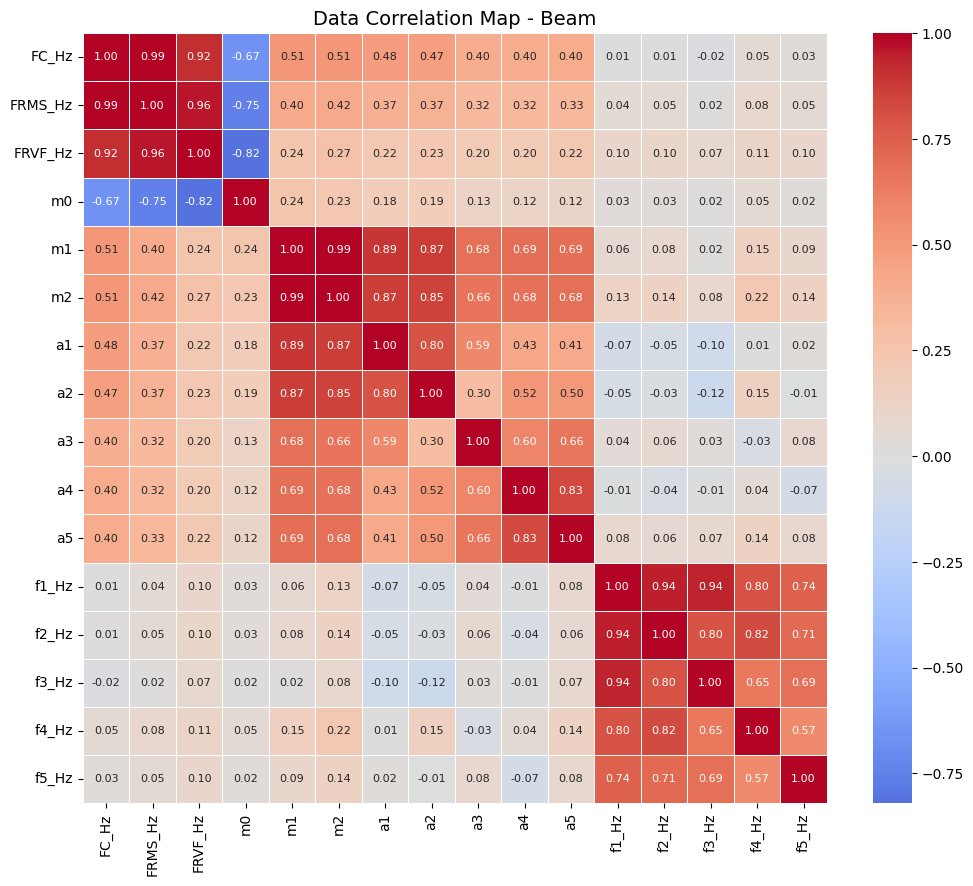

In [5]:
plt.figure(figsize=(12,10)) 
sns.heatmap(df_beam_cols.corr(method='spearman'), annot=True, fmt=".2f", cmap="coolwarm", center=0, 
            linewidths=0.5, annot_kws={"size": 8}) 
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.title("Data Correlation Map - Beam", fontsize=14)
plt.show()

----------------------------------------------
Distribution of attributes
----------------------------------------------
----------------------------------------------

Original distributions:


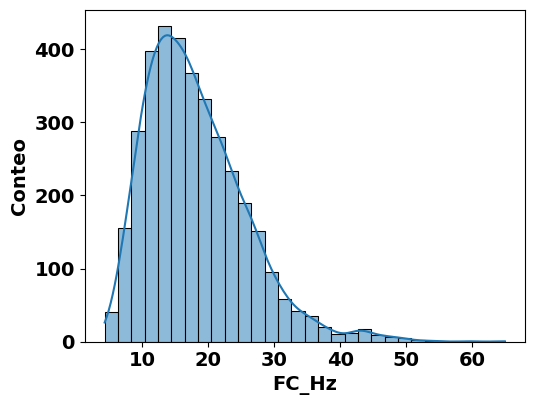

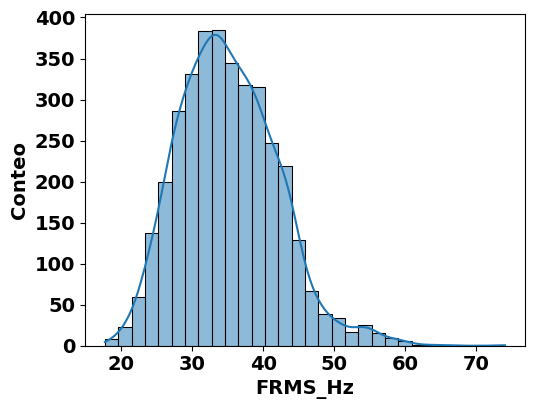

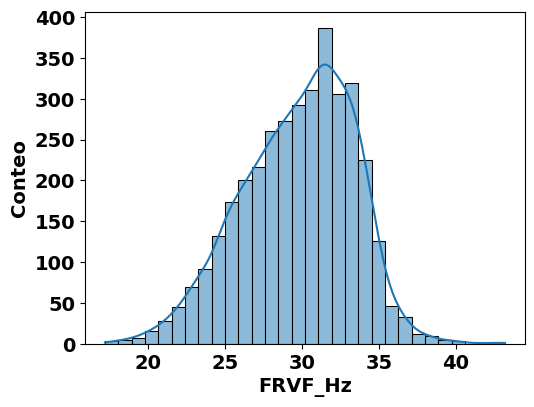

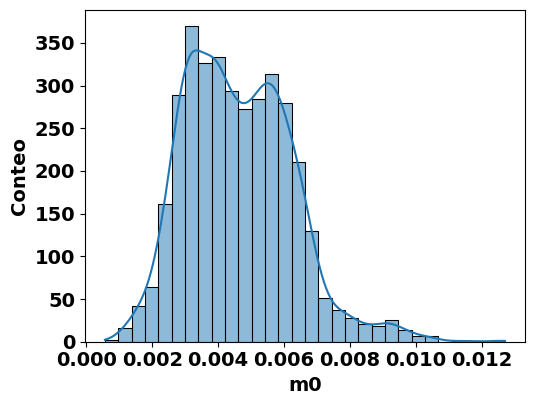

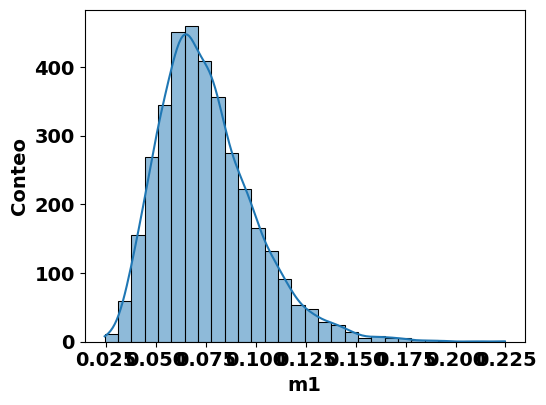

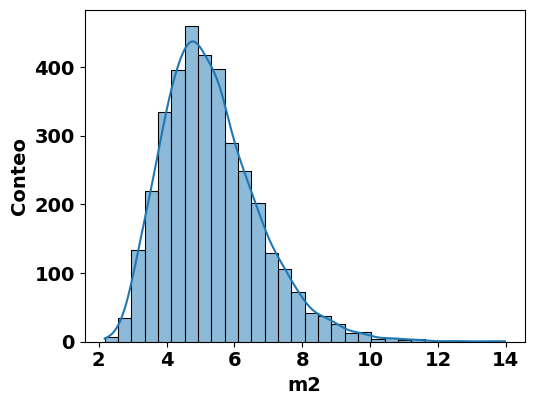

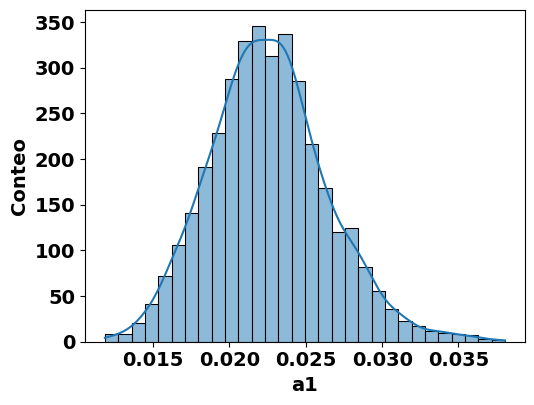

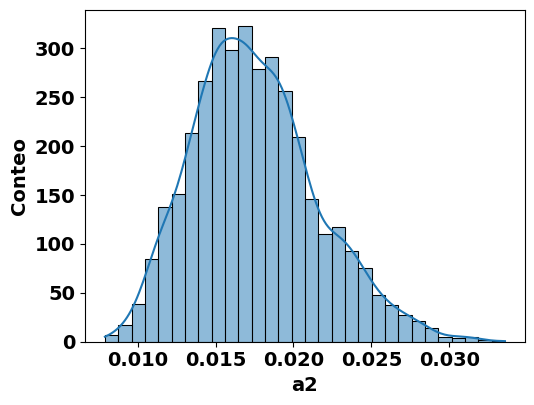

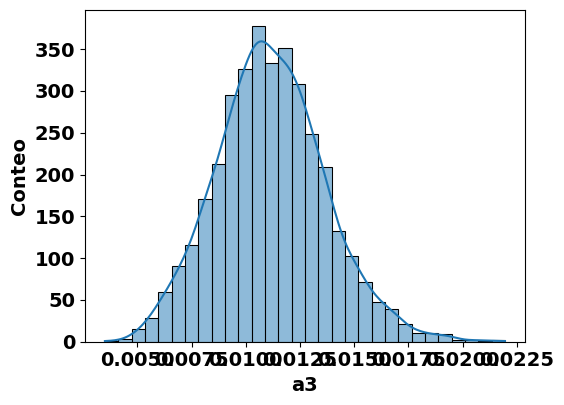

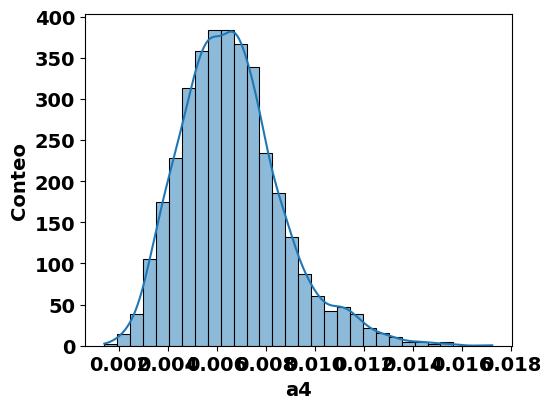

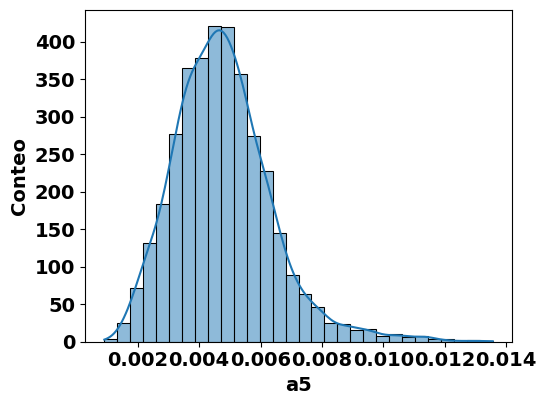

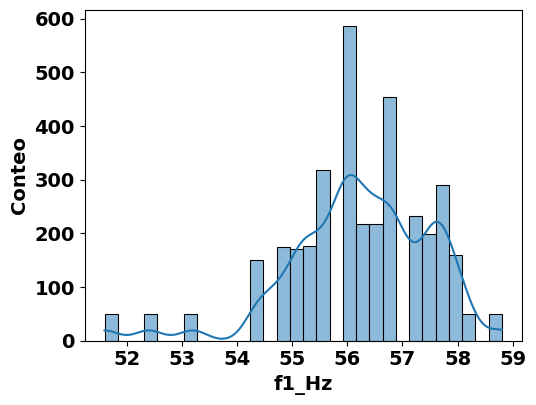

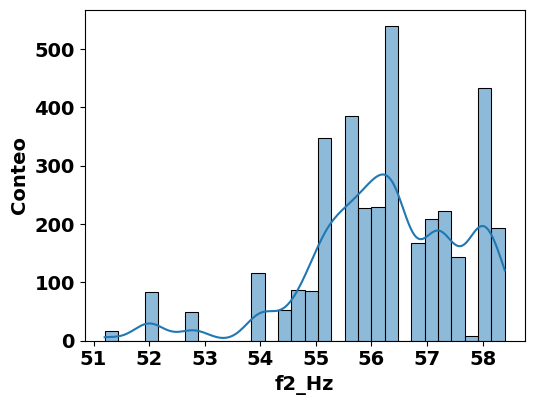

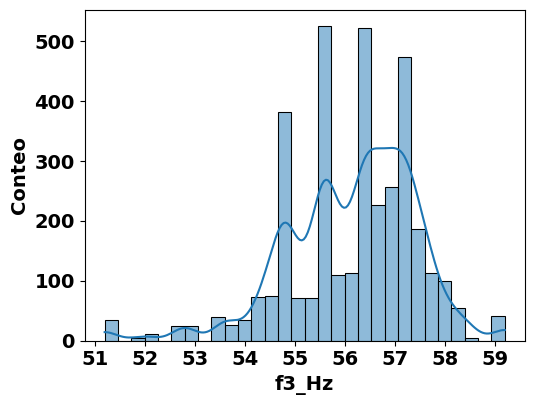

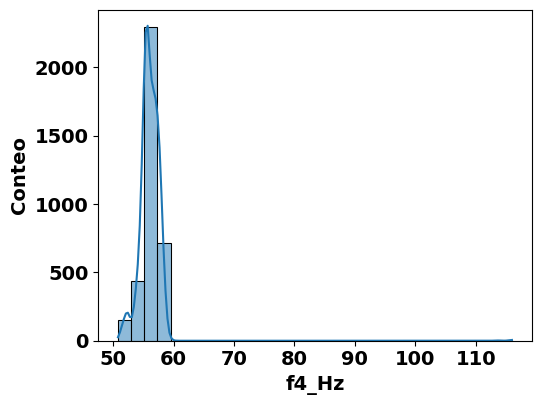

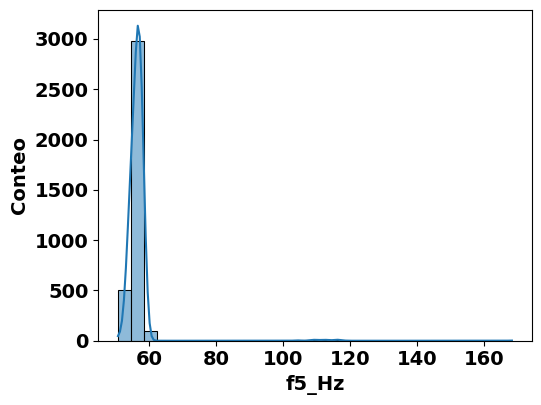

In [6]:
print("Original distributions:")

for i, col in enumerate(df_beam_cols):
    plt.figure(figsize=(10, len(df_beam_cols) * 4))
    plt.subplot(len(df_beam_cols), 2, 2 * i + 1)
    sns.histplot(df_beam_cols[col], kde=True, bins=30)

    plt.xlabel(col, fontsize=14, fontweight='bold')
    plt.ylabel("Conteo", fontsize=14, fontweight='bold')
    plt.xticks(fontsize=14, fontweight='bold')
    plt.yticks(fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

----------------------------------------------
Dataset splitting
----------------------------------------------
----------------------------------------------

In [7]:
import os, random, numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split

SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED); np.random.seed(SEED)

# Features
dfX = df_beam_cols.copy()
lbl = labels.copy()
assert (dfX.index == lbl.index).all(), "df_beam_cols and labels must be index-aligned."

# Targets + masks
y_cls  = lbl["target_class"].astype("int32").values
y_crack  = lbl["distance_crack_cm"].astype("float32").values
y_wear = lbl["distance_wear_cm"].astype("float32").values
sw_crack  = lbl["crack_mask"].astype("float32").values
sw_wear = lbl["wear_mask"].astype("float32").values

feature_names = list(dfX.columns)

X_all = dfX[feature_names].astype("float32").values
print(f"[X] Using {len(feature_names)} features.")

X_tr, X_te, \
y_cls_tr, y_cls_te, \
y_crack_tr, y_crack_te, \
y_wear_tr, y_wear_te, \
sw_crack_tr, sw_crack_te, \
sw_wear_tr, sw_wear_te = train_test_split(
    X_all, y_cls, y_crack, y_wear, sw_crack, sw_wear,
    test_size=0.20, random_state=SEED, stratify=y_cls
)

print(f"[Split] train={X_tr.shape[0]}  test={X_te.shape[0]}")

[X] Using 16 features.
[Split] train=2880  test=720


In [8]:
# ============================================================
# RAW TRAIN/TEST SNAPSHOT FOR PREPROCESSING SENSITIVITY
# ============================================================

X_tr_raw_split = X_tr.copy()
X_te_raw_split = X_te.copy()
feature_names_raw_split = list(feature_names)

# Targets and masks are also preserved to make the
# sensitivity analysis independent of later variable changes.
y_cls_tr_sensitivity = y_cls_tr.copy()
y_cls_te_sensitivity = y_cls_te.copy()

y_crack_tr_sensitivity = y_crack_tr.copy()
y_crack_te_sensitivity = y_crack_te.copy()

y_wear_tr_sensitivity = y_wear_tr.copy()
y_wear_te_sensitivity = y_wear_te.copy()

sw_crack_tr_sensitivity = sw_crack_tr.copy()
sw_crack_te_sensitivity = sw_crack_te.copy()

sw_wear_tr_sensitivity = sw_wear_tr.copy()
sw_wear_te_sensitivity = sw_wear_te.copy()

print(
    f"[Raw sensitivity snapshot] "
    f"train={X_tr_raw_split.shape}, "
    f"test={X_te_raw_split.shape}"
)
print(
    f"[Raw sensitivity snapshot] "
    f"n_features={len(feature_names_raw_split)}"
)
print(
    "[Raw sensitivity snapshot] Features:",
    feature_names_raw_split
)

[Raw sensitivity snapshot] train=(2880, 16), test=(720, 16)
[Raw sensitivity snapshot] n_features=16
[Raw sensitivity snapshot] Features: ['FC_Hz', 'FRMS_Hz', 'FRVF_Hz', 'm0', 'm1', 'm2', 'a1', 'a2', 'a3', 'a4', 'a5', 'f1_Hz', 'f2_Hz', 'f3_Hz', 'f4_Hz', 'f5_Hz']


In [9]:
# ============================================================
# Statistical diagnostic for selective winsorization
# TRAINING DATA ONLY
# ============================================================

import numpy as np
import pandas as pd

PEAK_FREQUENCY_FEATURES = [
    "f1_Hz",
    "f2_Hz",
    "f3_Hz",
    "f4_Hz",
    "f5_Hz",
]

IQR_MULTIPLIER = 1.5
WINSOR_QUANTILE = 0.99

rows = []

for feature in PEAK_FREQUENCY_FEATURES:

    idx = feature_names_raw_split.index(feature)

    values = np.asarray(
        X_tr_raw_split[:, idx],
        dtype=float,
    )

    q1 = np.quantile(values, 0.25)
    q3 = np.quantile(values, 0.75)
    iqr = q3 - q1

    lower_fence = q1 - IQR_MULTIPLIER * iqr
    upper_fence = q3 + IQR_MULTIPLIER * iqr

    lower_outliers = values < lower_fence
    upper_outliers = values > upper_fence

    q99 = np.quantile(values, WINSOR_QUANTILE)

    rows.append({
        "Feature": feature,
        "Q1": q1,
        "Q3": q3,
        "IQR": iqr,
        "Lower_Tukey_fence": lower_fence,
        "Upper_Tukey_fence": upper_fence,
        "Minimum": np.min(values),
        "Maximum": np.max(values),
        "Q99": q99,
        "Lower_outlier_count": int(lower_outliers.sum()),
        "Lower_outlier_percent": (
            100.0 * lower_outliers.mean()
        ),
        "Upper_outlier_count": int(upper_outliers.sum()),
        "Upper_outlier_percent": (
            100.0 * upper_outliers.mean()
        ),
    })

df_winsorization_diagnostic = pd.DataFrame(rows)

df_winsorization_diagnostic[
    "Selected_for_upper_winsorization"
] = (
    df_winsorization_diagnostic[
        "Upper_outlier_count"
    ] > 0
)

print(
    "=== Statistical diagnostic for peak-frequency features ==="
)

display(
    df_winsorization_diagnostic.round(4)
)

=== Statistical diagnostic for peak-frequency features ===


,Feature,Q1,Q3,IQR,Lower_Tukey_fence,Upper_Tukey_fence,Minimum,Maximum,Q99,Lower_outlier_count,Lower_outlier_percent,Upper_outlier_count,Upper_outlier_percent,Selected_for_upper_winsorization
0,f1_Hz,55.6,57.2,1.6,53.2,59.6,51.6,58.8,58.8,74,2.5694,0,0.0000,False
1,f2_Hz,55.6,57.2,1.6,53.2,59.6,51.2,58.4,58.4,115,3.9931,0,0.0000,False
2,f3_Hz,55.6,57.2,1.6,53.2,59.6,51.2,59.2,59.2,74,2.5694,0,0.0000,False
3,f4_Hz,55.2,56.8,1.6,52.8,59.2,50.8,116.0,58.4,114,3.9583,9,0.3125,True
4,f5_Hz,55.2,57.2,2.0,52.2,60.2,50.8,168.4,58.8,14,0.4861,23,0.7986,True


In [10]:
# ============================================================
# Statistical diagnostic for all original features
# TRAINING DATA ONLY
# ============================================================

import numpy as np
import pandas as pd
from scipy.stats import skew

FEATURE_FAMILIES = {
    "f1_Hz": "Peak frequency",
    "f2_Hz": "Peak frequency",
    "f3_Hz": "Peak frequency",
    "f4_Hz": "Peak frequency",
    "f5_Hz": "Peak frequency",

    "a1": "Peak amplitude",
    "a2": "Peak amplitude",
    "a3": "Peak amplitude",
    "a4": "Peak amplitude",
    "a5": "Peak amplitude",

    "m0": "Spectral moment",
    "m1": "Spectral moment",
    "m2": "Spectral moment",

    "FC_Hz": "Global frequency",
    "FRMS_Hz": "Global frequency",
    "FRVF_Hz": "Global frequency",
}

IQR_MULTIPLIER = 1.5
WINSOR_QUANTILE = 0.99

diagnostic_rows = []

for feature in feature_names_raw_split:

    idx = feature_names_raw_split.index(feature)

    values = np.asarray(
        X_tr_raw_split[:, idx],
        dtype=float,
    )

    q1 = np.quantile(values, 0.25)
    q3 = np.quantile(values, 0.75)
    iqr = q3 - q1

    lower_fence = q1 - IQR_MULTIPLIER * iqr
    upper_fence = q3 + IQR_MULTIPLIER * iqr

    lower_mask = values < lower_fence
    upper_mask = values > upper_fence

    q99 = np.quantile(values, WINSOR_QUANTILE)
    maximum = np.max(values)

    diagnostic_rows.append({
        "Feature": feature,
        "Family": FEATURE_FAMILIES.get(
            feature,
            "Other",
        ),
        "Q1": q1,
        "Q3": q3,
        "IQR": iqr,
        "Skewness": skew(
            values,
            bias=False,
            nan_policy="omit",
        ),
        "Lower_Tukey_fence": lower_fence,
        "Upper_Tukey_fence": upper_fence,
        "Minimum": np.min(values),
        "Maximum": maximum,
        "Q99": q99,
        "Maximum_to_Q99_ratio": (
            maximum / q99
            if q99 != 0
            else np.nan
        ),
        "Lower_outlier_count": int(
            lower_mask.sum()
        ),
        "Lower_outlier_percent": (
            100.0 * lower_mask.mean()
        ),
        "Upper_outlier_count": int(
            upper_mask.sum()
        ),
        "Upper_outlier_percent": (
            100.0 * upper_mask.mean()
        ),
    })

df_all_feature_diagnostic = pd.DataFrame(
    diagnostic_rows
)

# Selective winsorization requires both:
# 1. A peak-frequency descriptor.
# 2. At least one upper Tukey outlier.
df_all_feature_diagnostic[
    "Candidate_for_upper_winsorization"
] = (
    (
        df_all_feature_diagnostic["Family"]
        == "Peak frequency"
    )
    &
    (
        df_all_feature_diagnostic[
            "Upper_outlier_count"
        ] > 0
    )
)

display(
    df_all_feature_diagnostic
    .sort_values(
        [
            "Family",
            "Feature",
        ]
    )
    .round(4)
)

df_all_feature_diagnostic.to_csv(
    "all_feature_distribution_diagnostic.csv",
    index=False,
)

print(
    "[Exported] all_feature_distribution_diagnostic.csv"
)

,Feature,Family,Q1,Q3,IQR,Skewness,Lower_Tukey_fence,Upper_Tukey_fence,Minimum,Maximum,Q99,Maximum_to_Q99_ratio,Lower_outlier_count,Lower_outlier_percent,Upper_outlier_count,Upper_outlier_percent,Candidate_for_upper_winsorization
0,FC_Hz,Global frequency,12.5849,22.3694,9.7845,1.0566,-2.0918,37.0461,4.2827,64.9130,42.7687,1.5178,0,0.0000,63,2.1875,False
1,FRMS_Hz,Global frequency,30.1659,39.6078,9.4419,0.5098,16.0031,53.7706,17.7332,74.0250,54.6231,1.3552,0,0.0000,36,1.2500,False
2,FRVF_Hz,Global frequency,27.3363,32.5397,5.2034,-0.3743,19.5311,40.3448,17.2082,43.1819,36.8311,1.1724,8,0.2778,1,0.0347,False
6,a1,Peak amplitude,0.0200,0.0249,0.0049,0.3905,0.0126,0.0323,0.0119,0.0380,0.0336,1.1318,3,0.1042,44,1.5278,False
7,a2,Peak amplitude,0.0147,0.0199,0.0052,0.5195,0.0069,0.0277,0.0079,0.0336,0.0281,1.1947,0,0.0000,39,1.3542,False
8,a3,Peak amplitude,0.0094,0.0127,0.0033,0.3038,0.0045,0.0177,0.0035,0.0220,0.0176,1.2451,2,0.0694,28,0.9722,False
9,a4,Peak amplitude,0.0051,0.0077,0.0026,0.7932,0.0013,0.0116,0.0015,0.0172,0.0127,1.3588,0,0.0000,72,2.5000,False
10,a5,Peak amplitude,0.0037,0.0056,0.0019,0.9662,0.0008,0.0086,0.0009,0.0136,0.0101,1.3434,0,0.0000,76,2.6389,False
11,f1_Hz,Peak frequency,55.6000,57.2000,1.6000,-0.8829,53.2000,59.6000,51.6000,58.8000,58.8000,1.0000,74,2.5694,0,0.0000,False
12,f2_Hz,Peak frequency,55.6000,57.2000,1.6000,-0.7956,53.2000,59.6000,51.2000,58.4000,58.4000,1.0000,115,3.9931,0,0.0000,False


[Exported] all_feature_distribution_diagnostic.csv


----------------------------------------------
Attribute transformations
----------------------------------------------
----------------------------------------------

In [11]:
import numpy as np
from sklearn.preprocessing import PowerTransformer

cols_yeojohnson = ["FC_Hz","FRVF_Hz","FRMS_Hz","m0","m1","m2","a1","a2","a3","a4","a5"]

cols_present = [c for c in cols_yeojohnson if c in feature_names]
idx_yj = [feature_names.index(c) for c in cols_present]

print(f"[YJ] Requested={len(cols_yeojohnson)}  Present_in_features={len(cols_present)}")
if len(cols_present) > 0:
    print("[YJ] Applying to:", cols_present)

    X_tr = X_tr.copy()
    X_te = X_te.copy()

    X_tr_raw = X_tr.copy()

    Xtr_yj = X_tr[:, idx_yj].astype(np.float64, copy=True)
    Xte_yj = X_te[:, idx_yj].astype(np.float64, copy=True)

    if not np.isfinite(Xtr_yj).all():
        bad = np.where(~np.isfinite(Xtr_yj))
        raise ValueError(f"[YJ] Non-finite values in TRAIN at rows={bad[0][:10]} cols={bad[1][:10]}")
    if not np.isfinite(Xte_yj).all():
        bad = np.where(~np.isfinite(Xte_yj))
        raise ValueError(f"[YJ] Non-finite values in TEST at rows={bad[0][:10]} cols={bad[1][:10]}")

    pt_yj = PowerTransformer(method="yeo-johnson", standardize=False)

    Xtr_yj = pt_yj.fit_transform(Xtr_yj) 
    Xte_yj = pt_yj.transform(Xte_yj)     

    X_tr[:, idx_yj] = Xtr_yj
    X_te[:, idx_yj] = Xte_yj

else:
    print("[YJ] None of the requested columns exist in feature_names. Skipping YJ.")
    pt_yj = None

[YJ] Requested=11  Present_in_features=11
[YJ] Applying to: ['FC_Hz', 'FRVF_Hz', 'FRMS_Hz', 'm0', 'm1', 'm2', 'a1', 'a2', 'a3', 'a4', 'a5']


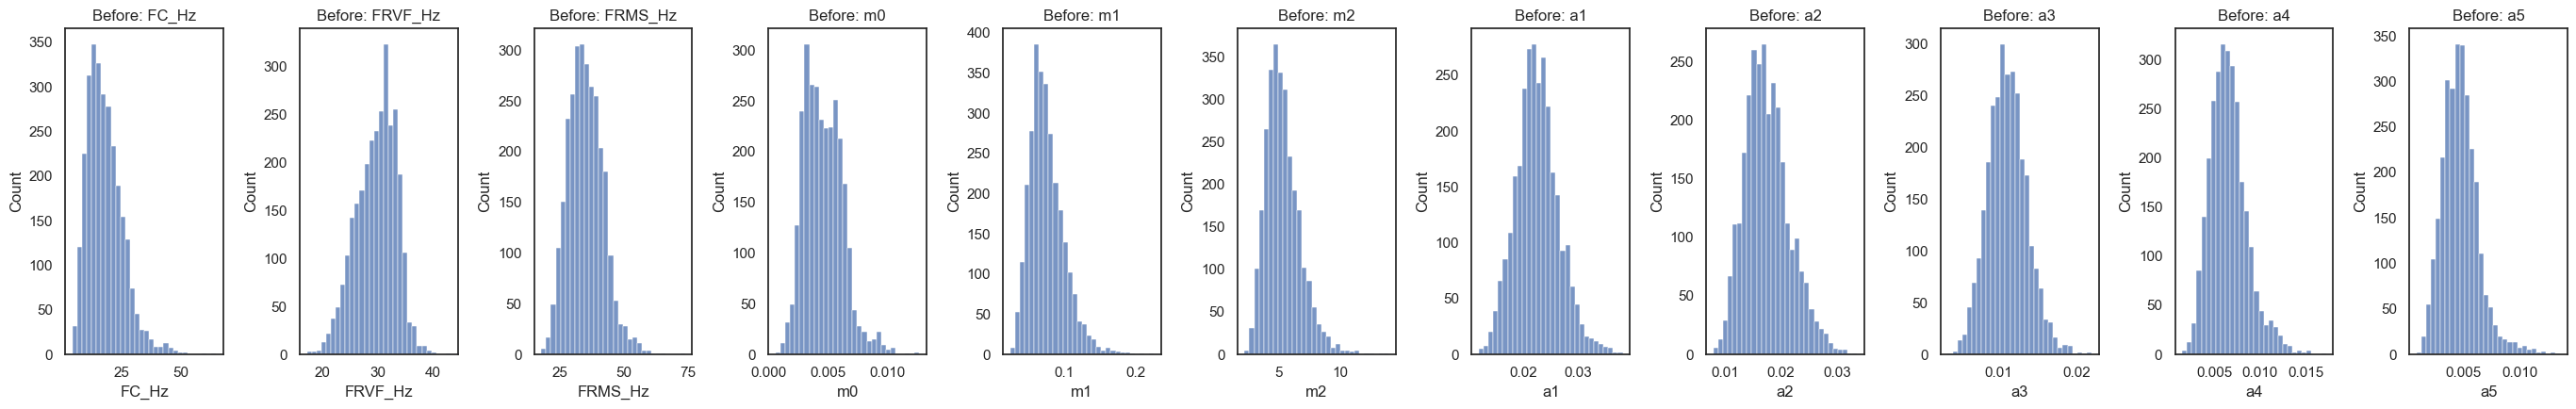

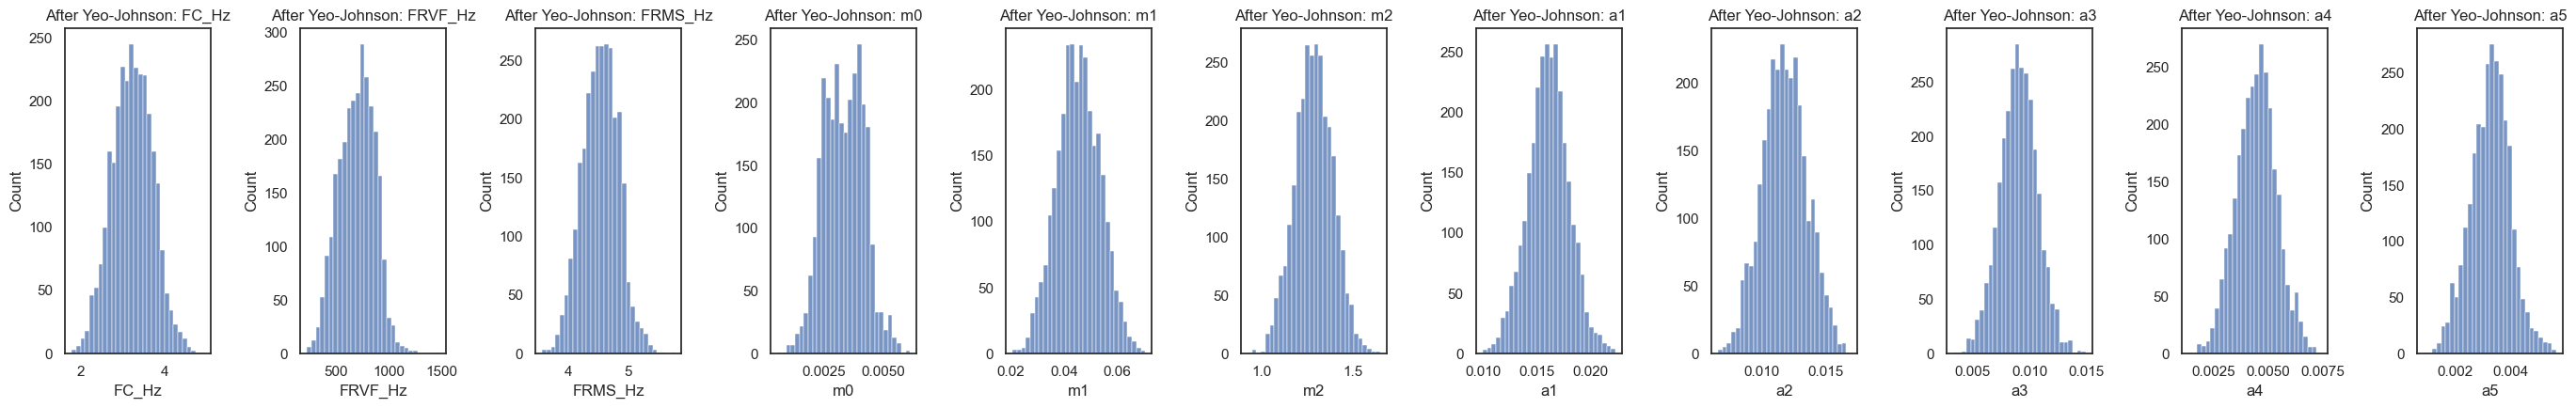

    feature  skew_before  skew_after  abs_reduction
0     FC_Hz     1.056551   -0.001993       1.054558
1        m1     1.054285    0.027622       1.026663
2        m2     0.998801    0.001790       0.997011
3        a5     0.966223   -0.014352       0.951871
4        a4     0.793192    0.006438       0.786754
5        m0     0.642915    0.023544       0.619371
6   FRMS_Hz     0.509830   -0.000368       0.509461
7        a2     0.519547    0.017554       0.501994
8        a1     0.390483   -0.004353       0.386130
9   FRVF_Hz    -0.374309   -0.031823       0.342485
10       a3     0.303779   -0.002868       0.300912


In [12]:
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import skew

sns.set_theme(style="white")

# Histograms (train: before vs after) ----
n = len(cols_present)
fig_w = max(14, 2.5 * n)
fig_h = 4.5

# A) Before
fig, axes = plt.subplots(1, n, figsize=(fig_w, fig_h))

if n == 1:
    axes = [axes]

for ax, (c, j) in zip(axes, zip(cols_present, idx_yj)):
    sns.histplot(X_tr_raw[:, j], bins=30, ax=ax, kde=False)
    ax.set_title(f"Before: {c}")
    ax.set_xlabel(c)
    ax.set_ylabel("Count")

plt.tight_layout()
plt.show()


# B) After
fig, axes = plt.subplots(1, n, figsize=(fig_w, fig_h))

if n == 1:
    axes = [axes]

for ax, (c, j) in zip(axes, zip(cols_present, idx_yj)):
    sns.histplot(X_tr[:, j], bins=30, ax=ax, kde=False)
    ax.set_title(f"After Yeo-Johnson: {c}")
    ax.set_xlabel(c)
    ax.set_ylabel("Count")

plt.tight_layout()
plt.show()


# ---- 4) Comparative table of skewness (train) ----
rows = []
for c, j in zip(cols_present, idx_yj):
    sk_before = float(skew(X_tr_raw[:, j], bias=False, nan_policy="omit"))
    sk_after  = float(skew(X_tr[:, j], bias=False, nan_policy="omit"))
    rows.append({
        "feature": c,
        "skew_before": sk_before,
        "skew_after": sk_after,
        "abs_reduction": abs(sk_before) - abs(sk_after),
    })

df_skew = pd.DataFrame(rows).sort_values("abs_reduction", ascending=False).reset_index(drop=True)

with pd.option_context("display.max_rows", 200, "display.max_columns", 20, "display.width", 160):
    print(df_skew)

[Winsor] Requested=2  Present_in_features=2

=== Winsorize superior (alpha=0.010 -> quantil 0.990) FIT in train ===
Variable Cap_train(q)  Replaced_train %_train
   f4_Hz    58.400002              12   0.42%
   f5_Hz    58.799999              25   0.87%


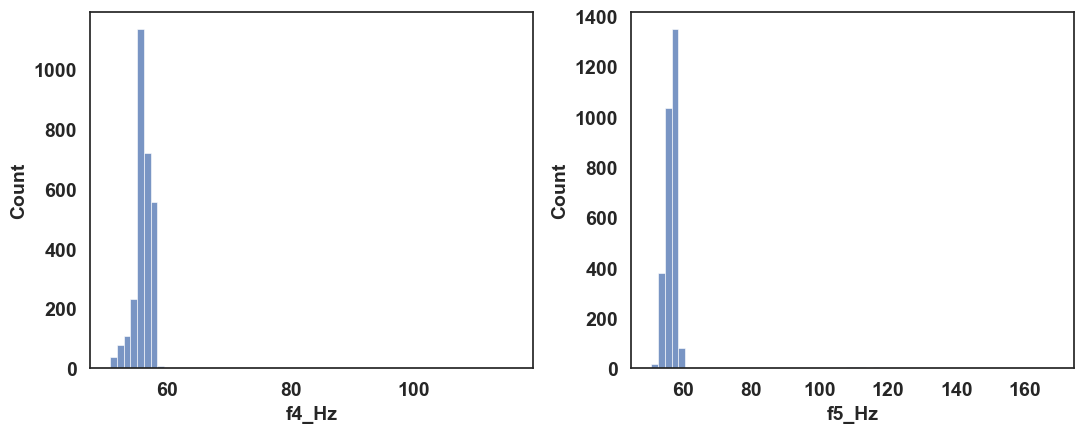

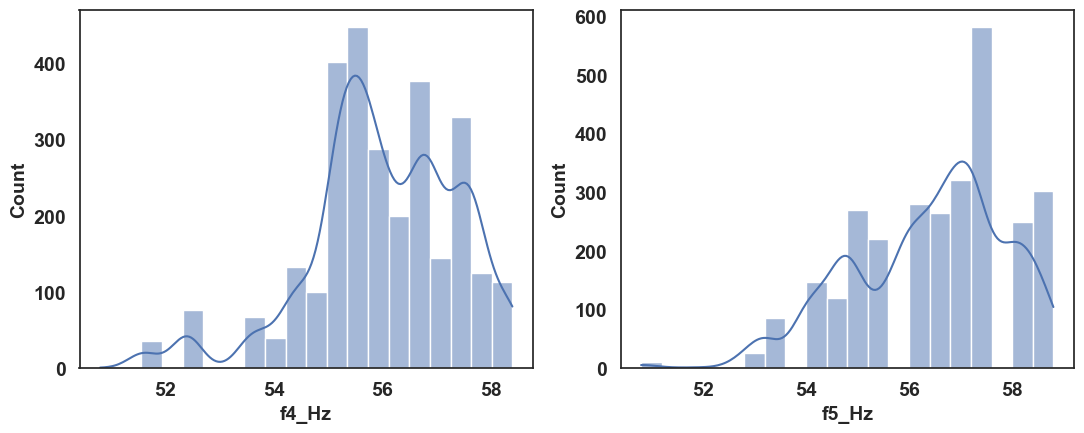

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="white")

UPPER_ALPHA = 0.01
cols_win = ["f4_Hz", "f5_Hz"]

cols_present = [c for c in cols_win if c in feature_names]
idx_win = [feature_names.index(c) for c in cols_present]

print(f"[Winsor] Requested={len(cols_win)}  Present_in_features={len(cols_present)}")
if len(cols_present) == 0:
    print("[Winsor] None of the requested columns exist in feature_names. Skipping.")
else:
    X_tr = X_tr.copy()
    X_te = X_te.copy()

    X_tr_win_raw = X_tr[:, idx_win].copy()

    # 1) Thresholds (cap) calculated ONLY in train
    caps = np.quantile(X_tr[:, idx_win], 1.0 - UPPER_ALPHA, axis=0)

    # 2) Apply top winsorize as clipping: x = min(x, cap_train)
    X_tr[:, idx_win] = np.minimum(X_tr[:, idx_win], caps)
    X_te[:, idx_win] = np.minimum(X_te[:, idx_win], caps)

    # 3) Comparative table of replacements (train and test)
    stats = []
    for k, c in enumerate(cols_present):
        cap = float(caps[k])

        tr_before = X_tr_win_raw[:, k]
        tr_after  = X_tr[:, idx_win[k]]

        n_tr = tr_before.size
        n_tr_repl = int(np.sum(tr_before > cap))
        pct_tr = 100.0 * n_tr_repl / n_tr if n_tr else 0.0

        stats.append([c, cap, n_tr_repl, pct_tr])

    df_wins = pd.DataFrame(
        stats,
        columns=["Variable", "Cap_train(q)", "Replaced_train", "%_train"]
    )

    print(f"\n=== Winsorize superior (alpha={UPPER_ALPHA:.3f} -> quantil {1-UPPER_ALPHA:.3f}) FIT in train ===")
    print(df_wins.to_string(index=False, formatters={
        "Cap_train(q)": "{:.6f}".format,
        "%_train": "{:.2f}%".format
    }))

    # 4) Histograms (TRAIN before vs after)
    n = len(cols_present)
    fig_w = max(11, 2.6 * n)
    fig_h = 4.5

    # Before
    fig, axes = plt.subplots(1, n, figsize=(fig_w, fig_h))
    if n == 1:
        axes = [axes]

    for ax, (i, c) in zip(axes, enumerate(cols_present)):
        sns.histplot(X_tr_win_raw[:, i], bins=60, ax=ax, kde=False)
        #ax.set_title(f"Train before: {c}")
        ax.set_xlabel(c)
        ax.set_ylabel("Count") 

        ax.set_xlabel(c, fontsize=14, fontweight='bold')
        ax.set_ylabel("Count", fontsize=14, fontweight='bold')

        ax.tick_params(axis='both', labelsize=14)

        # Forzar negrita en ticks
        for label in ax.get_xticklabels():
            label.set_fontweight('bold')
        for label in ax.get_yticklabels():
            label.set_fontweight('bold')

    plt.tight_layout()
    plt.show()

    # After
    fig, axes = plt.subplots(1, n, figsize=(fig_w, fig_h))
    if n == 1:
        axes = [axes]

    for ax, (i, c) in zip(axes, enumerate(cols_present)):
        sns.histplot(X_tr[:, idx_win[i]], bins=20, ax=ax, kde=True)
        #ax.set_title(f"Train after winsorize↑: {c}")
        ax.set_xlabel(c)
        ax.set_ylabel("Count")

        ax.set_xlabel(c, fontsize=14, fontweight='bold')
        ax.set_ylabel("Count", fontsize=14, fontweight='bold')

        ax.tick_params(axis='both', labelsize=14)

        # Forzar negrita en ticks
        for label in ax.get_xticklabels():
            label.set_fontweight('bold')
        for label in ax.get_yticklabels():
            label.set_fontweight('bold')
    
    plt.tight_layout()
    plt.show()

In [14]:
import numpy as np
import pandas as pd

_req = ["X_tr_raw", "X_tr", "feature_names", "y_cls_tr"]
assert all(v in globals() for v in _req), \
    "Missing variables. Need X_tr_raw (before), X_tr (after), feature_names, y_cls_tr."

df_before = pd.DataFrame(X_tr_raw, columns=feature_names).copy()
df_after  = pd.DataFrame(X_tr,     columns=feature_names).copy()

HUE_COL = "target_class"
df_before[HUE_COL] = y_cls_tr.astype(int)
df_after[HUE_COL]  = y_cls_tr.astype(int)

print("[Pairplot] df_before shape:", df_before.shape)
print("[Pairplot] df_after  shape:", df_after.shape)

[Pairplot] df_before shape: (2880, 17)
[Pairplot] df_after  shape: (2880, 17)


In [15]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set(style="white")

def make_pairplot_inline(df, cols, hue, title, sample=500):
    cols_present = [c for c in cols if c in df.columns]
    if len(cols_present) == 0:
        print(f"[Pairplot] Skipping '{title}' (no columns present).")
        return

    d = df[[hue] + cols_present].replace([np.inf, -np.inf], np.nan).dropna().copy()

    if len(d) == 0:
        print(f"[Pairplot] Skipping '{title}' (no rows after dropna).")
        return

    if len(d) > sample:
        d = d.sample(sample, random_state=42)

    d[hue] = d[hue].astype("category")

    g = sns.pairplot(
        d, vars=cols_present, hue=hue,
        diag_kind="kde",
        kind="scatter",
        height=1.5,
        aspect=1.0,
        plot_kws=dict(s=12, alpha=0.6, edgecolor="none")
    )

    g.fig.suptitle(title, y=1.05, fontsize=12)

    for ax in g.axes.flatten():
        if ax is not None:
            ax.tick_params(labelsize=7)

    if g._legend is not None:
        leg = g._legend

        if hasattr(leg, "legend_handles"):
            handles = leg.legend_handles
        elif hasattr(leg, "legendHandles"):
            handles = leg.legendHandles
        else:
            handles, _ = leg.axes.get_legend_handles_labels()

        labels = [t.get_text() for t in leg.get_texts()]
        n_classes = max(1, len(labels))

        leg.remove()

        g.fig.legend(
            handles, labels,
            title="Class",
            loc="upper center",
            bbox_to_anchor=(0.5, 1.02),
            ncol=n_classes,
            fontsize=10,
            title_fontsize=8,
            frameon=False
        )

    g.fig.subplots_adjust(
        top=0.97,
        bottom=0.05,
        left=0.05,
        right=0.98,
        wspace=0.02,
        hspace=0.02
    )

    plt.show()

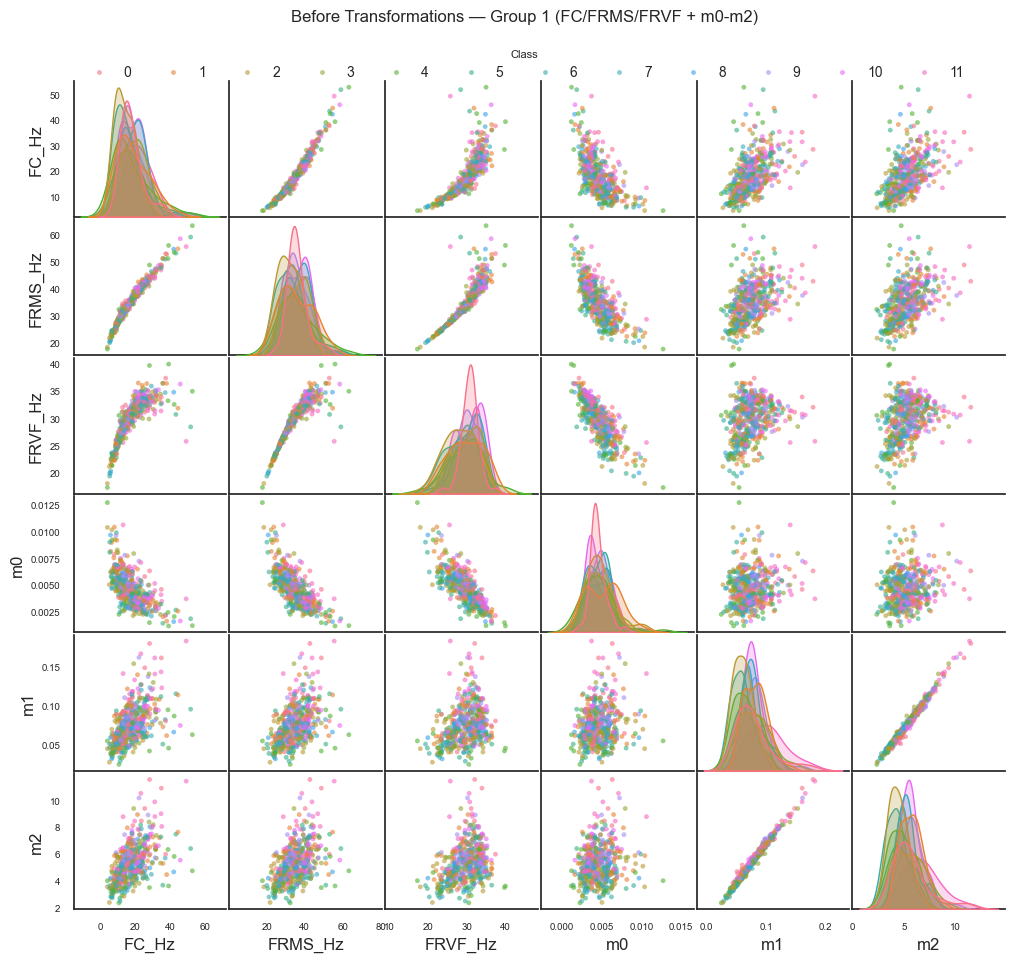

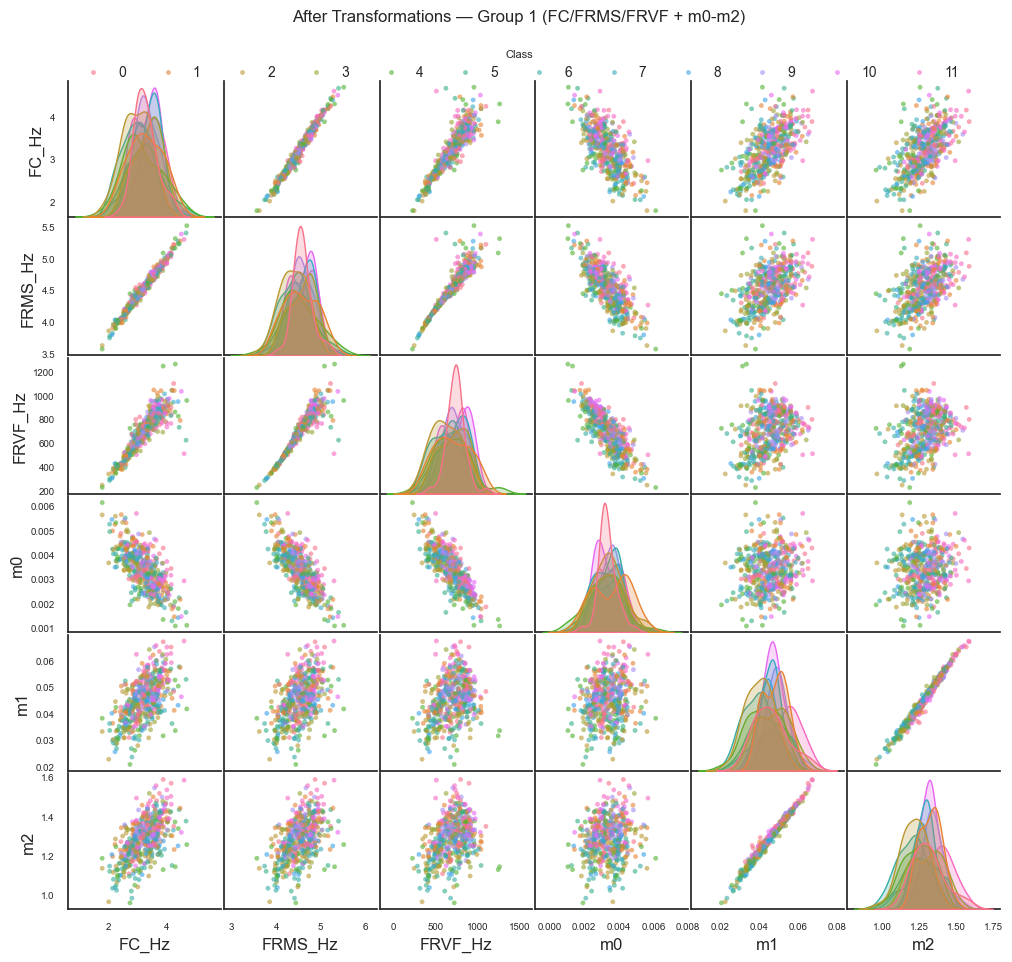

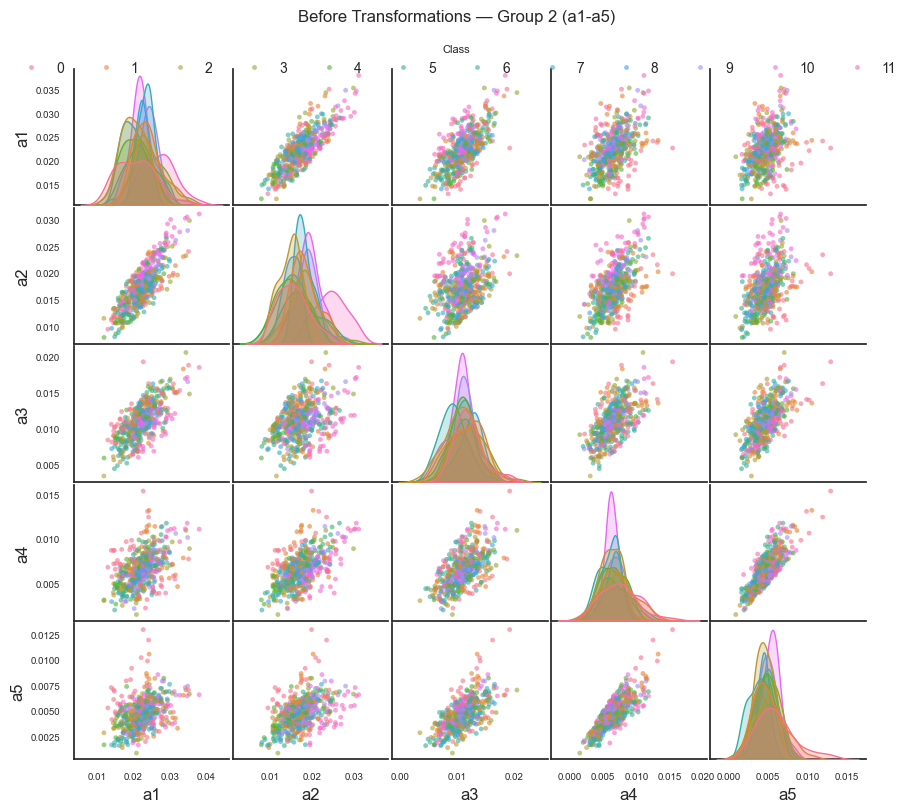

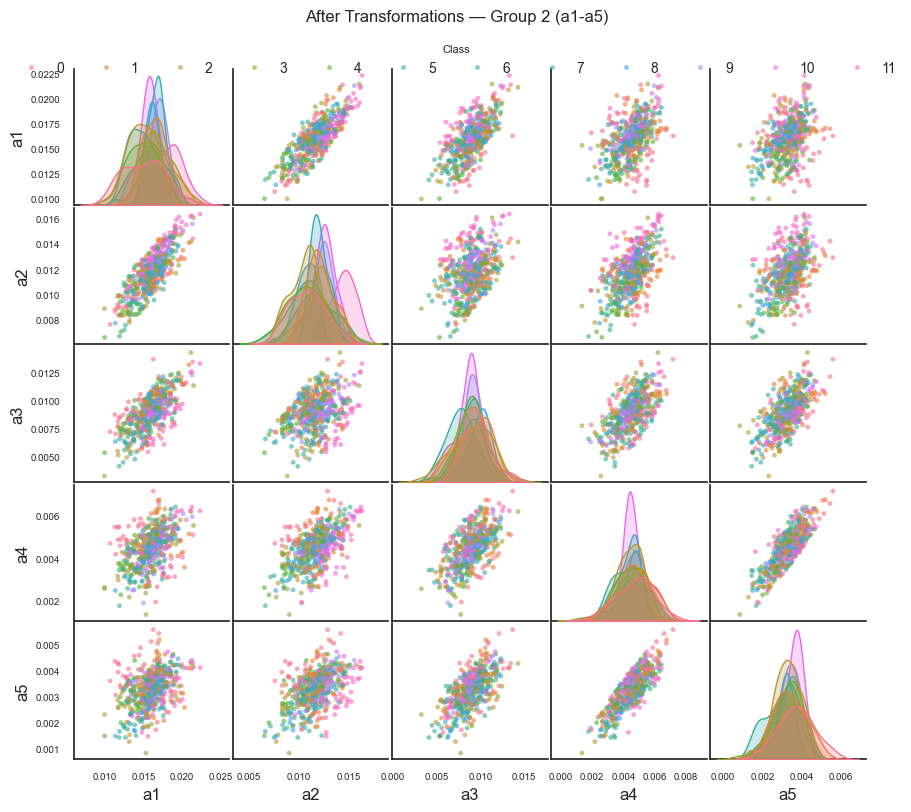

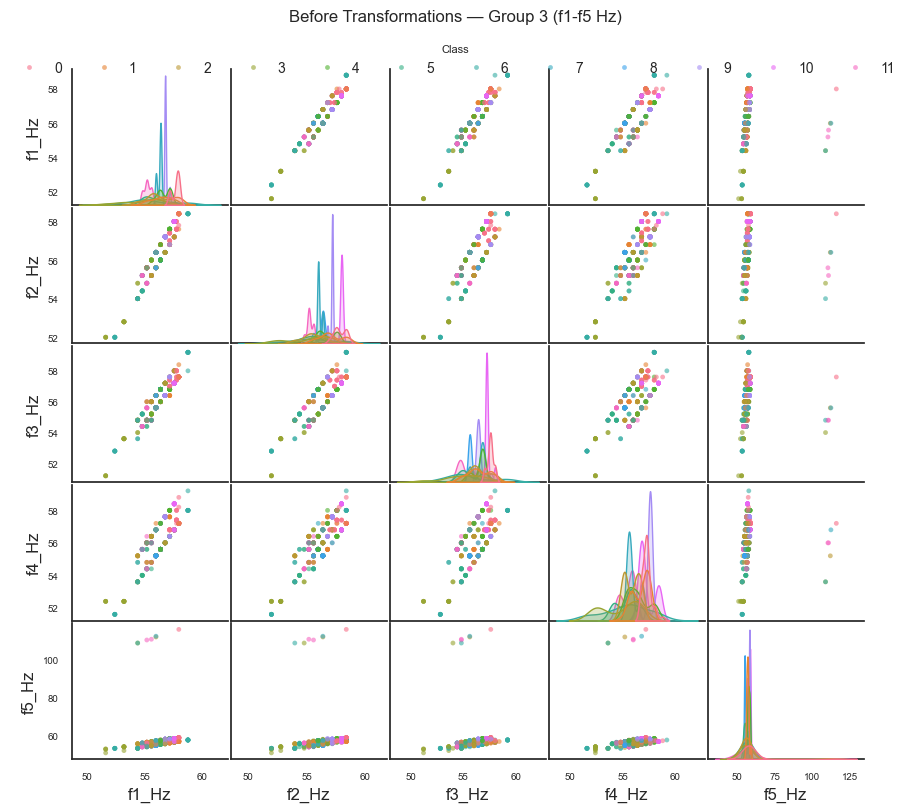

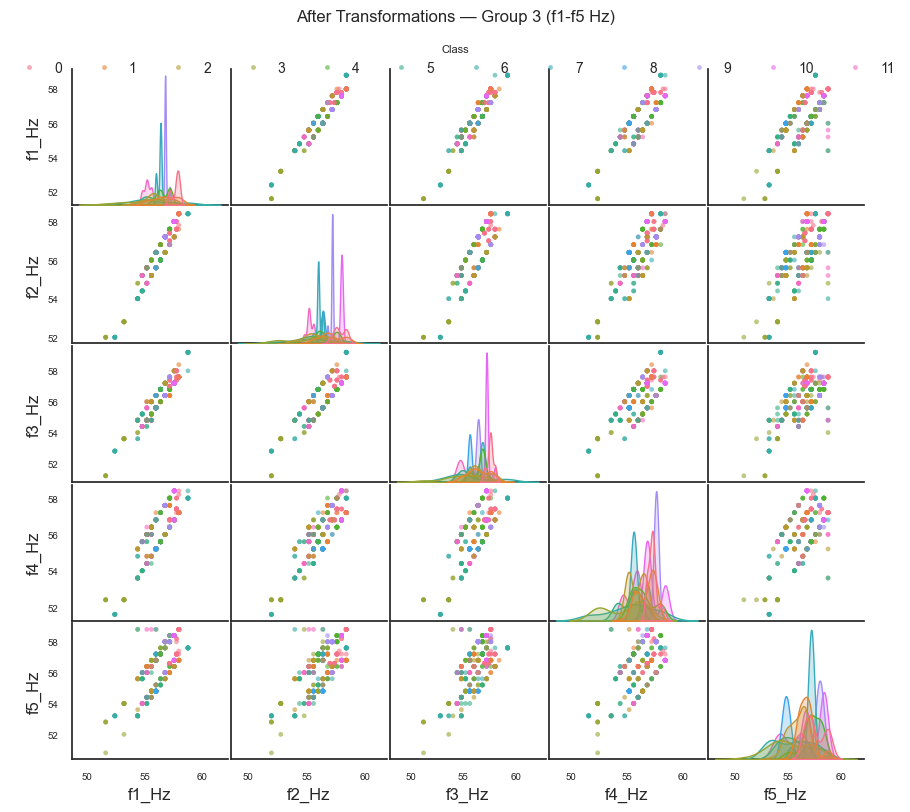

In [16]:
features  = ["FC_Hz","FRMS_Hz","FRVF_Hz","m0","m1","m2"]
features2 = ["a1","a2","a3","a4","a5"]
features3 = ["f1_Hz","f2_Hz","f3_Hz","f4_Hz","f5_Hz"]

groups = {
    "Group 1 (FC/FRMS/FRVF + m0-m2)": features,
    "Group 2 (a1-a5)": features2,
    "Group 3 (f1-f5 Hz)": features3,
}

for name, cols in groups.items():
    make_pairplot_inline(df_before, cols, HUE_COL, f"Before Transformations — {name}", sample=500)
    make_pairplot_inline(df_after,  cols, HUE_COL, f"After Transformations — {name}",  sample=500)

In [17]:
# ===================== PRE-SELECTION SNAPSHOT FOR ABLATION =====================
_required_preselect = [
    "X_tr", "X_te", "feature_names",
    "y_cls_tr", "y_cls_te",
    "y_crack_tr", "y_crack_te",
    "y_wear_tr", "y_wear_te",
    "sw_crack_tr", "sw_crack_te",
    "sw_wear_tr", "sw_wear_te",
]
assert all(v in globals() for v in _required_preselect), (
    "Missing variables. Run split + transformations before creating the pre-selection snapshot."
)

X_tr_preselect = X_tr.copy()
X_te_preselect = X_te.copy()
feature_names_preselect = list(feature_names)

y_cls_tr_preselect = y_cls_tr.copy()
y_cls_te_preselect = y_cls_te.copy()
y_crack_tr_preselect = y_crack_tr.copy()
y_crack_te_preselect = y_crack_te.copy()
y_wear_tr_preselect = y_wear_tr.copy()
y_wear_te_preselect = y_wear_te.copy()
sw_crack_tr_preselect = sw_crack_tr.copy()
sw_crack_te_preselect = sw_crack_te.copy()
sw_wear_tr_preselect = sw_wear_tr.copy()
sw_wear_te_preselect = sw_wear_te.copy()

print(f"[Ablation Snapshot] train={X_tr_preselect.shape}  test={X_te_preselect.shape}")
print(f"[Ablation Snapshot] n_features_preselect={len(feature_names_preselect)}")
print("[Ablation Snapshot] features:", feature_names_preselect)


[Ablation Snapshot] train=(2880, 16)  test=(720, 16)
[Ablation Snapshot] n_features_preselect=16
[Ablation Snapshot] features: ['FC_Hz', 'FRMS_Hz', 'FRVF_Hz', 'm0', 'm1', 'm2', 'a1', 'a2', 'a3', 'a4', 'a5', 'f1_Hz', 'f2_Hz', 'f3_Hz', 'f4_Hz', 'f5_Hz']


----------------------------------------------
Selection of the Most Relevant Attributes
----------------------------------------------
----------------------------------------------

[Original matrices] train=(2880, 16), test=(720, 16)
[Original features] ['FC_Hz', 'FRMS_Hz', 'FRVF_Hz', 'm0', 'm1', 'm2', 'a1', 'a2', 'a3', 'a4', 'a5', 'f1_Hz', 'f2_Hz', 'f3_Hz', 'f4_Hz', 'f5_Hz']


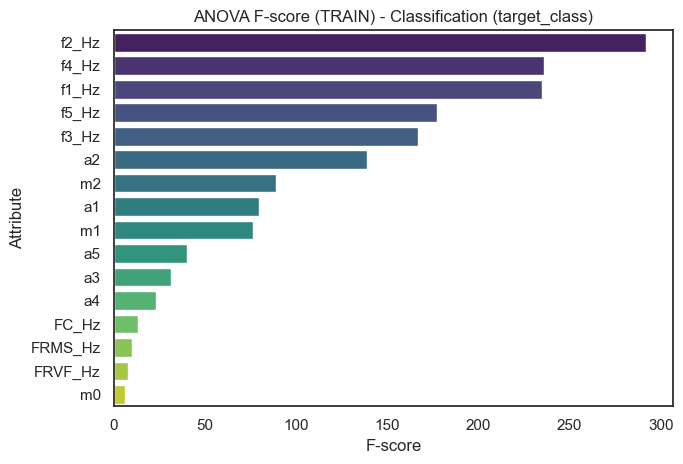

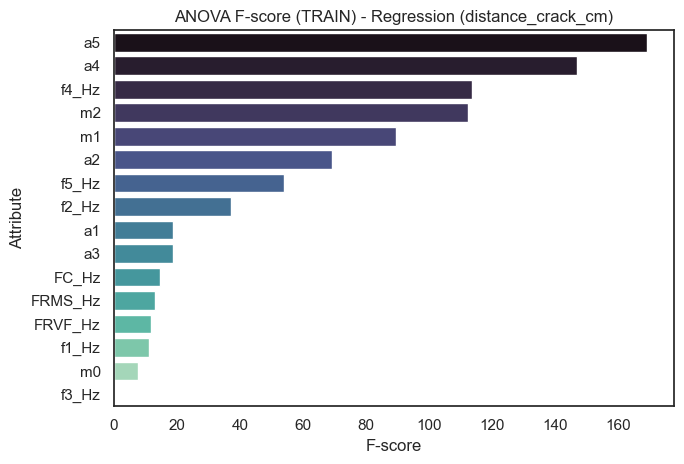

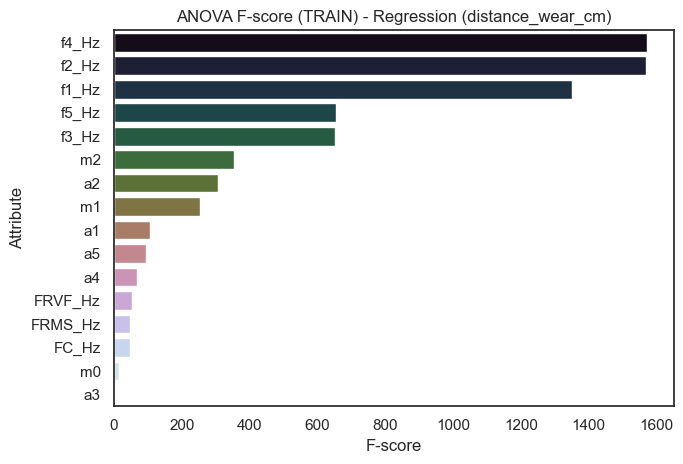


[Selection] Classification (9): ['f2_Hz', 'f4_Hz', 'f1_Hz', 'f5_Hz', 'f3_Hz', 'a2', 'm2', 'a1', 'm1']
[Selection] Crack regression (9): ['a5', 'a4', 'f4_Hz', 'm2', 'm1', 'a2', 'f5_Hz', 'f2_Hz', 'a1']
[Selection] Wear regression (8): ['f4_Hz', 'f2_Hz', 'f1_Hz', 'f5_Hz', 'f3_Hz', 'm2', 'a2', 'm1']

[Preliminary union] 11 features
[Preliminary union] ['f2_Hz', 'f4_Hz', 'f1_Hz', 'f5_Hz', 'f3_Hz', 'a2', 'm2', 'a1', 'm1', 'a5', 'a4']

[Normalized relevance of preliminary features]
Feature  Classification_normalized_F  Crack_normalized_F  Wear_normalized_F  Mean_normalized_F
  f4_Hz                     0.808620            0.671548           1.000000           0.826723
  f2_Hz                     1.000000            0.220196           0.997433           0.739210
  f1_Hz                     0.805106            0.065699           0.859090           0.576632
  f5_Hz                     0.606535            0.318348           0.415804           0.446896
     a5                     0.136695        

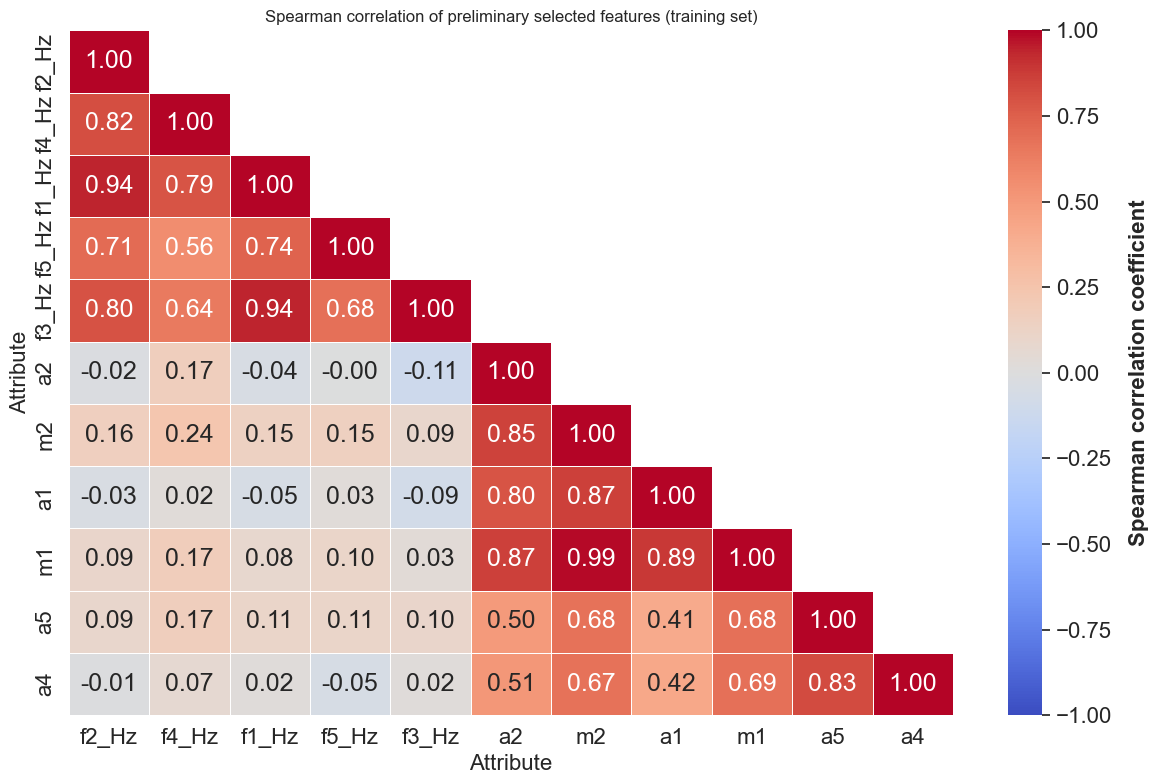


[Highly correlated pairs: |rho| >= 0.95]
Feature_1 Feature_2  Spearman_rho  Abs_rho  Mean_relevance_1  Mean_relevance_2
       m2        m1       0.99088  0.99088           0.39835          0.316632

[Correlation-based decisions]
Retained Removed  Spearman_rho  Retained_mean_normalized_F  Removed_mean_normalized_F
      m2      m1       0.99088                     0.39835                   0.316632

[m1 versus m2]
Spearman rho: 0.9909
Mean normalized relevance m1: 0.3166
Mean normalized relevance m2: 0.3984
Decision: m1 is removed because it is strongly correlated with m2 and has lower mean task-normalized relevance.

[Final selection] 10 features
[Final features] ['f2_Hz', 'f4_Hz', 'f1_Hz', 'f5_Hz', 'f3_Hz', 'a2', 'm2', 'a1', 'a5', 'a4']
[Selected matrices] train=(2880, 10), test=(720, 10)


In [18]:
# ============================================================
# Task-specific ANOVA relevance analysis
# + correlation-based redundancy refinement
# Uses TRAINING data only
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_selection import f_classif, f_regression


# ------------------------------------------------------------
# 1. Selection parameters
# ------------------------------------------------------------

TOP_K_CLS = 9
TOP_K_CRACK = 9
TOP_K_WEAR = 8

USE_P_THRESHOLD = False
P_THRESHOLD = 0.05

# Strong-redundancy threshold
CORR_THRESHOLD = 0.95

PLOT_RELEVANCE = True
PLOT_CORRELATION = True


# ------------------------------------------------------------
# 2. Preserve the original 16-feature matrices
#
# IMPORTANT:
# Run this cell before X_tr, X_te, and feature_names are reduced.
# ------------------------------------------------------------

X_tr_full = np.asarray(X_tr).copy()
X_te_full = np.asarray(X_te).copy()
feature_names_full = list(feature_names)

if X_tr_full.shape[1] != len(feature_names_full):
    raise ValueError(
        "X_tr columns do not match the number of feature names."
    )

if X_te_full.shape[1] != len(feature_names_full):
    raise ValueError(
        "X_te columns do not match the number of feature names."
    )

print(
    f"[Original matrices] train={X_tr_full.shape}, "
    f"test={X_te_full.shape}"
)
print("[Original features]", feature_names_full)


# ------------------------------------------------------------
# 3. Utility functions
# ------------------------------------------------------------

def anova_table(X, y, cols, mode="cls"):
    """
    Calculate univariate F-scores and p-values.

    mode='cls':
        ANOVA F-score for multiclass classification.

    mode='reg':
        F-score for univariate linear regression.
    """

    X = np.asarray(X)
    y = np.asarray(y).reshape(-1)

    if mode == "cls":
        F, p = f_classif(X, y)

    elif mode == "reg":
        F, p = f_regression(X, y)

    else:
        raise ValueError("mode must be 'cls' or 'reg'.")

    F = np.nan_to_num(
        np.asarray(F, dtype=float),
        nan=0.0,
        posinf=0.0,
        neginf=0.0,
    )

    p = np.nan_to_num(
        np.asarray(p, dtype=float),
        nan=1.0,
        posinf=1.0,
        neginf=1.0,
    )

    result = pd.DataFrame({
        "Attribute": cols,
        "F": F,
        "p": p,
    })

    return (
        result
        .sort_values("F", ascending=False)
        .reset_index(drop=True)
    )


def pick_features(
    df_scores,
    top_k,
    use_p=False,
    p_thr=0.05,
):
    """
    Select features using either a p-value threshold
    or the highest Top-K F-scores.
    """

    if use_p:
        selected = (
            df_scores.loc[
                df_scores["p"] <= p_thr,
                "Attribute",
            ]
            .tolist()
        )

        if len(selected) == 0:
            selected = (
                df_scores
                .head(min(top_k, len(df_scores)))["Attribute"]
                .tolist()
            )

    else:
        selected = (
            df_scores
            .head(min(top_k, len(df_scores)))["Attribute"]
            .tolist()
        )

    return selected


def plot_f_scores(
    df_scores,
    title,
    top_n=25,
    palette="viridis",
):
    """Plot task-specific F-score rankings."""

    df_plot = df_scores.head(
        min(top_n, len(df_scores))
    )

    plt.figure(figsize=(7, 4.8))

    sns.barplot(
        data=df_plot,
        x="F",
        y="Attribute",
        hue="Attribute",
        palette=palette,
        legend=False,
    )

    plt.title(title)
    plt.xlabel("F-score")
    plt.ylabel("Attribute")
    plt.tight_layout()
    plt.show()


def normalized_f_series(
    df_scores,
    all_features,
):
    """
    Normalize each task's F-scores with respect to
    the highest F-score obtained in that task.

    Raw F-score magnitudes should not be directly compared
    across classification and regression targets.
    """

    scores = (
        df_scores
        .set_index("Attribute")["F"]
        .reindex(all_features)
        .fillna(0.0)
        .astype(float)
    )

    max_score = scores.max()

    if max_score <= 0:
        return pd.Series(
            np.zeros(len(all_features)),
            index=all_features,
            dtype=float,
        )

    return scores / max_score


# ------------------------------------------------------------
# 4. Task-specific ANOVA relevance analysis
#    FIT USING TRAINING DATA ONLY
# ------------------------------------------------------------

# Classification: all training rows
scores_cls_df = anova_table(
    X=X_tr_full,
    y=y_cls_tr,
    cols=feature_names_full,
    mode="cls",
)

if PLOT_RELEVANCE:
    plot_f_scores(
        scores_cls_df,
        title=(
            "ANOVA F-score (TRAIN) - "
            "Classification (target_class)"
        ),
        top_n=25,
        palette="viridis",
    )


# Crack regression:
# only samples containing crack-type damage
mask_crack_tr = (
    np.asarray(sw_crack_tr)
    .reshape(-1)
    .astype(bool)
)

if mask_crack_tr.sum() >= 3:

    scores_crack_df = anova_table(
        X=X_tr_full[mask_crack_tr],
        y=np.asarray(y_crack_tr).reshape(-1)[mask_crack_tr],
        cols=feature_names_full,
        mode="reg",
    )

else:
    scores_crack_df = pd.DataFrame({
        "Attribute": feature_names_full,
        "F": np.zeros(len(feature_names_full)),
        "p": np.ones(len(feature_names_full)),
    })

if PLOT_RELEVANCE:
    plot_f_scores(
        scores_crack_df,
        title=(
            "ANOVA F-score (TRAIN) - "
            "Regression (distance_crack_cm)"
        ),
        top_n=25,
        palette="mako",
    )


# Wear regression:
# only samples containing wear-type damage
mask_wear_tr = (
    np.asarray(sw_wear_tr)
    .reshape(-1)
    .astype(bool)
)

if mask_wear_tr.sum() >= 3:

    scores_wear_df = anova_table(
        X=X_tr_full[mask_wear_tr],
        y=np.asarray(y_wear_tr).reshape(-1)[mask_wear_tr],
        cols=feature_names_full,
        mode="reg",
    )

else:
    scores_wear_df = pd.DataFrame({
        "Attribute": feature_names_full,
        "F": np.zeros(len(feature_names_full)),
        "p": np.ones(len(feature_names_full)),
    })

if PLOT_RELEVANCE:
    plot_f_scores(
        scores_wear_df,
        title=(
            "ANOVA F-score (TRAIN) - "
            "Regression (distance_wear_cm)"
        ),
        top_n=25,
        palette="cubehelix",
    )


# ------------------------------------------------------------
# 5. Top-K selection for each task
# ------------------------------------------------------------

features_cls = pick_features(
    scores_cls_df,
    TOP_K_CLS,
    USE_P_THRESHOLD,
    P_THRESHOLD,
)

features_crack = pick_features(
    scores_crack_df,
    TOP_K_CRACK,
    USE_P_THRESHOLD,
    P_THRESHOLD,
)

features_wear = pick_features(
    scores_wear_df,
    TOP_K_WEAR,
    USE_P_THRESHOLD,
    P_THRESHOLD,
)

print(
    f"\n[Selection] Classification "
    f"({len(features_cls)}): {features_cls}"
)

print(
    f"[Selection] Crack regression "
    f"({len(features_crack)}): {features_crack}"
)

print(
    f"[Selection] Wear regression "
    f"({len(features_wear)}): {features_wear}"
)


# ------------------------------------------------------------
# 6. Preliminary union
#
# union_features is created HERE, before the correlation
# analysis and before modifying X_tr or feature_names.
# ------------------------------------------------------------

union_features = list(
    dict.fromkeys(
        features_cls
        + features_crack
        + features_wear
    )
)

print(
    f"\n[Preliminary union] "
    f"{len(union_features)} features"
)
print("[Preliminary union]", union_features)


# ------------------------------------------------------------
# 7. Normalize F-scores within each task
# ------------------------------------------------------------

norm_cls = normalized_f_series(
    scores_cls_df,
    feature_names_full,
)

norm_crack = normalized_f_series(
    scores_crack_df,
    feature_names_full,
)

norm_wear = normalized_f_series(
    scores_wear_df,
    feature_names_full,
)

relevance_summary = pd.DataFrame({
    "Feature": feature_names_full,
    "Classification_normalized_F": [
        norm_cls[f] for f in feature_names_full
    ],
    "Crack_normalized_F": [
        norm_crack[f] for f in feature_names_full
    ],
    "Wear_normalized_F": [
        norm_wear[f] for f in feature_names_full
    ],
})

# Equal contribution from the three MTL tasks
relevance_summary["Mean_normalized_F"] = (
    relevance_summary[
        [
            "Classification_normalized_F",
            "Crack_normalized_F",
            "Wear_normalized_F",
        ]
    ]
    .mean(axis=1)
)

relevance_lookup = (
    relevance_summary
    .set_index("Feature")["Mean_normalized_F"]
    .to_dict()
)

print(
    "\n[Normalized relevance of preliminary features]"
)

print(
    relevance_summary[
        relevance_summary["Feature"].isin(union_features)
    ]
    .sort_values(
        "Mean_normalized_F",
        ascending=False,
    )
    .to_string(index=False)
)


# ------------------------------------------------------------
# 8. Correlation matrix of preliminary union
#    TRAINING DATA ONLY
# ------------------------------------------------------------

idx_union_preliminary = [
    feature_names_full.index(feature)
    for feature in union_features
]

X_union_train_df = pd.DataFrame(
    X_tr_full[:, idx_union_preliminary],
    columns=union_features,
)

corr_spearman = X_union_train_df.corr(
    method="spearman"
)

if PLOT_CORRELATION:

    upper_mask = np.triu(
        np.ones_like(
            corr_spearman,
            dtype=bool,
        ),
        k=1,
    )

    #plt.figure(
    #    figsize=(
    #        max(9, 0.80 * len(union_features)),
    #        max(7, 0.70 * len(union_features)),
    #    )
    #)
    plt.figure(figsize=(12, 8))

    ax =sns.heatmap(
        corr_spearman,
        mask=upper_mask,
        annot=True,
        fmt=".2f",
        annot_kws={
            "size": 18,   
            "weight": "normal"
        },
        cmap="coolwarm",
        center=0,
        vmin=-1,
        vmax=1,
        square=False,
        linewidths=0.5,
        cbar_kws={
            "label": "Spearman correlation coefficient"
        },
    )

    cbar = ax.collections[0].colorbar

    cbar.ax.tick_params(
        labelsize=16,
    )

    cbar.set_label(
        "Spearman correlation coefficient",
        fontsize=16,
        fontweight="bold",
        labelpad=12,
    )

    plt.title(
        "Spearman correlation of preliminary selected "
        "features (training set)"
    )
    plt.xlabel("Attribute", fontsize=16)
    plt.ylabel("Attribute", fontsize=16)
    ax.tick_params(
        axis="x",
        labelsize=16,
    )
    ax.tick_params(
        axis="y",
        labelsize=16,
    )
    plt.tight_layout()
    plt.show()


# ------------------------------------------------------------
# 9. Find pairs with |rho| >= 0.95
# ------------------------------------------------------------

correlated_pairs = []

for i in range(len(union_features)):

    for j in range(i + 1, len(union_features)):

        feature_1 = union_features[i]
        feature_2 = union_features[j]

        rho = corr_spearman.loc[
            feature_1,
            feature_2,
        ]

        if abs(rho) >= CORR_THRESHOLD:

            correlated_pairs.append({
                "Feature_1": feature_1,
                "Feature_2": feature_2,
                "Spearman_rho": float(rho),
                "Abs_rho": float(abs(rho)),
                "Mean_relevance_1": float(
                    relevance_lookup[feature_1]
                ),
                "Mean_relevance_2": float(
                    relevance_lookup[feature_2]
                ),
            })

correlated_pairs_df = pd.DataFrame(
    correlated_pairs
)

if correlated_pairs_df.empty:

    print(
        f"\n[Correlation] No pairs with "
        f"|rho| >= {CORR_THRESHOLD:.2f}"
    )

else:

    correlated_pairs_df = (
        correlated_pairs_df
        .sort_values(
            "Abs_rho",
            ascending=False,
        )
        .reset_index(drop=True)
    )

    print(
        f"\n[Highly correlated pairs: "
        f"|rho| >= {CORR_THRESHOLD:.2f}]"
    )

    print(
        correlated_pairs_df.to_string(index=False)
    )


# ------------------------------------------------------------
# 10. Correlation-based redundancy refinement
#
# For each highly correlated pair:
# - retain the feature with greater mean normalized F-score;
# - remove the feature with lower mean normalized F-score.
# ------------------------------------------------------------

retained_features = set(union_features)
refinement_decisions = []

if not correlated_pairs_df.empty:

    for _, row in correlated_pairs_df.iterrows():

        feature_1 = row["Feature_1"]
        feature_2 = row["Feature_2"]

        # Do not reconsider a feature already removed
        if (
            feature_1 not in retained_features
            or feature_2 not in retained_features
        ):
            continue

        relevance_1 = relevance_lookup[feature_1]
        relevance_2 = relevance_lookup[feature_2]

        if relevance_1 > relevance_2:

            retained = feature_1
            removed = feature_2

        elif relevance_2 > relevance_1:

            retained = feature_2
            removed = feature_1

        else:
            # Deterministic tie-break:
            # preserve first occurrence in the ordered union
            idx_1 = union_features.index(feature_1)
            idx_2 = union_features.index(feature_2)

            if idx_1 <= idx_2:
                retained = feature_1
                removed = feature_2
            else:
                retained = feature_2
                removed = feature_1

        retained_features.remove(removed)

        refinement_decisions.append({
            "Retained": retained,
            "Removed": removed,
            "Spearman_rho": row["Spearman_rho"],
            "Retained_mean_normalized_F": (
                relevance_lookup[retained]
            ),
            "Removed_mean_normalized_F": (
                relevance_lookup[removed]
            ),
        })


# Preserve the order of the preliminary union
final_features = [
    feature
    for feature in union_features
    if feature in retained_features
]

print("\n[Correlation-based decisions]")

if len(refinement_decisions) == 0:

    print(
        "No feature was removed by the "
        "correlation-redundancy rule."
    )

else:

    refinement_decisions_df = pd.DataFrame(
        refinement_decisions
    )

    print(
        refinement_decisions_df.to_string(
            index=False
        )
    )


# ------------------------------------------------------------
# 11. Specific m1-m2 diagnostic
# ------------------------------------------------------------

if {"m1", "m2"}.issubset(
    corr_spearman.columns
):

    rho_m1_m2 = corr_spearman.loc[
        "m1",
        "m2",
    ]

    print("\n[m1 versus m2]")
    print(f"Spearman rho: {rho_m1_m2:.4f}")
    print(
        f"Mean normalized relevance m1: "
        f"{relevance_lookup['m1']:.4f}"
    )
    print(
        f"Mean normalized relevance m2: "
        f"{relevance_lookup['m2']:.4f}"
    )

    if abs(rho_m1_m2) >= CORR_THRESHOLD:

        if relevance_lookup["m2"] > relevance_lookup["m1"]:
            print(
                "Decision: m1 is removed because it is "
                "strongly correlated with m2 and has lower "
                "mean task-normalized relevance."
            )

        elif relevance_lookup["m1"] > relevance_lookup["m2"]:
            print(
                "Decision: m2 is removed because it is "
                "strongly correlated with m1 and has lower "
                "mean task-normalized relevance."
            )

        else:
            print(
                "The two features have equal mean relevance; "
                "the ordered-union tie-break rule was applied."
            )


# ------------------------------------------------------------
# 12. Apply the final selected features
# ------------------------------------------------------------

idx_final = [
    feature_names_full.index(feature)
    for feature in final_features
]

X_tr_selected = X_tr_full[
    :,
    idx_final,
].copy()

X_te_selected = X_te_full[
    :,
    idx_final,
].copy()

print(
    f"\n[Final selection] "
    f"{len(final_features)} features"
)
print("[Final features]", final_features)

print(
    f"[Selected matrices] "
    f"train={X_tr_selected.shape}, "
    f"test={X_te_selected.shape}"
)


# ------------------------------------------------------------
# 13. Replace the pipeline variables
# ------------------------------------------------------------

X_tr = X_tr_selected
X_te = X_te_selected
feature_names = final_features

----------------------------------------------
Data Normalization
----------------------------------------------
----------------------------------------------

In [19]:
from sklearn.preprocessing import RobustScaler

X_tr = X_tr.copy()
X_te = X_te.copy()

scaler = RobustScaler(
    with_centering=True,
    with_scaling=True,
    quantile_range=(25.0, 75.0) 
)

# Fit ONLY in training
X_tr = scaler.fit_transform(X_tr)

# Transform in test using parameters from train
X_te = scaler.transform(X_te)

print("[Scaler] RobustScaler fitted on TRAIN and applied to TRAIN/TEST")
print(f"[Scaler] Shapes -> train={X_tr.shape}  test={X_te.shape}")

[Scaler] RobustScaler fitted on TRAIN and applied to TRAIN/TEST
[Scaler] Shapes -> train=(2880, 10)  test=(720, 10)


In [20]:
# ============================================================
# FINAL 10-FEATURE PIPELINE SNAPSHOT
# Must be executed immediately after feature selection
# and RobustScaler.
# ============================================================

import numpy as np

X_tr_final_pipeline = np.asarray(X_tr).copy()
X_te_final_pipeline = np.asarray(X_te).copy()
feature_names_final_pipeline = list(feature_names)

EXPECTED_FINAL_FEATURES = {
    "f1_Hz",
    "f2_Hz",
    "f3_Hz",
    "f4_Hz",
    "f5_Hz",
    "a1",
    "a2",
    "a4",
    "a5",
    "m2",
}

assert X_tr_final_pipeline.shape[1] == 10, (
    "The final pipeline snapshot must contain 10 features, "
    f"but X_tr contains {X_tr_final_pipeline.shape[1]}."
)

assert X_te_final_pipeline.shape[1] == 10, (
    "The final pipeline snapshot must contain 10 features, "
    f"but X_te contains {X_te_final_pipeline.shape[1]}."
)

assert len(feature_names_final_pipeline) == 10, (
    "feature_names must contain the final 10 descriptors, "
    f"but {len(feature_names_final_pipeline)} were found."
)

assert set(feature_names_final_pipeline) == EXPECTED_FINAL_FEATURES, (
    "The final feature names do not match the reported set.\n"
    f"Current: {feature_names_final_pipeline}"
)

print(
    f"[Final pipeline snapshot] "
    f"train={X_tr_final_pipeline.shape}, "
    f"test={X_te_final_pipeline.shape}"
)

print(
    "[Final pipeline snapshot] Features:",
    feature_names_final_pipeline
)

[Final pipeline snapshot] train=(2880, 10), test=(720, 10)
[Final pipeline snapshot] Features: ['f2_Hz', 'f4_Hz', 'f1_Hz', 'f5_Hz', 'f3_Hz', 'a2', 'm2', 'a1', 'a5', 'a4']


----------------------------------------------
Hyperparameter Tuning
----------------------------------------------
----------------------------------------------

Trial 50 Complete [00h 00m 12s]
multi_objective: 2.1332119703292847

Best multi_objective So Far: 1.9270823001861572
Total elapsed time: 00h 38m 22s

>> Best hyperparameters found:
  - act_trunk: swish
  - trunk_units_1: 96
  - trunk_units_2: 160
  - use_trunk_3: True
  - trunk_units_3: 64
  - trunk_dropout: 0.2
  - l2_weight: 0.0005
  - head_cls_units: 128
  - head_crack_units: 48
  - head_wear_units: 48
  - heads_dropout: 0.0
  - learning_rate: 0.0007526225036279279
  - w_cls: 1.0
  - w_crack: 2.0
  - w_wear: 1.5
  - batch_size: 48
Epoch 1/400
48/48 - 2s - 36ms/step - loss: 25.3725 - out_cls_accuracy: 0.2283 - out_cls_loss: 2.2472 - out_crack_loss: 7.2381 - out_crack_mae: 2.7156 - out_wear_loss: 5.4038 - out_wear_mae: 2.9091 - val_loss: 13.3915 - val_out_cls_accuracy: 0.3681 - val_out_cls_loss: 1.8773 - val_out_crack_loss: 3.5829 - val_out_crack_mae: 2.3094 - val_out_wear_loss: 2.5352 - val_out_wear_mae: 2.4963
Epoch 2/400
48/48 - 0s - 3ms/step - loss: 10.5843 - out_cls_accuracy: 0.4

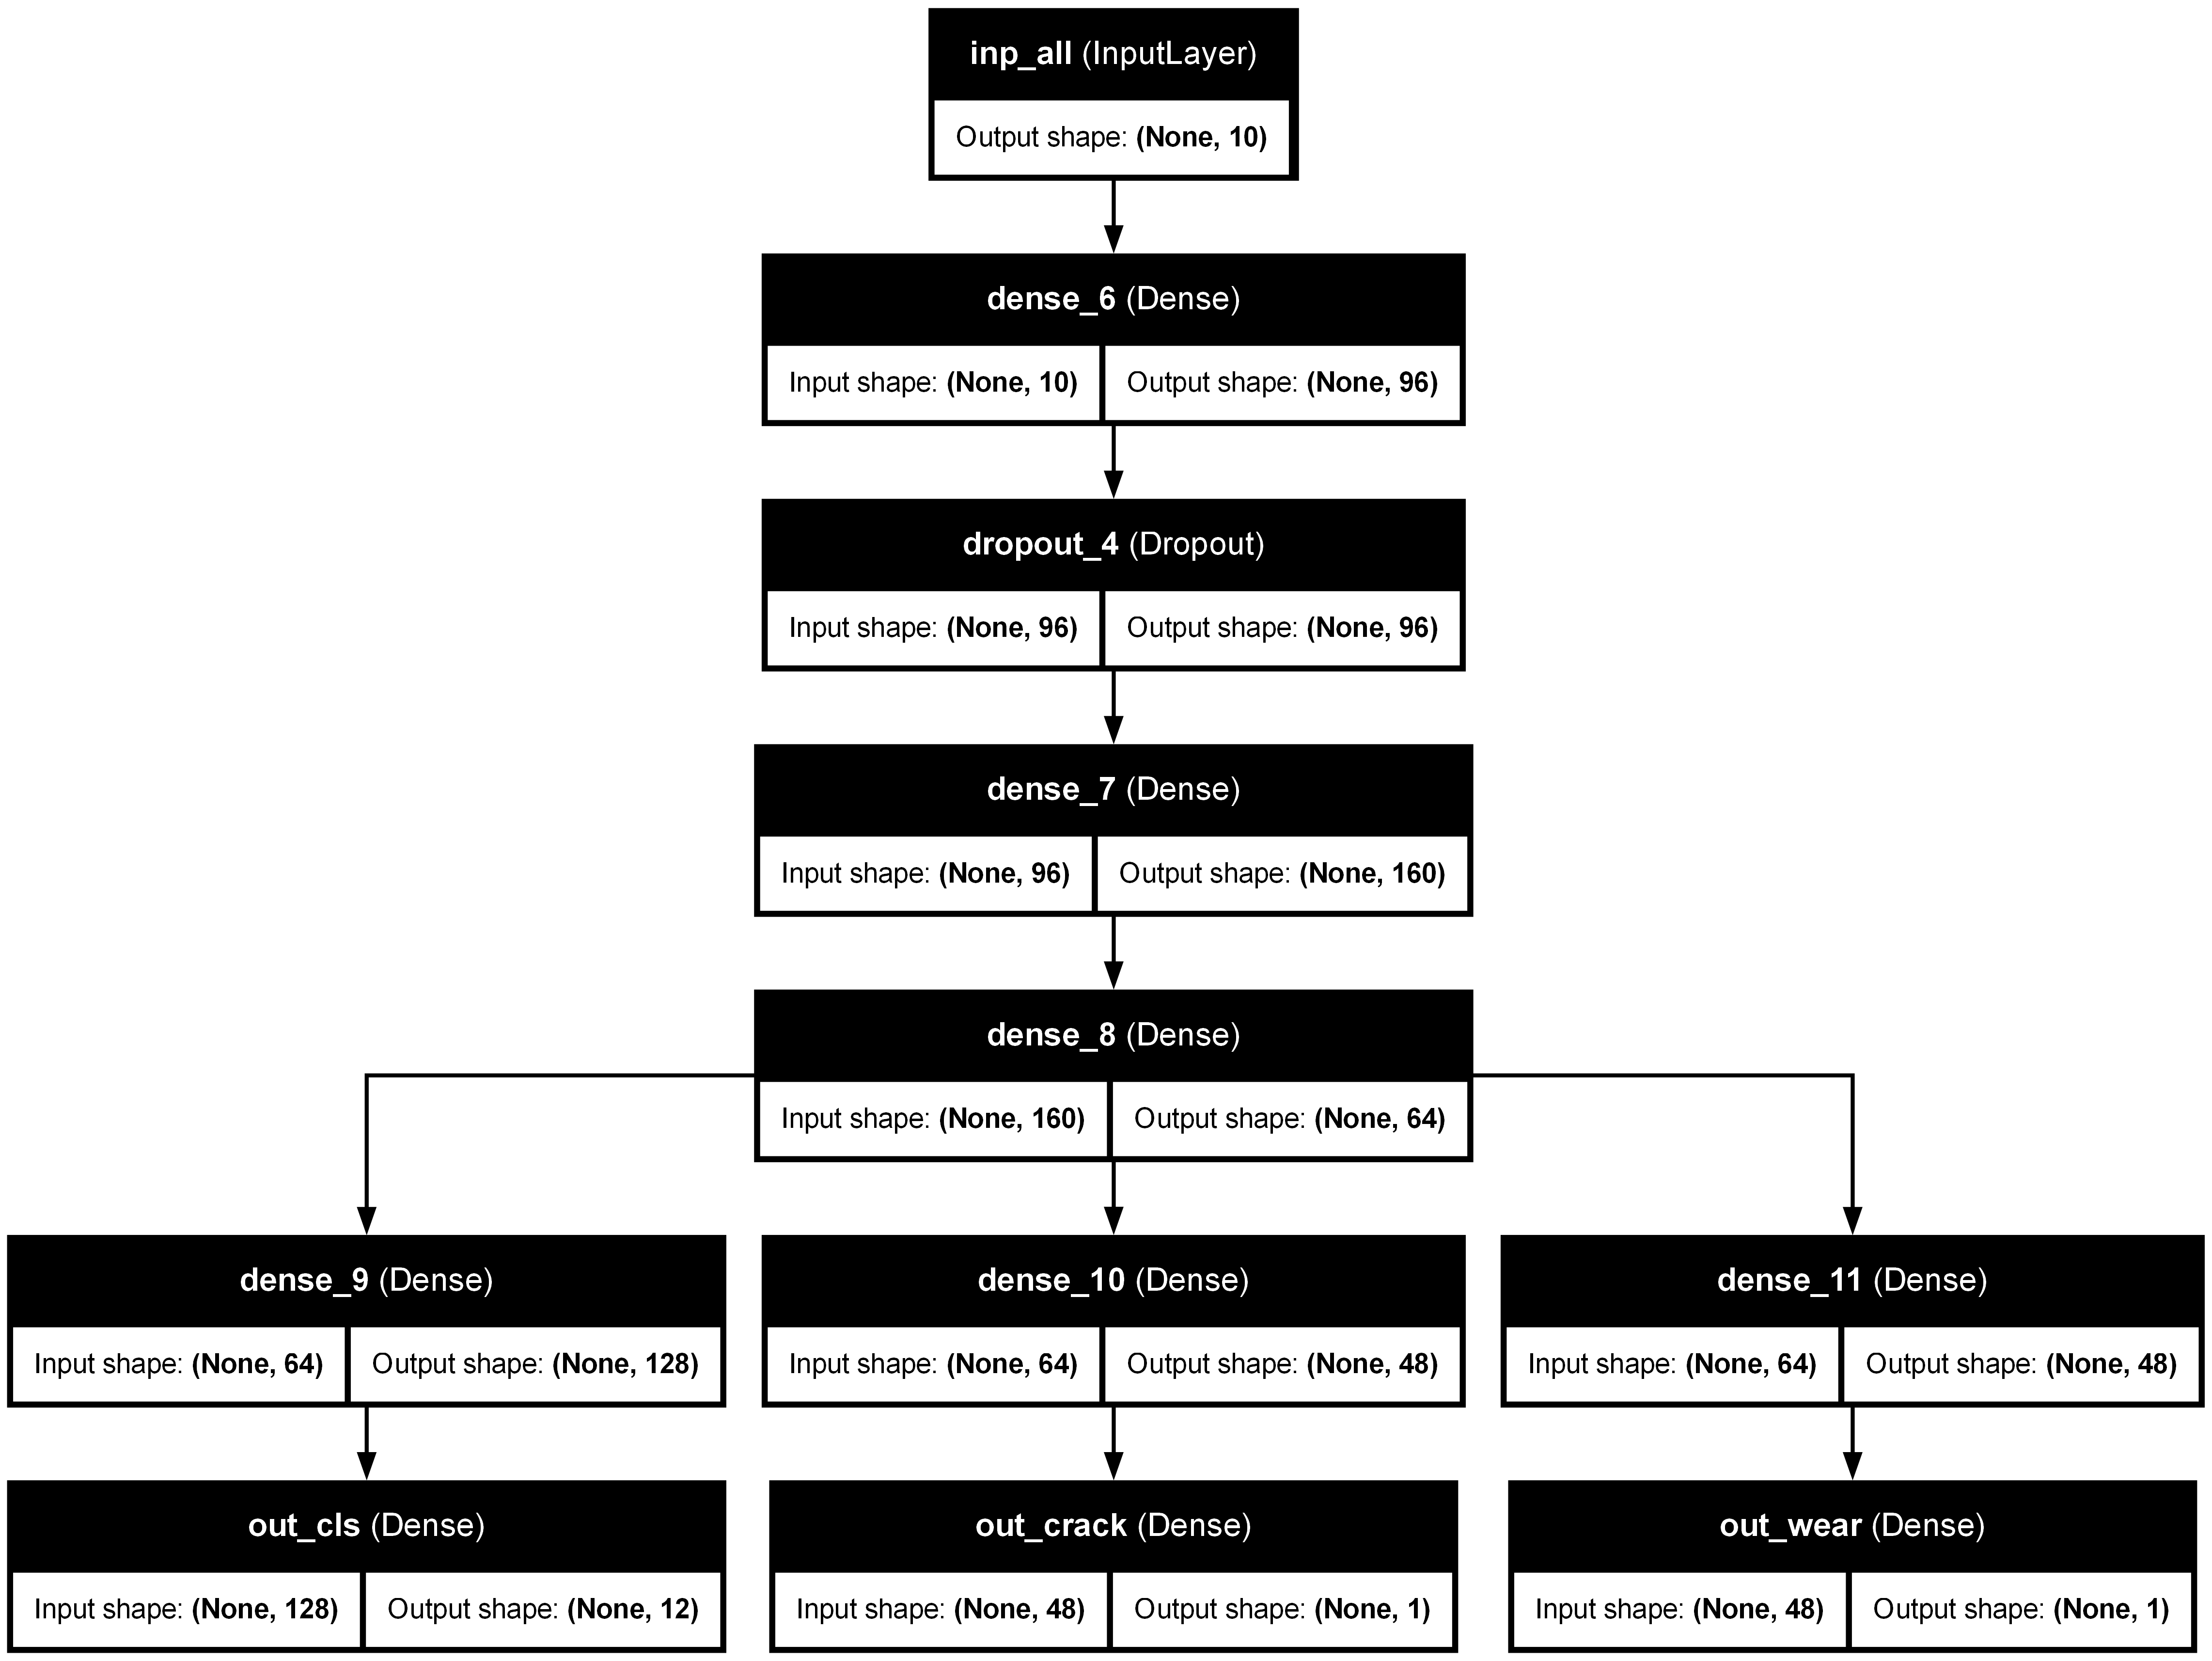


=== RESULTS (BEST HP) ===
Accuracy (classification): 0.9639
MAE CRACK distance:          0.1156
MAE WEAR distance:         0.1520

Classification report:
              precision    recall  f1-score   support

           0     0.9836    1.0000    0.9917        60
           1     0.9831    0.9667    0.9748        60
           2     0.9500    0.9500    0.9500        60
           3     1.0000    1.0000    1.0000        60
           4     0.9423    0.8167    0.8750        60
           5     0.9828    0.9500    0.9661        60
           6     0.9524    1.0000    0.9756        60
           7     0.9508    0.9667    0.9587        60
           8     0.9048    0.9500    0.9268        60
           9     0.9677    1.0000    0.9836        60
          10     0.9677    1.0000    0.9836        60
          11     0.9831    0.9667    0.9748        60

    accuracy                         0.9639       720
   macro avg     0.9640    0.9639    0.9634       720
weighted avg     0.9640    0.9639

In [21]:
# ============================================================
# Multitask NN Training (TensorFlow + KerasTuner)
# ============================================================

import os, numpy as np, tensorflow as tf, keras_tuner as kt
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, mean_absolute_error, classification_report
from tensorflow.keras.utils import plot_model
from IPython.display import Image, display

# -------- 0) Reproducibility --------
SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
np.random.seed(SEED); tf.random.set_seed(SEED)

# -------- 1) Variable verification --------
_needed = [
    "X_tr","X_te",
    "y_cls_tr","y_cls_te","y_crack_tr","y_crack_te","y_wear_tr","y_wear_te",
    "sw_crack_tr","sw_crack_te","sw_wear_tr","sw_wear_te"
]
assert all(v in globals() for v in _needed), \
    "Missing variables. Run preprocessing (split + transforms + feature selection + scaler) first."

n_features_all = int(X_tr.shape[1])
n_classes = int(np.unique(np.concatenate([y_cls_tr, y_cls_te])).size)

print(f"[Data] n_features={n_features_all}  n_classes={n_classes}")
print(f"[Data] X_tr={X_tr.shape}  X_te={X_te.shape}")

# -------- 2) Model definition --------
def build_model_single(hp, n_features, n_classes):
    act_trunk = hp.Choice("act_trunk", ["relu", "swish", "gelu", "elu"])

    units_1 = hp.Int("trunk_units_1", 64, 384, step=32)
    units_2 = hp.Int("trunk_units_2", 32, 256, step=32)
    use_trunk_3 = hp.Boolean("use_trunk_3", default=False)
    units_3 = hp.Int("trunk_units_3", 32, 192, step=32)

    drop_tr = hp.Float("trunk_dropout", 0.0, 0.7, step=0.1)

    l2_val = hp.Choice("l2_weight", [0.0, 1e-6, 1e-5, 1e-4, 5e-4])
    reg = tf.keras.regularizers.l2(l2_val) if l2_val > 0 else None

    units_cls = hp.Int("head_cls_units", 32, 192, step=32)
    units_crack = hp.Int("head_crack_units", 16, 128, step=16)
    units_w   = hp.Int("head_wear_units",16, 128, step=16)
    drop_heads = hp.Float("heads_dropout", 0.0, 0.5, step=0.1)

    lr = hp.Float("learning_rate", 1e-5, 1e-2, sampling="log")

    w_cls  = hp.Float("w_cls",  0.5, 2.0, step=0.25)
    w_crack  = hp.Float("w_crack",  0.5, 2.0, step=0.25)
    w_wear = hp.Float("w_wear", 0.5, 2.0, step=0.25)

    bs = hp.Choice("batch_size", [32, 48, 64, 96, 128])

    inp = layers.Input(shape=(n_features,), name="inp_all")

    h = layers.Dense(units_1, activation=act_trunk, kernel_initializer="he_normal",
                     kernel_regularizer=reg)(inp)
    if drop_tr > 0: h = layers.Dropout(drop_tr)(h)

    h = layers.Dense(units_2, activation=act_trunk, kernel_initializer="he_normal",
                     kernel_regularizer=reg)(h)

    if use_trunk_3:
        h = layers.Dense(units_3, activation=act_trunk, kernel_initializer="he_normal",
                         kernel_regularizer=reg)(h)

    # Heads
    h_cls  = layers.Dense(units_cls, activation="relu", kernel_initializer="he_normal",
                          kernel_regularizer=reg)(h)
    if drop_heads > 0: h_cls = layers.Dropout(drop_heads)(h_cls)

    h_crack = layers.Dense(units_crack, activation="relu", kernel_initializer="he_normal",
                          kernel_regularizer=reg)(h)
    if drop_heads > 0: h_crack = layers.Dropout(drop_heads)(h_crack)

    h_wear = layers.Dense(units_w, activation="relu", kernel_initializer="he_normal",
                          kernel_regularizer=reg)(h)
    if drop_heads > 0: h_wear = layers.Dropout(drop_heads)(h_wear)

    out_cls  = layers.Dense(n_classes, activation="softmax", name="out_cls")(h_cls)
    out_crack  = layers.Dense(1, name="out_crack")(h_crack)
    out_wear = layers.Dense(1, name="out_wear")(h_wear)

    model = models.Model(inp, [out_cls, out_crack, out_wear])

    opt = tf.keras.optimizers.Adam(learning_rate=lr)
    model.compile(
        optimizer=opt,
        loss={"out_cls":"sparse_categorical_crossentropy", "out_crack":"mse", "out_wear":"mse"},
        loss_weights={"out_cls":w_cls, "out_crack":w_crack, "out_wear":w_wear},
        metrics={"out_cls":["accuracy"], "out_crack":["mae"], "out_wear":["mae"]}
    )
    model._hp_bs = bs
    return model

# -------- 3) Tuner (Bayesian Optimization) --------
class BS_Tuner(kt.BayesianOptimization):
    def run_trial(self, trial, *args, **kwargs):
        bs = trial.hyperparameters.get("batch_size")
        if bs is not None:
            kwargs["batch_size"] = bs
        return super().run_trial(trial, *args, **kwargs)

tuner = BS_Tuner(
    hypermodel=lambda hp: build_model_single(hp, n_features_all, n_classes),
    objective=[
        kt.Objective("val_out_crack_mae", "min"),
        kt.Objective("val_out_wear_mae", "min"),
        kt.Objective("val_out_cls_accuracy", "max"),
    ],
    max_trials=50,
    executions_per_trial=1,
    directory="kt_runs",
    project_name="beam_multitask_final_features",
    overwrite=True
)

es_tune = EarlyStopping(monitor="val_loss", mode="min", patience=15, restore_best_weights=True, verbose=0)

# -------- 4) Fit masks / sample weights --------
# Classification uses all samples (weight=1); regressions use their masks
sw_cls_tr = np.ones_like(y_cls_tr, dtype="float32")

y_fit_tr  = [y_cls_tr, y_crack_tr, y_wear_tr]
sw_fit_tr = [sw_cls_tr, sw_crack_tr.astype("float32"), sw_wear_tr.astype("float32")]

print(">> Starting HP search...")
tuner.search(
    X_tr,
    y_fit_tr,
    sample_weight=sw_fit_tr,
    validation_split=0.2,
    epochs=400,
    verbose=2,
    callbacks=[es_tune],
)

best_hps = tuner.get_best_hyperparameters(1)[0]
print("\n>> Best hyperparameters found:")
for k, v in best_hps.values.items():
    print(f"  - {k}: {v}")

# -------- 5) Final training with best HP --------
best_model = tuner.hypermodel.build(best_hps)
bs = best_hps.values.get("batch_size", 64)

es_final = EarlyStopping(monitor="val_loss", mode="min", patience=20, restore_best_weights=True, verbose=1)
hist = best_model.fit(
    X_tr,
    y_fit_tr,
    sample_weight=sw_fit_tr,
    validation_split=0.2,
    epochs=400,
    batch_size=bs,
    verbose=2,
    callbacks=[es_final],
)

# -------- 6) Visualize model architecture --------
plot_model(best_model, to_file="best_model.png", show_shapes=True, show_layer_names=True, dpi=300)
display(Image("best_model.png"))

# -------- 7) TEST Evaluation --------
pred_cls_proba, pred_crack, pred_wear = best_model.predict(X_te, verbose=0)
pred_cls = np.argmax(pred_cls_proba, axis=-1)

acc = accuracy_score(y_cls_te, pred_cls)

m_crack  = sw_crack_te.astype(bool)
m_wear = sw_wear_te.astype(bool)

mae_crack  = mean_absolute_error(y_crack_te[m_crack],  pred_crack[m_crack].ravel())   if m_crack.sum()  > 0 else np.nan
mae_wear = mean_absolute_error(y_wear_te[m_wear], pred_wear[m_wear].ravel()) if m_wear.sum() > 0 else np.nan

print(f"\n=== RESULTS (BEST HP) ===")
print(f"Accuracy (classification): {acc:.4f}")
print(f"MAE CRACK distance:          {mae_crack:.4f}")
print(f"MAE WEAR distance:         {mae_wear:.4f}")
print("\nClassification report:")
print(classification_report(y_cls_te, pred_cls, digits=4))

# -------- 8) K-Fold (Important: do NOT re-scale inside fold if X_tr/X_te already scaled) --------
DO_KFOLD = True
if DO_KFOLD:
    print("\n>> Starting K-Fold ...")
    skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=SEED)
    accs, maes_crack, maes_wear = [], [], []

    X_full = np.concatenate([X_tr, X_te], axis=0)
    y_cls_full  = np.concatenate([y_cls_tr,  y_cls_te],  axis=0)
    y_crack_full  = np.concatenate([y_crack_tr,  y_crack_te],  axis=0)
    y_wear_full = np.concatenate([y_wear_tr, y_wear_te], axis=0)
    sw_crack_full = np.concatenate([sw_crack_tr, sw_crack_te], axis=0).astype("float32")
    sw_wear_full= np.concatenate([sw_wear_tr,sw_wear_te],axis=0).astype("float32")

    fold = 0
    for tr_idx, te_idx in skf.split(X_full, y_cls_full):
        fold += 1
        X_tr_f, X_te_f = X_full[tr_idx], X_full[te_idx]
        yc_tr_f, yc_te_f = y_cls_full[tr_idx], y_cls_full[te_idx]
        yu_tr_f, yu_te_f = y_crack_full[tr_idx], y_crack_full[te_idx]
        yw_tr_f, yw_te_f = y_wear_full[tr_idx], y_wear_full[te_idx]
        swc_tr_f, swc_te_f = sw_crack_full[tr_idx], sw_crack_full[te_idx]
        sww_tr_f, sww_te_f = sw_wear_full[tr_idx], sw_wear_full[te_idx]

        m = tuner.hypermodel.build(best_hps)
        es_fold = EarlyStopping(monitor="val_loss", mode="min", patience=25, restore_best_weights=True, verbose=0)

        m.fit(
            X_tr_f, [yc_tr_f, yu_tr_f, yw_tr_f],
            sample_weight=[np.ones_like(yc_tr_f, dtype="float32"), swc_tr_f, sww_tr_f],
            validation_split=0.2,
            epochs=500, batch_size=bs, verbose=0,
            callbacks=[es_fold]
        )

        p_cls_p, p_crack_p, p_wear_p = m.predict(X_te_f, verbose=0)
        p_cls = np.argmax(p_cls_p, axis=-1)

        accs.append(accuracy_score(yc_te_f, p_cls))

        mask_c = swc_te_f.astype(bool)
        mask_w = sww_te_f.astype(bool)
        maes_crack.append(mean_absolute_error(yu_te_f[mask_c], p_crack_p[mask_c].ravel()) if mask_c.sum() > 0 else np.nan)
        maes_wear.append(mean_absolute_error(yw_te_f[mask_w], p_wear_p[mask_w].ravel()) if mask_w.sum() > 0 else np.nan)

        print(f"Fold {fold}: ACC={accs[-1]:.4f} | MAE_crack={maes_crack[-1]:.4f} | MAE_wear={maes_wear[-1]:.4f}")

    print("\n=== K-FOLD summary ===")
    print(f"ACC   -> mean = {np.nanmean(accs):.4f}  std = {np.nanstd(accs):.4f}")
    print(f"MAE C -> mean = {np.nanmean(maes_crack):.4f}  std = {np.nanstd(maes_crack):.4f}")
    print(f"MAE W -> mean = {np.nanmean(maes_wear):.4f}  std = {np.nanstd(maes_wear):.4f}")

----------------------------------------------
Results
----------------------------------------------
----------------------------------------------

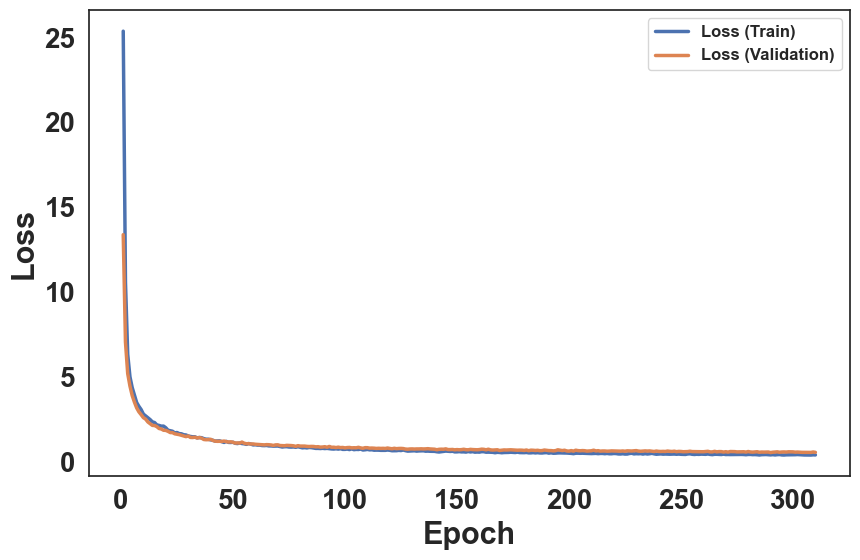

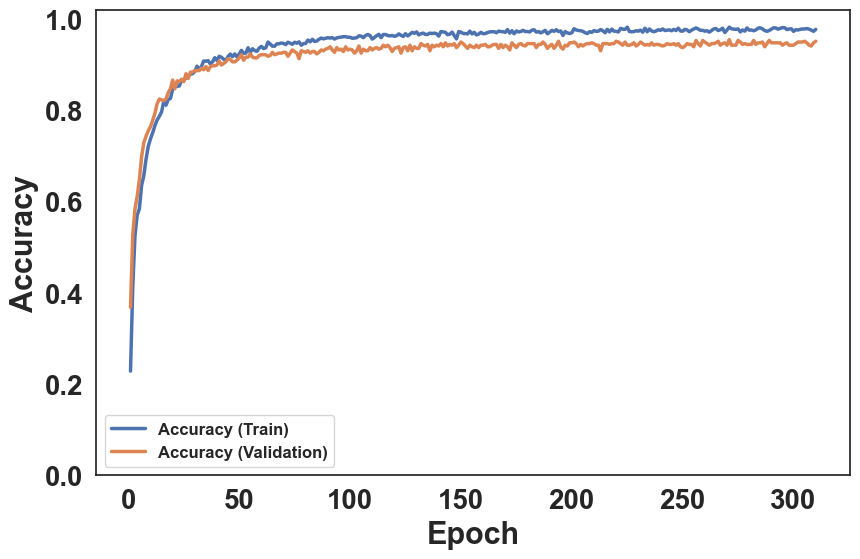

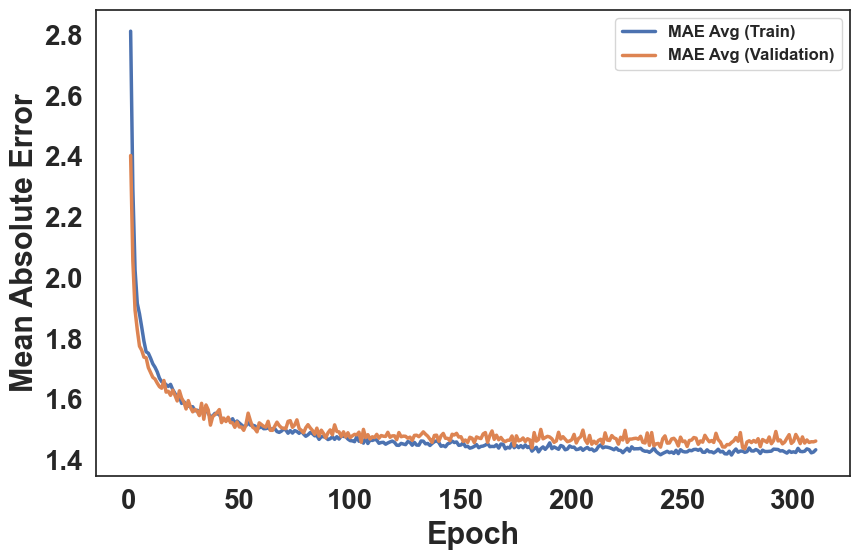

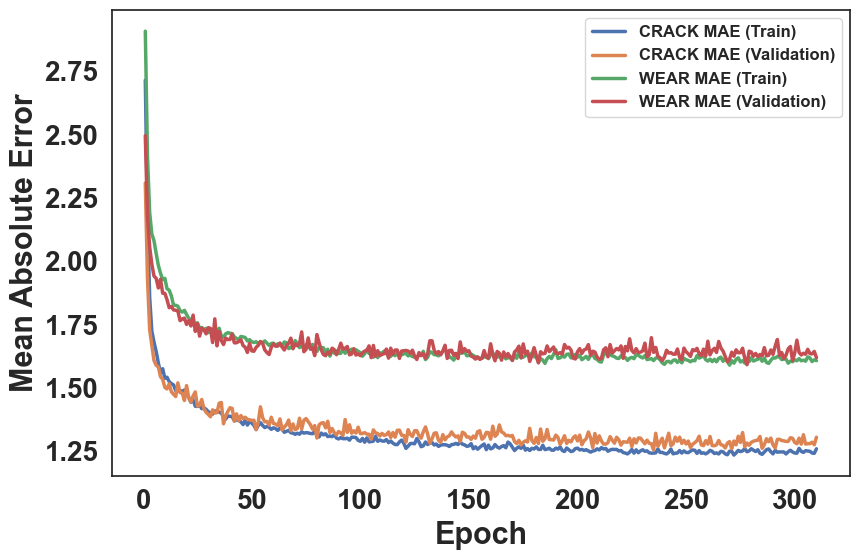

In [22]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ------------------------------------------------
# Global plot style (for publication readability)
# ------------------------------------------------
plt.rcParams.update({
    "font.size": 20,
    "font.weight": "bold",
    "axes.titlesize": 22,
    "axes.titleweight": "bold",
    "axes.labelsize": 22,
    "axes.labelweight": "bold",
    "xtick.labelsize": 20,
    "ytick.labelsize": 20,
    "legend.fontsize": 12
})

sns.set_style("white")

# ============================================================
# Training curves from Keras History
# ============================================================

assert "hist" in globals(), "Variable 'hist' not found. Run training cell first (best_model.fit)."

def get_hist(key, fallback_keys=()):
    if key in hist.history:
        return np.array(hist.history[key], dtype=float)
    for k in fallback_keys:
        if k in hist.history:
            return np.array(hist.history[k], dtype=float)
    return np.array([], dtype=float)

epochs = np.arange(1, len(hist.history.get("loss", [])) + 1)

# ---------------------------
# 1) Total Loss
# ---------------------------
loss_tr = get_hist("loss")
loss_va = get_hist("val_loss")

plt.figure(figsize=(9,6))

plt.plot(epochs, loss_tr, linewidth=2.5, label="Loss (Train)")
if loss_va.size:
    plt.plot(epochs, loss_va, linewidth=2.5, label="Loss (Validation)")

#plt.title("Total Loss", fontweight='bold')
plt.xlabel("Epoch", fontweight='bold')
plt.ylabel("Loss", fontweight='bold')

plt.legend()
plt.grid(False)

plt.tight_layout()
plt.show()

# -----------------------------------------
# 2) Classification Accuracy
# -----------------------------------------
acc_tr = get_hist("out_cls_accuracy", fallback_keys=("out_cls_acc", "accuracy"))
acc_va = get_hist("val_out_cls_accuracy", fallback_keys=("val_out_cls_acc", "val_accuracy"))

plt.figure(figsize=(9,6))

if acc_tr.size:
    plt.plot(epochs, acc_tr, linewidth=2.5, label="Accuracy (Train)")

if acc_va.size:
    plt.plot(epochs, acc_va, linewidth=2.5, label="Accuracy (Validation)")

#plt.title("Classification Accuracy (out_cls)", fontweight='bold')
plt.xlabel("Epoch", fontweight='bold')
plt.ylabel("Accuracy", fontweight='bold')

plt.ylim(0,1.02)

plt.legend()
plt.grid(False)

plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# 3) Regression MAE (average heads)
# ---------------------------------------------------------
mae_crack_tr  = get_hist("out_crack_mae")
mae_crack_va  = get_hist("val_out_crack_mae")
mae_wear_tr = get_hist("out_wear_mae")
mae_wear_va = get_hist("val_out_wear_mae")

if mae_crack_tr.size and mae_wear_tr.size:
    mae_tr_avg = 0.5 * (mae_crack_tr + mae_wear_tr)
elif mae_crack_tr.size:
    mae_tr_avg = mae_crack_tr
else:
    mae_tr_avg = mae_wear_tr

if mae_crack_va.size and mae_wear_va.size:
    mae_va_avg = 0.5 * (mae_crack_va + mae_wear_va)
elif mae_crack_va.size:
    mae_va_avg = mae_crack_va
else:
    mae_va_avg = mae_wear_va

plt.figure(figsize=(9,6))

if mae_tr_avg.size:
    plt.plot(epochs, mae_tr_avg, linewidth=2.5, label="MAE Avg (Train)")

if mae_va_avg.size:
    plt.plot(epochs, mae_va_avg, linewidth=2.5, label="MAE Avg (Validation)")

#plt.title("Regression MAE (Average of out_crack & out_wear)", fontweight='bold')
plt.xlabel("Epoch", fontweight='bold')
plt.ylabel("Mean Absolute Error", fontweight='bold') #MAE

plt.legend()
plt.grid(False)

plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# Optional diagnostic: MAE per regression head
# ---------------------------------------------------------
plt.figure(figsize=(9,6))

if mae_crack_tr.size:
    plt.plot(epochs, mae_crack_tr, linewidth=2.5, label="CRACK MAE (Train)")

if mae_crack_va.size:
    plt.plot(epochs, mae_crack_va, linewidth=2.5, label="CRACK MAE (Validation)")

if mae_wear_tr.size:
    plt.plot(epochs, mae_wear_tr, linewidth=2.5, label="WEAR MAE (Train)")

if mae_wear_va.size:
    plt.plot(epochs, mae_wear_va, linewidth=2.5, label="WEAR MAE (Validation)")

#plt.title("MAE per Regression Head", fontweight='bold')
plt.xlabel("Epoch", fontweight='bold')
plt.ylabel("Mean Absolute Error", fontweight='bold') #MAE

plt.legend()
plt.grid(False)

plt.tight_layout()
plt.show()

In [23]:
# ===================== EXPORT MODEL AND ARTIFACTS =====================
import os, json, time, joblib, numpy as np

# Folder versioned with timestamp
stamp = time.strftime("%Y%m%d_%H%M%S")
export_dir = f"export_beam_model_{stamp}"
os.makedirs(export_dir, exist_ok=True)

keras_path = os.path.join(export_dir, "model.keras")  

best_model.save(keras_path)

features_saved = False
try:
    with open(os.path.join(export_dir, "features.json"), "w", encoding="utf-8") as f:
        json.dump({"union_features": union_features}, f, ensure_ascii=False, indent=2)
    features_saved = True
except NameError:
    print("[NOTICE] 'union_features' is not in memory. Input columns were not exported.")

# 3) Tuner hyperparameters
try:
    with open(os.path.join(export_dir, "best_hparams.json"), "w", encoding="utf-8") as f:
        json.dump(best_hps.values, f, ensure_ascii=False, indent=2)
except NameError:
    print("[NOTICE] 'best_hps' is not in memory. Tuner hyperparameters were not exported.")

# 4) Training history
try:
    import pandas as pd
    pd.DataFrame(hist.history).to_csv(os.path.join(export_dir, "training_history.csv"), index=False)
except NameError:
    print("[NOTICE] 'hist' is not in memory. Training history was not exported.")

# 5) Metadata
meta = {
    "n_features": int(X_tr.shape[1]),
    "n_classes": int(np.unique(y_cls_te).size if 'y_cls_te' in globals() else n_classes),
    "paths": {
        "keras": keras_path,
    },
    "has_features": features_saved,
    "created_at": stamp,
    "keras_version_hint": "Keras 3+ (usar .keras para load_model)."
}
with open(os.path.join(export_dir, "meta.json"), "w", encoding="utf-8") as f:
    json.dump(meta, f, ensure_ascii=False, indent=2)

print("\n=== COMPLETE EXPORT ===")
print(f"Carpeta: {export_dir}")
print(f"- model.keras         : OK")
print(f"- features.json       : {'OK' if features_saved else 'NOT SAVED'}")
print("- best_hparams.json   : " + ("OK" if 'best_hps' in globals() else "NOT SAVED"))
print("- training_history.csv: " + ("OK" if 'hist' in globals() else "NOT SAVED"))
print("- meta.json           : OK")


=== COMPLETE EXPORT ===
Carpeta: export_beam_model_20260818_125913
- model.keras         : OK
- features.json       : OK
- best_hparams.json   : OK
- training_history.csv: OK
- meta.json           : OK



=== CLASSIFICATION (TEST) ===
Accuracy: 0.9639

              precision    recall  f1-score   support

           0     0.9836    1.0000    0.9917        60
           1     0.9831    0.9667    0.9748        60
           2     0.9500    0.9500    0.9500        60
           3     1.0000    1.0000    1.0000        60
           4     0.9423    0.8167    0.8750        60
           5     0.9828    0.9500    0.9661        60
           6     0.9524    1.0000    0.9756        60
           7     0.9508    0.9667    0.9587        60
           8     0.9048    0.9500    0.9268        60
           9     0.9677    1.0000    0.9836        60
          10     0.9677    1.0000    0.9836        60
          11     0.9831    0.9667    0.9748        60

    accuracy                         0.9639       720
   macro avg     0.9640    0.9639    0.9634       720
weighted avg     0.9640    0.9639    0.9634       720



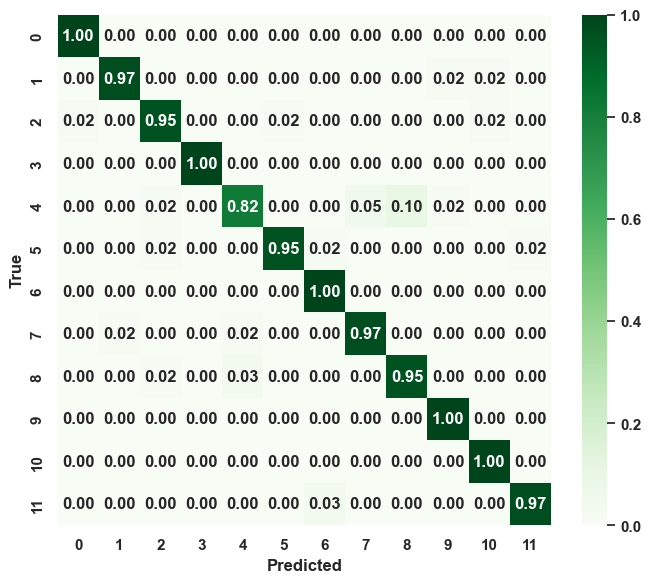

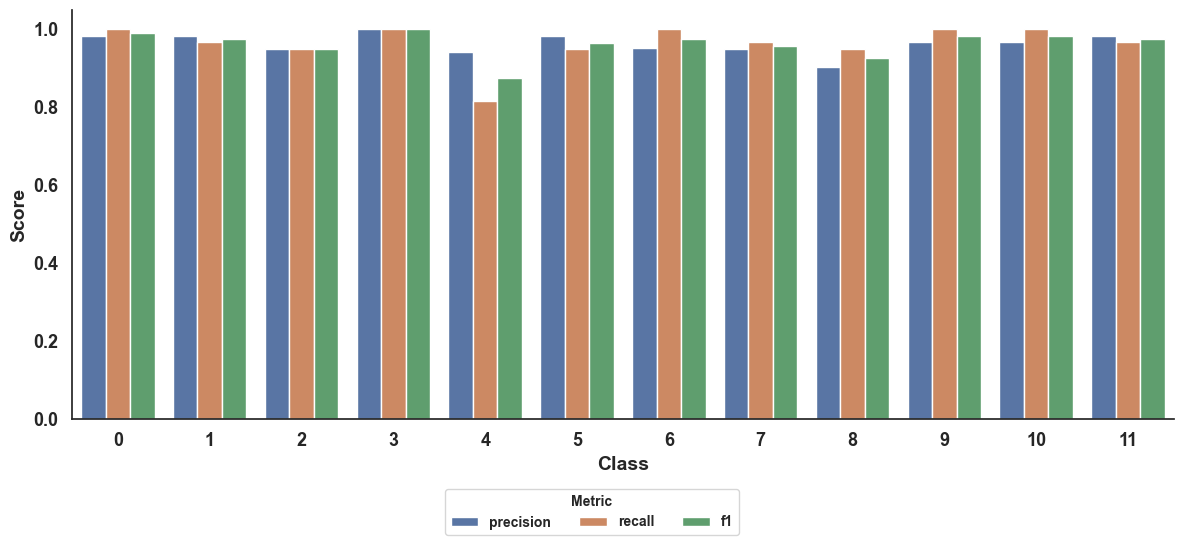

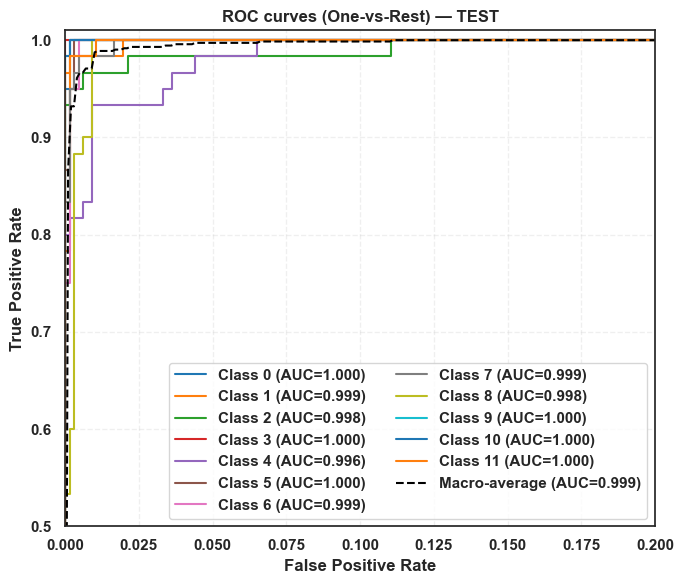


=== REGRESSION CRACK (TEST, mask_crack==1) ===
MAE: 0.1156 | RMSE: 0.2254 | R2: 0.9874 | MAPE: 2.99%

=== REGRESSION WEAR (TEST, mask_wear==1) ===
MAE: 0.1520 | RMSE: 0.2875 | R2: 0.9725 | MAPE: 4.34%


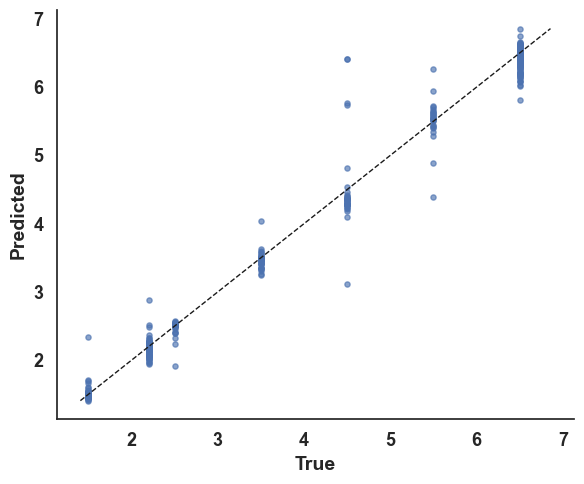

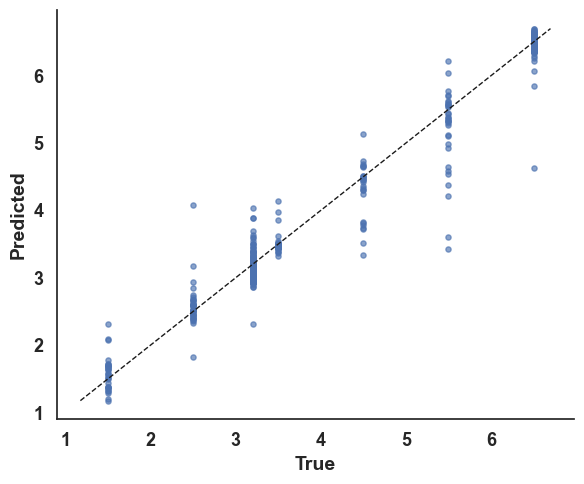

In [24]:
# ============================================================
# TEST Metrics + Plots (Multitask: out_cls + out_crack + out_wear)
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    confusion_matrix, classification_report, accuracy_score,
    precision_recall_fscore_support, roc_curve, auc,
    mean_absolute_error, mean_squared_error, r2_score
)

sns.set_theme(style="white")

# -------- 0) Checks --------
_needed = ["best_model", "X_te", "y_cls_te", "y_crack_te", "y_wear_te", "sw_crack_te", "sw_wear_te"]
assert all(v in globals() for v in _needed), "Missing required variables. Run training + preprocessing first."

# -------- 1) TEST Predictions --------
pred_cls_proba, pred_crack, pred_wear = best_model.predict(X_te, verbose=0)
pred_cls = np.argmax(pred_cls_proba, axis=-1)

# ============================================================
#                 CLASSIFICATION METRICS
# ============================================================

acc = accuracy_score(y_cls_te, pred_cls)
print(f"\n=== CLASSIFICATION (TEST) ===")
print(f"Accuracy: {acc:.4f}\n")
print(classification_report(y_cls_te, pred_cls, digits=4))

# -------- Confusion matrix (row-normalized only) --------
cm = confusion_matrix(y_cls_te, pred_cls)

cm_row_sum = cm.sum(axis=1, keepdims=True)
cm_norm = np.divide(
    cm,
    cm_row_sum,
    out=np.zeros_like(cm, dtype=float),
    where=(cm_row_sum != 0)
)

plt.figure(figsize=(7, 6))
sns.heatmap(
    cm_norm,
    annot=True,
    fmt=".2f",
    cmap="Greens",
    cbar=True
)

#plt.title("Confusion Matrix (Row-normalized) - MTL Model")
plt.xlabel("Predicted")
plt.ylabel("True")

plt.tight_layout()
plt.show()

# -------- Precision / Recall / F1 per class --------
prec, rec, f1, sup = precision_recall_fscore_support(
    y_cls_te,
    pred_cls,
    zero_division=0
)

df_prf = pd.DataFrame({
    "class": np.arange(len(prec)),
    "precision": prec,
    "recall": rec,
    "f1": f1,
    "support": sup
})

df_prf_melt = df_prf.melt(
    id_vars=["class", "support"],
    value_vars=["precision", "recall", "f1"],
    var_name="metric",
    value_name="score"
)

fig, ax = plt.subplots(figsize=(12, 5))

sns.barplot(
    data=df_prf_melt,
    x="class",
    y="score",
    hue="metric",
    ax=ax
)

# Sin título y sin grid
ax.set_title("")
ax.grid(False)

ax.set_xlabel("Class", fontsize=14, fontweight="bold")
ax.set_ylabel("Score", fontsize=14, fontweight="bold")
ax.set_ylim(0, 1.05)

ax.tick_params(axis="both", labelsize=13)

for label in ax.get_xticklabels():
    label.set_fontweight("bold")
for label in ax.get_yticklabels():
    label.set_fontweight("bold")

handles, labels = ax.get_legend_handles_labels()
ax.legend_.remove()

fig.legend(
    handles,
    labels,
    title="Metric",
    loc="lower center",
    bbox_to_anchor=(0.5, -0.10),
    ncol=3,
    frameon=True,
    fontsize=10,
    title_fontsize=10
)

sns.despine(ax=ax)

plt.tight_layout()
plt.show()

# -------- ROC curves one-vs-rest (multi-class) --------
try:
    n_cls = int(np.unique(y_cls_te).size)
    if n_cls >= 2:
        from sklearn.preprocessing import label_binarize

        y_true_bin = label_binarize(y_cls_te, classes=np.arange(n_cls))

        fpr, tpr, roc_auc = {}, {}, {}
        for c in range(n_cls):
            if y_true_bin[:, c].sum() == 0:
                continue
            fpr[c], tpr[c], _ = roc_curve(y_true_bin[:, c], pred_cls_proba[:, c])
            roc_auc[c] = auc(fpr[c], tpr[c])

        if len(roc_auc) > 0:
            # ---------- MACRO-AVERAGE ROC ----------
            fpr_grid = np.linspace(0.0, 1.0, 1000)

            tprs_interp = []
            for c in roc_auc.keys():
                tpr_interp = np.interp(fpr_grid, fpr[c], tpr[c])
                tpr_interp[0] = 0.0
                tprs_interp.append(tpr_interp)

            mean_tpr = np.mean(tprs_interp, axis=0)
            mean_tpr[-1] = 1.0
            auc_macro = auc(fpr_grid, mean_tpr)

            # ---------- PLOT ----------
            plt.figure(figsize=(7, 6))
            colors = sns.color_palette("tab10", n_cls)

            for c in range(n_cls):
                if c in roc_auc:
                    plt.plot(
                        fpr[c],
                        tpr[c],
                        lw=1.5,
                        color=colors[c],
                        label=f"Class {c} (AUC={roc_auc[c]:.3f})"
                    )

            plt.plot(
                fpr_grid,
                mean_tpr,
                lw=1.5,
                linestyle="--",
                color="black",
                label=f"Macro-average (AUC={auc_macro:.3f})"
            )

            plt.xlabel("False Positive Rate")
            plt.ylabel("True Positive Rate")
            plt.title("ROC curves (One-vs-Rest) — TEST")

            plt.xlim(0.0, 0.20)
            plt.ylim(0.50, 1.01)

            plt.grid(True, linestyle="--", alpha=0.3)
            plt.legend(loc="lower right", ncols=2, frameon=True)
            plt.tight_layout()
            plt.show()
        else:
            print("ROC curve skipped: at least one class must have positive samples in TEST.")
except Exception as e:
    print("ROC curve could not be drawn:", e)

# ============================================================
#                 REGRESSION METRICS
# ============================================================

def _safe_1d(a):
    a = np.asarray(a)
    return a.ravel().astype(float)

def reg_metrics_compat(y_true, y_pred):
    y_true = _safe_1d(y_true)
    y_pred = _safe_1d(y_pred)

    if y_true.size == 0:
        return np.nan, np.nan, np.nan, np.nan

    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))

    try:
        r2 = r2_score(y_true, y_pred)
    except Exception:
        r2 = np.nan

    mape = np.mean(
        np.abs((y_true - y_pred) / (np.abs(y_true) + 1e-8))
    ) * 100.0

    return mae, rmse, r2, mape

mask_crack = sw_crack_te.astype(bool)
mask_wear = sw_wear_te.astype(bool)

# --- CRACK ---
if mask_crack.sum() > 0:
    y_true_crack = _safe_1d(y_crack_te[mask_crack])
    y_pred_crack = _safe_1d(pred_crack[mask_crack])
    mae_c, rmse_c, r2_c, mape_c = reg_metrics_compat(y_true_crack, y_pred_crack)

    print(f"\n=== REGRESSION CRACK (TEST, mask_crack==1) ===")
    print(f"MAE: {mae_c:.4f} | RMSE: {rmse_c:.4f} | R2: {r2_c:.4f} | MAPE: {mape_c:.2f}%")
else:
    y_true_crack = y_pred_crack = np.array([])
    print("\nRegression CRACK: no samples with crack_mask==1 in TEST.")

# --- WEAR ---
if mask_wear.sum() > 0:
    y_true_wear = _safe_1d(y_wear_te[mask_wear])
    y_pred_wear = _safe_1d(pred_wear[mask_wear])
    mae_w, rmse_w, r2_w, mape_w = reg_metrics_compat(y_true_wear, y_pred_wear)

    print(f"\n=== REGRESSION WEAR (TEST, mask_wear==1) ===")
    print(f"MAE: {mae_w:.4f} | RMSE: {rmse_w:.4f} | R2: {r2_w:.4f} | MAPE: {mape_w:.2f}%")
else:
    y_true_wear = y_pred_wear = np.array([])
    print("\nRegression WEAR: no samples with wear_mask==1 in TEST.")

# ============================================================
#                 REGRESSION PLOTS
# ============================================================

def parity_plot(y_true, y_pred, title_prefix):
    if y_true.size == 0:
        return

    lo = min(float(np.min(y_true)), float(np.min(y_pred)))
    hi = max(float(np.max(y_true)), float(np.max(y_pred)))
    lims = [lo, hi]

    fig, ax = plt.subplots(figsize=(6, 5))

    ax.scatter(y_true, y_pred, s=14, alpha=0.65)
    ax.plot(lims, lims, "k--", lw=1)

    ax.set_xlabel("True", fontsize=14, fontweight="bold")
    ax.set_ylabel("Predicted", fontsize=14, fontweight="bold")

    # Sin título y sin líneas grises de fondo
    ax.set_title("")
    ax.grid(False)

    ax.tick_params(axis="both", labelsize=13)

    for label in ax.get_xticklabels():
        label.set_fontweight("bold")
    for label in ax.get_yticklabels():
        label.set_fontweight("bold")

    sns.despine(ax=ax)

    plt.tight_layout()
    plt.show()

parity_plot(y_true_crack, y_pred_crack, "CRACK distance (cm)")
parity_plot(y_true_wear, y_pred_wear, "WEAR distance (cm)")


=== GLOBAL CRACK LOCALIZATION ERROR (TEST) ===
MAE : 0.1156 cm = 1.156 mm
RMSE: 0.2254 cm = 2.254 mm

=== CRACK LOCALIZATION ERROR BY DAMAGE LOCATION ===


,location_cm,n,MAE_cm,MAE_mm,RMSE_cm,STD_cm,Median_cm,Max_cm
0,1.5,38,0.071703,0.717033,0.153521,0.137569,0.039151,0.841949
1,2.2,150,0.056039,0.560392,0.096566,0.078906,0.030104,0.679801
2,2.5,23,0.078086,0.780862,0.145882,0.125993,0.040193,0.584976
3,3.5,32,0.099490,0.994897,0.143565,0.105158,0.076134,0.544660
4,4.5,34,0.388422,3.884219,0.631962,0.505999,0.213304,1.915366
5,5.5,27,0.193238,1.932377,0.316723,0.255724,0.096841,1.114455
6,6.5,176,0.119157,1.191566,0.162771,0.111204,0.089194,0.693310



=== CRACK LOCALIZATION ERROR BY DAMAGE SEVERITY ===


,severity,n,MAE_cm,MAE_mm,RMSE_cm,STD_cm,Median_cm,Max_cm
0,Slight,120,0.132717,1.327167,0.346927,0.321882,0.039314,1.915366
1,Moderate,120,0.090427,0.904273,0.151387,0.121922,0.042961,0.757647
2,Severe,240,0.119701,1.197013,0.173211,0.125456,0.088942,1.114455



=== CRACK LOCALIZATION ERROR BY DAMAGE LOCATION AND SEVERITY ===


,severity,location_cm,n,MAE_cm,MAE_mm,RMSE_cm,STD_cm,Median_cm,Max_cm
14,Slight,1.5,15,0.110885,1.108853,0.228580,0.206899,0.050069,0.841949
15,Slight,2.2,60,0.044134,0.441338,0.103858,0.094807,0.020819,0.679801
16,Slight,2.5,8,0.042465,0.424652,0.054790,0.037012,0.030228,0.108496
17,Slight,3.5,7,0.061113,0.611130,0.066194,0.027471,0.071788,0.092122
18,Slight,4.5,15,0.623743,6.237434,0.918571,0.697995,0.211989,1.915366
19,Slight,5.5,7,0.095009,0.950092,0.113612,0.067288,0.091639,0.220152
20,Slight,6.5,8,0.103246,1.032460,0.162180,0.133706,0.080638,0.415466
0,Moderate,1.5,10,0.078556,0.785556,0.101714,0.068107,0.061033,0.208854
1,Moderate,2.2,60,0.029311,0.293108,0.036733,0.022327,0.024380,0.129354
2,Moderate,2.5,6,0.109093,1.090931,0.138208,0.092953,0.090070,0.256433


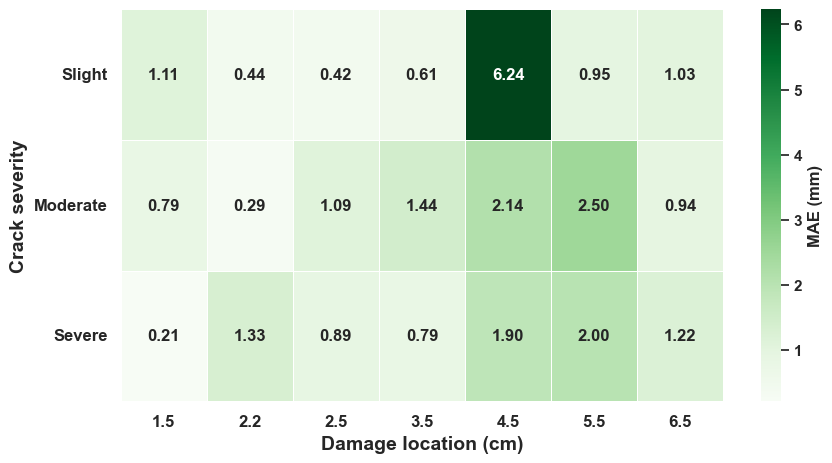

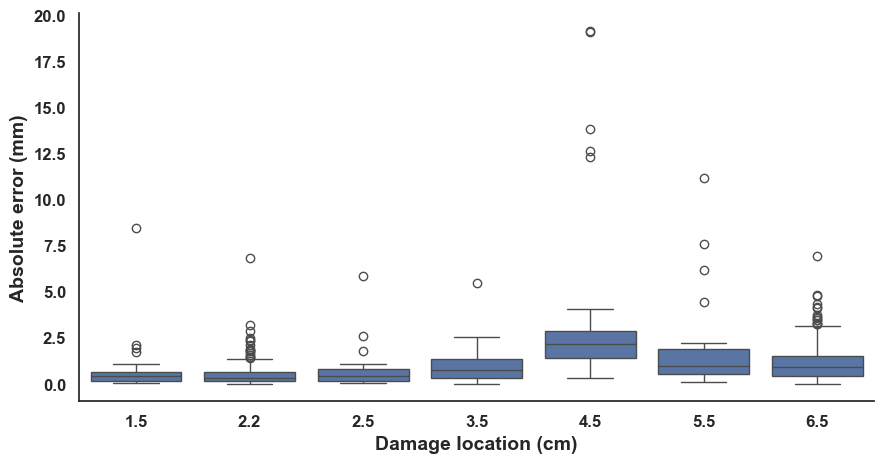

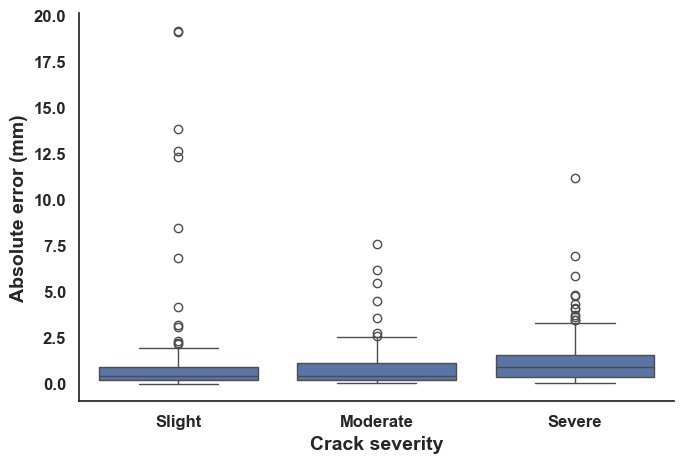


Saved CSV files:
- crack_error_by_location.csv
- crack_error_by_severity.csv
- crack_error_by_location_and_severity.csv


In [25]:
# ============================================================
# CRACK LOCALIZATION ERROR BY DAMAGE LOCATION AND SEVERITY
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import mean_absolute_error, mean_squared_error

sns.set_theme(style="white")

# -------- 0) Checks --------
_needed = ["best_model", "X_te", "y_cls_te", "y_crack_te", "sw_crack_te"]
assert all(v in globals() for v in _needed), "Missing required variables. Run training + preprocessing first."

# -------- 1) Predictions if not already available --------
if "pred_crack" not in globals():
    pred_outputs = best_model.predict(X_te, verbose=0)
    pred_crack = pred_outputs[1]

# -------- 2) Helper functions --------
def _safe_1d(a):
    return np.asarray(a).ravel().astype(float)

def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

# -------- 3) Select only samples where crack localization is physically meaningful --------
mask_crack = np.asarray(sw_crack_te).astype(bool).ravel()

y_true_crack_all = _safe_1d(y_crack_te)
y_pred_crack_all = _safe_1d(pred_crack)
y_cls_all = np.asarray(y_cls_te).ravel().astype(int)

y_true_crack = y_true_crack_all[mask_crack]
y_pred_crack = y_pred_crack_all[mask_crack]
y_cls_crack = y_cls_all[mask_crack]

abs_error_cm = np.abs(y_true_crack - y_pred_crack)
abs_error_mm = abs_error_cm * 10.0

# -------- 4) Crack severity mapping from class labels --------
# Class meaning:
# 1 = slight crack
# 2 = moderate crack
# 3 = severe crack
# 7 = severe crack + slight wear
# 8 = severe crack + moderate wear
# 9 = severe wear + slight crack
# 10 = severe wear + moderate crack
# 11 = severe wear + severe crack

crack_severity_map = {
    1: "Slight",
    2: "Moderate",
    3: "Severe",
    7: "Severe",
    8: "Severe",
    9: "Slight",
    10: "Moderate",
    11: "Severe"
}

damage_type_map = {
    1: "Single crack",
    2: "Single crack",
    3: "Single crack",
    7: "Combined damage",
    8: "Combined damage",
    9: "Combined damage",
    10: "Combined damage",
    11: "Combined damage"
}

severity = pd.Series(y_cls_crack).map(crack_severity_map).values
damage_type = pd.Series(y_cls_crack).map(damage_type_map).values

# -------- 5) Build dataframe --------
df_crack_error = pd.DataFrame({
    "class": y_cls_crack,
    "damage_type": damage_type,
    "severity": severity,
    "location_cm": np.round(y_true_crack, 2),
    "y_true_cm": y_true_crack,
    "y_pred_cm": y_pred_crack,
    "abs_error_cm": abs_error_cm,
    "abs_error_mm": abs_error_mm
})

# Remove any unexpected classes if needed
df_crack_error = df_crack_error.dropna(subset=["severity"]).copy()

# -------- 6) Global crack-localization metrics --------
global_mae_cm = df_crack_error["abs_error_cm"].mean()
global_mae_mm = df_crack_error["abs_error_mm"].mean()
global_rmse_cm = rmse(df_crack_error["y_true_cm"], df_crack_error["y_pred_cm"])
global_rmse_mm = global_rmse_cm * 10.0

print("\n=== GLOBAL CRACK LOCALIZATION ERROR (TEST) ===")
print(f"MAE : {global_mae_cm:.4f} cm = {global_mae_mm:.3f} mm")
print(f"RMSE: {global_rmse_cm:.4f} cm = {global_rmse_mm:.3f} mm")

# -------- 7) Summary by location --------
df_by_location = (
    df_crack_error
    .groupby("location_cm")
    .agg(
        n=("abs_error_cm", "size"),
        MAE_cm=("abs_error_cm", "mean"),
        MAE_mm=("abs_error_mm", "mean"),
        RMSE_cm=("abs_error_cm", lambda x: np.sqrt(np.mean(np.square(x)))),
        STD_cm=("abs_error_cm", "std"),
        Median_cm=("abs_error_cm", "median"),
        Max_cm=("abs_error_cm", "max")
    )
    .reset_index()
)

print("\n=== CRACK LOCALIZATION ERROR BY DAMAGE LOCATION ===")
display(df_by_location)

# -------- 8) Summary by severity --------
severity_order = ["Slight", "Moderate", "Severe"]

df_by_severity = (
    df_crack_error
    .groupby("severity")
    .agg(
        n=("abs_error_cm", "size"),
        MAE_cm=("abs_error_cm", "mean"),
        MAE_mm=("abs_error_mm", "mean"),
        RMSE_cm=("abs_error_cm", lambda x: np.sqrt(np.mean(np.square(x)))),
        STD_cm=("abs_error_cm", "std"),
        Median_cm=("abs_error_cm", "median"),
        Max_cm=("abs_error_cm", "max")
    )
    .reindex(severity_order)
    .reset_index()
)

print("\n=== CRACK LOCALIZATION ERROR BY DAMAGE SEVERITY ===")
display(df_by_severity)

# -------- 9) Summary by location × severity --------
df_by_loc_sev = (
    df_crack_error
    .groupby(["severity", "location_cm"])
    .agg(
        n=("abs_error_cm", "size"),
        MAE_cm=("abs_error_cm", "mean"),
        MAE_mm=("abs_error_mm", "mean"),
        RMSE_cm=("abs_error_cm", lambda x: np.sqrt(np.mean(np.square(x)))),
        STD_cm=("abs_error_cm", "std"),
        Median_cm=("abs_error_cm", "median"),
        Max_cm=("abs_error_cm", "max")
    )
    .reset_index()
)

df_by_loc_sev["severity"] = pd.Categorical(
    df_by_loc_sev["severity"],
    categories=severity_order,
    ordered=True
)

df_by_loc_sev = df_by_loc_sev.sort_values(["severity", "location_cm"])

print("\n=== CRACK LOCALIZATION ERROR BY DAMAGE LOCATION AND SEVERITY ===")
display(df_by_loc_sev)

# -------- 10) Heatmap: MAE in mm by location × severity --------
heatmap_data = df_by_loc_sev.pivot(
    index="severity",
    columns="location_cm",
    values="MAE_mm"
).reindex(severity_order)

fig, ax = plt.subplots(figsize=(9, 4.8))

sns.heatmap(
    heatmap_data,
    annot=True,
    fmt=".2f",
    cmap="Greens",
    cbar_kws={"label": "MAE (mm)"},
    linewidths=0.5,
    linecolor="white",
    ax=ax
)

ax.set_title("")
ax.set_xlabel("Damage location (cm)", fontsize=14, fontweight="bold")
ax.set_ylabel("Crack severity", fontsize=14, fontweight="bold")

ax.tick_params(axis="both", labelsize=12)

for label in ax.get_xticklabels():
    label.set_fontweight("bold")
for label in ax.get_yticklabels():
    label.set_fontweight("bold")
    label.set_rotation(0)

plt.tight_layout()
plt.show()

# -------- 11) Optional: Boxplot of absolute error by location --------
fig, ax = plt.subplots(figsize=(9, 4.8))

sns.boxplot(
    data=df_crack_error,
    x="location_cm",
    y="abs_error_mm",
    ax=ax
)

ax.set_title("")
ax.grid(False)
ax.set_xlabel("Damage location (cm)", fontsize=14, fontweight="bold")
ax.set_ylabel("Absolute error (mm)", fontsize=14, fontweight="bold")

ax.tick_params(axis="both", labelsize=12)

for label in ax.get_xticklabels():
    label.set_fontweight("bold")
for label in ax.get_yticklabels():
    label.set_fontweight("bold")

sns.despine(ax=ax)
plt.tight_layout()
plt.show()

# -------- 12) Optional: Boxplot of absolute error by severity --------
fig, ax = plt.subplots(figsize=(7, 4.8))

sns.boxplot(
    data=df_crack_error,
    x="severity",
    y="abs_error_mm",
    order=severity_order,
    ax=ax
)

ax.set_title("")
ax.grid(False)
ax.set_xlabel("Crack severity", fontsize=14, fontweight="bold")
ax.set_ylabel("Absolute error (mm)", fontsize=14, fontweight="bold")

ax.tick_params(axis="both", labelsize=12)

for label in ax.get_xticklabels():
    label.set_fontweight("bold")
for label in ax.get_yticklabels():
    label.set_fontweight("bold")

sns.despine(ax=ax)
plt.tight_layout()
plt.show()

# -------- 13) Optional: Save tables for article or supplementary material --------
df_by_location.to_csv("crack_error_by_location.csv", index=False)
df_by_severity.to_csv("crack_error_by_severity.csv", index=False)
df_by_loc_sev.to_csv("crack_error_by_location_and_severity.csv", index=False)

print("\nSaved CSV files:")
print("- crack_error_by_location.csv")
print("- crack_error_by_severity.csv")
print("- crack_error_by_location_and_severity.csv")


=== GLOBAL WEAR LOCALIZATION ERROR (TEST) ===
MAE : 0.1520 cm = 1.520 mm
RMSE: 0.2875 cm = 2.875 mm

=== WEAR LOCALIZATION ERROR BY DAMAGE LOCATION ===


,location_cm,n,MAE_cm,MAE_mm,RMSE_cm,STD_cm,Median_cm,Max_cm
0,1.5,31,0.200615,2.006155,0.263010,0.172892,0.176716,0.808565
1,2.5,38,0.181193,1.811934,0.330384,0.279973,0.102114,1.580257
2,3.2,150,0.140890,1.408898,0.204135,0.148215,0.093442,0.889155
3,3.5,28,0.101275,1.012752,0.177131,0.147990,0.051795,0.637686
4,4.5,26,0.326674,3.266736,0.468001,0.341763,0.176918,1.158216
5,5.5,33,0.451548,4.515479,0.683379,0.520897,0.205009,2.073283
6,6.5,174,0.071789,0.717888,0.171828,0.156564,0.038009,1.874769



=== WEAR LOCALIZATION ERROR BY DAMAGE SEVERITY ===


,severity,n,MAE_cm,MAE_mm,RMSE_cm,STD_cm,Median_cm,Max_cm
0,Slight,120,0.286061,2.860608,0.471247,0.376061,0.158524,2.073283
1,Moderate,120,0.133687,1.336867,0.200410,0.149932,0.072603,0.694002
2,Severe,240,0.094124,0.941240,0.184798,0.159363,0.051686,1.874769



=== WEAR LOCALIZATION ERROR BY DAMAGE LOCATION AND SEVERITY ===


,severity,location_cm,n,MAE_cm,MAE_mm,RMSE_cm,STD_cm,Median_cm,Max_cm
14,Slight,1.5,7,0.300299,3.002991,0.370649,0.234667,0.203373,0.808565
15,Slight,2.5,17,0.177343,1.773428,0.396711,0.365786,0.102093,1.580257
16,Slight,3.2,60,0.157985,1.579846,0.222511,0.158013,0.131093,0.889155
17,Slight,3.5,6,0.298596,2.985963,0.366404,0.232617,0.266238,0.637686
18,Slight,4.5,11,0.595584,5.955839,0.680801,0.345899,0.691592,1.158216
19,Slight,5.5,13,0.858239,8.582394,1.042388,0.615763,0.861480,2.073283
20,Slight,6.5,6,0.038531,0.385306,0.044282,0.023908,0.040707,0.072033
0,Moderate,1.5,11,0.207389,2.073892,0.282196,0.200715,0.130002,0.591187
1,Moderate,2.5,11,0.220237,2.202370,0.291867,0.200874,0.175699,0.681955
2,Moderate,3.2,60,0.151983,1.519829,0.216199,0.155061,0.095009,0.694002


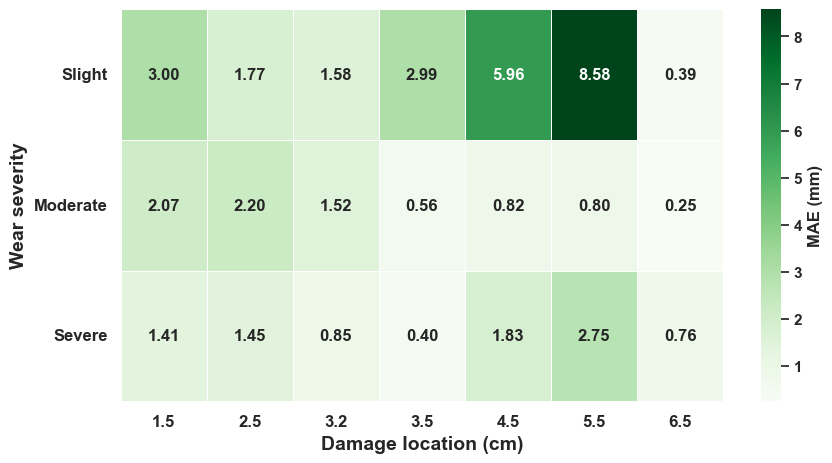

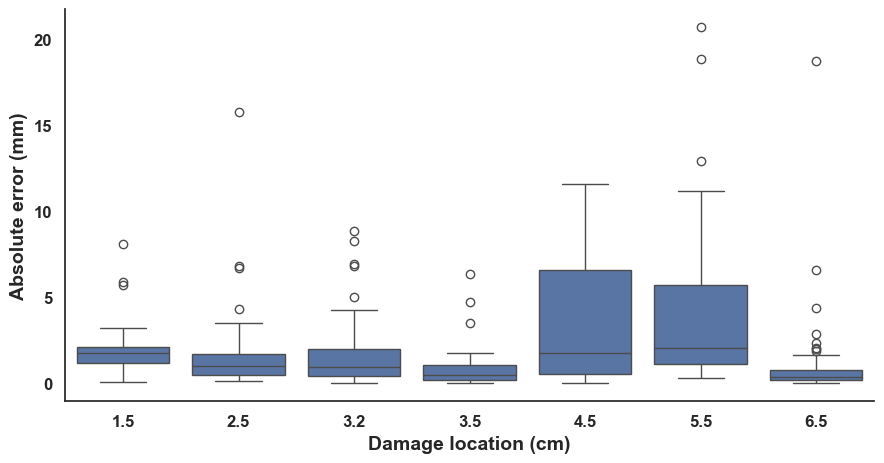

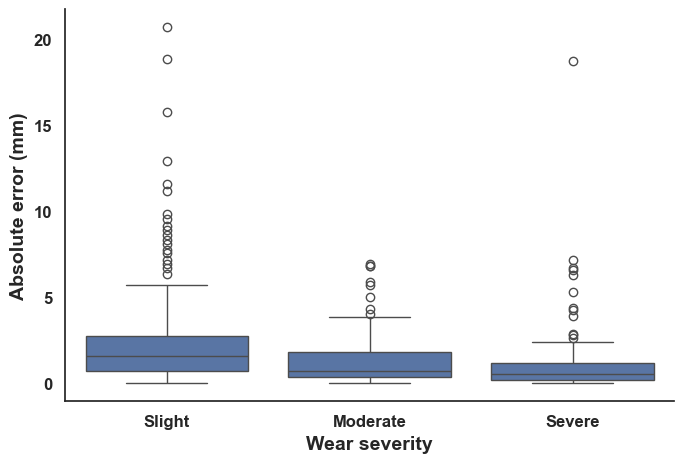


Saved CSV files:
- wear_error_by_location.csv
- wear_error_by_severity.csv
- wear_error_by_location_and_severity.csv


In [26]:
# ============================================================
# WEAR LOCALIZATION ERROR BY DAMAGE LOCATION AND SEVERITY
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import mean_squared_error

sns.set_theme(style="white")

# -------- 0) Checks --------
_needed = ["best_model", "X_te", "y_cls_te", "y_wear_te", "sw_wear_te"]
assert all(v in globals() for v in _needed), "Missing required variables. Run training + preprocessing first."

# -------- 1) Predictions if not already available --------
if "pred_wear" not in globals():
    pred_outputs = best_model.predict(X_te, verbose=0)
    pred_wear = pred_outputs[2]

# -------- 2) Helper functions --------
def _safe_1d(a):
    return np.asarray(a).ravel().astype(float)

def rmse_from_error(error_values):
    return np.sqrt(np.mean(np.square(error_values)))

# -------- 3) Select only samples where wear localization is physically meaningful --------
mask_wear = np.asarray(sw_wear_te).astype(bool).ravel()

y_true_wear_all = _safe_1d(y_wear_te)
y_pred_wear_all = _safe_1d(pred_wear)
y_cls_all = np.asarray(y_cls_te).ravel().astype(int)

y_true_wear = y_true_wear_all[mask_wear]
y_pred_wear = y_pred_wear_all[mask_wear]
y_cls_wear = y_cls_all[mask_wear]

abs_error_cm = np.abs(y_true_wear - y_pred_wear)
abs_error_mm = abs_error_cm * 10.0

# -------- 4) Wear severity mapping from class labels --------
# Class meaning:
# 4 = slight wear
# 5 = moderate wear
# 6 = severe wear
# 7 = severe crack + slight wear
# 8 = severe crack + moderate wear
# 9 = severe wear + slight crack
# 10 = severe wear + moderate crack
# 11 = severe wear + severe crack

wear_severity_map = {
    4: "Slight",
    5: "Moderate",
    6: "Severe",
    7: "Slight",
    8: "Moderate",
    9: "Severe",
    10: "Severe",
    11: "Severe"
}

damage_type_map = {
    4: "Single wear",
    5: "Single wear",
    6: "Single wear",
    7: "Combined damage",
    8: "Combined damage",
    9: "Combined damage",
    10: "Combined damage",
    11: "Combined damage"
}

severity = pd.Series(y_cls_wear).map(wear_severity_map).values
damage_type = pd.Series(y_cls_wear).map(damage_type_map).values

# -------- 5) Build dataframe --------
df_wear_error = pd.DataFrame({
    "class": y_cls_wear,
    "damage_type": damage_type,
    "severity": severity,
    "location_cm": np.round(y_true_wear, 2),
    "y_true_cm": y_true_wear,
    "y_pred_cm": y_pred_wear,
    "abs_error_cm": abs_error_cm,
    "abs_error_mm": abs_error_mm
})

df_wear_error = df_wear_error.dropna(subset=["severity"]).copy()

# -------- 6) Global wear-localization metrics --------
global_mae_cm = df_wear_error["abs_error_cm"].mean()
global_mae_mm = df_wear_error["abs_error_mm"].mean()
global_rmse_cm = rmse_from_error(df_wear_error["abs_error_cm"])
global_rmse_mm = global_rmse_cm * 10.0

print("\n=== GLOBAL WEAR LOCALIZATION ERROR (TEST) ===")
print(f"MAE : {global_mae_cm:.4f} cm = {global_mae_mm:.3f} mm")
print(f"RMSE: {global_rmse_cm:.4f} cm = {global_rmse_mm:.3f} mm")

# -------- 7) Summary by location --------
df_wear_by_location = (
    df_wear_error
    .groupby("location_cm")
    .agg(
        n=("abs_error_cm", "size"),
        MAE_cm=("abs_error_cm", "mean"),
        MAE_mm=("abs_error_mm", "mean"),
        RMSE_cm=("abs_error_cm", lambda x: np.sqrt(np.mean(np.square(x)))),
        STD_cm=("abs_error_cm", "std"),
        Median_cm=("abs_error_cm", "median"),
        Max_cm=("abs_error_cm", "max")
    )
    .reset_index()
)

print("\n=== WEAR LOCALIZATION ERROR BY DAMAGE LOCATION ===")
display(df_wear_by_location)

# -------- 8) Summary by severity --------
severity_order = ["Slight", "Moderate", "Severe"]

df_wear_by_severity = (
    df_wear_error
    .groupby("severity")
    .agg(
        n=("abs_error_cm", "size"),
        MAE_cm=("abs_error_cm", "mean"),
        MAE_mm=("abs_error_mm", "mean"),
        RMSE_cm=("abs_error_cm", lambda x: np.sqrt(np.mean(np.square(x)))),
        STD_cm=("abs_error_cm", "std"),
        Median_cm=("abs_error_cm", "median"),
        Max_cm=("abs_error_cm", "max")
    )
    .reindex(severity_order)
    .reset_index()
)

print("\n=== WEAR LOCALIZATION ERROR BY DAMAGE SEVERITY ===")
display(df_wear_by_severity)

# -------- 9) Summary by location × severity --------
df_wear_by_loc_sev = (
    df_wear_error
    .groupby(["severity", "location_cm"])
    .agg(
        n=("abs_error_cm", "size"),
        MAE_cm=("abs_error_cm", "mean"),
        MAE_mm=("abs_error_mm", "mean"),
        RMSE_cm=("abs_error_cm", lambda x: np.sqrt(np.mean(np.square(x)))),
        STD_cm=("abs_error_cm", "std"),
        Median_cm=("abs_error_cm", "median"),
        Max_cm=("abs_error_cm", "max")
    )
    .reset_index()
)

df_wear_by_loc_sev["severity"] = pd.Categorical(
    df_wear_by_loc_sev["severity"],
    categories=severity_order,
    ordered=True
)

df_wear_by_loc_sev = df_wear_by_loc_sev.sort_values(["severity", "location_cm"])

print("\n=== WEAR LOCALIZATION ERROR BY DAMAGE LOCATION AND SEVERITY ===")
display(df_wear_by_loc_sev)

# -------- 10) Heatmap: MAE in mm by location × severity --------
heatmap_data = df_wear_by_loc_sev.pivot(
    index="severity",
    columns="location_cm",
    values="MAE_mm"
).reindex(severity_order)

fig, ax = plt.subplots(figsize=(9, 4.8))

sns.heatmap(
    heatmap_data,
    annot=True,
    fmt=".2f",
    cmap="Greens",
    cbar_kws={"label": "MAE (mm)"},
    linewidths=0.5,
    linecolor="white",
    ax=ax
)

ax.set_title("")
ax.set_xlabel("Damage location (cm)", fontsize=14, fontweight="bold")
ax.set_ylabel("Wear severity", fontsize=14, fontweight="bold")

ax.tick_params(axis="both", labelsize=12)

for label in ax.get_xticklabels():
    label.set_fontweight("bold")
for label in ax.get_yticklabels():
    label.set_fontweight("bold")
    label.set_rotation(0)

plt.tight_layout()
plt.show()

# -------- 11) Optional: Boxplot of absolute error by location --------
fig, ax = plt.subplots(figsize=(9, 4.8))

sns.boxplot(
    data=df_wear_error,
    x="location_cm",
    y="abs_error_mm",
    ax=ax
)

ax.set_title("")
ax.grid(False)
ax.set_xlabel("Damage location (cm)", fontsize=14, fontweight="bold")
ax.set_ylabel("Absolute error (mm)", fontsize=14, fontweight="bold")

ax.tick_params(axis="both", labelsize=12)

for label in ax.get_xticklabels():
    label.set_fontweight("bold")
for label in ax.get_yticklabels():
    label.set_fontweight("bold")

sns.despine(ax=ax)
plt.tight_layout()
plt.show()

# -------- 12) Optional: Boxplot of absolute error by severity --------
fig, ax = plt.subplots(figsize=(7, 4.8))

sns.boxplot(
    data=df_wear_error,
    x="severity",
    y="abs_error_mm",
    order=severity_order,
    ax=ax
)

ax.set_title("")
ax.grid(False)
ax.set_xlabel("Wear severity", fontsize=14, fontweight="bold")
ax.set_ylabel("Absolute error (mm)", fontsize=14, fontweight="bold")

ax.tick_params(axis="both", labelsize=12)

for label in ax.get_xticklabels():
    label.set_fontweight("bold")
for label in ax.get_yticklabels():
    label.set_fontweight("bold")

sns.despine(ax=ax)
plt.tight_layout()
plt.show()

# -------- 13) Optional: Save tables --------
df_wear_by_location.to_csv("wear_error_by_location.csv", index=False)
df_wear_by_severity.to_csv("wear_error_by_severity.csv", index=False)
df_wear_by_loc_sev.to_csv("wear_error_by_location_and_severity.csv", index=False)

print("\nSaved CSV files:")
print("- wear_error_by_location.csv")
print("- wear_error_by_severity.csv")
print("- wear_error_by_location_and_severity.csv")


=== CLASSIFICATION (TRAIN) ===
Accuracy: 0.9826

              precision    recall  f1-score   support

           0     1.0000    1.0000    1.0000       240
           1     0.9917    0.9958    0.9938       240
           2     0.9753    0.9875    0.9814       240
           3     0.9794    0.9917    0.9855       240
           4     0.9954    0.9083    0.9499       240
           5     0.9713    0.9875    0.9793       240
           6     0.9708    0.9708    0.9708       240
           7     0.9877    1.0000    0.9938       240
           8     0.9363    0.9792    0.9572       240
           9     1.0000    1.0000    1.0000       240
          10     0.9958    0.9917    0.9937       240
          11     0.9916    0.9792    0.9853       240

    accuracy                         0.9826      2880
   macro avg     0.9829    0.9826    0.9826      2880
weighted avg     0.9829    0.9826    0.9826      2880



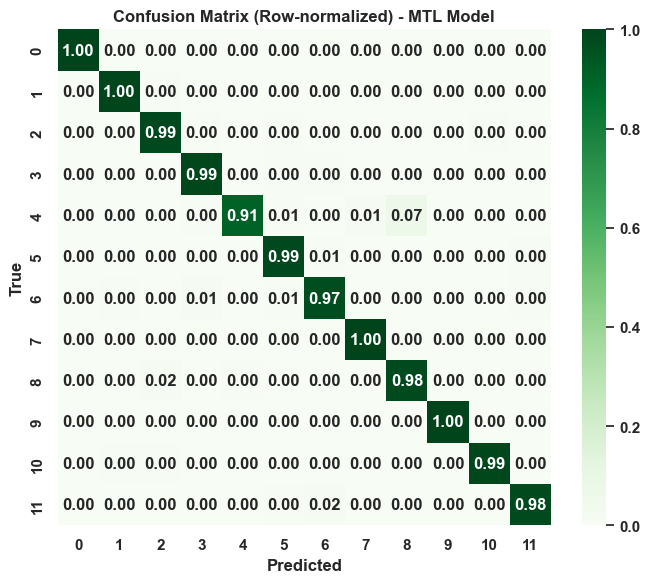

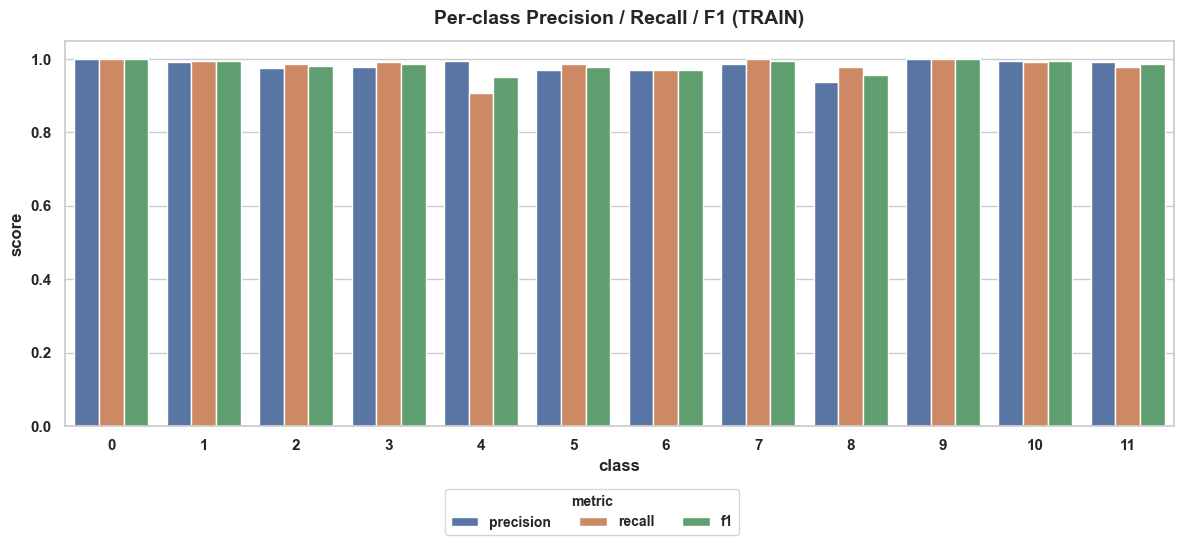

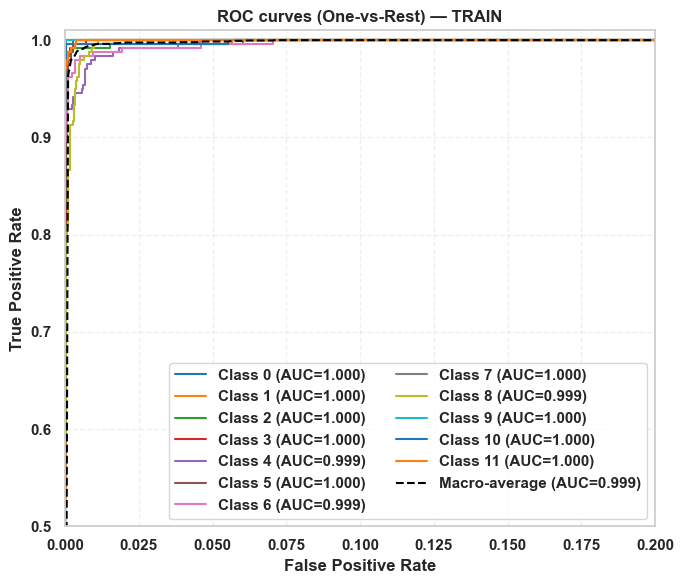


=== REGRESSION CRACK (TRAIN, mask_crack==1) ===
MAE: 0.0892 | RMSE: 0.1400 | R2: 0.9951 | MAPE: 2.26%

=== REGRESSION WEAR (TRAIN, mask_wear==1) ===
MAE: 0.1192 | RMSE: 0.2099 | R2: 0.9851 | MAPE: 3.30%


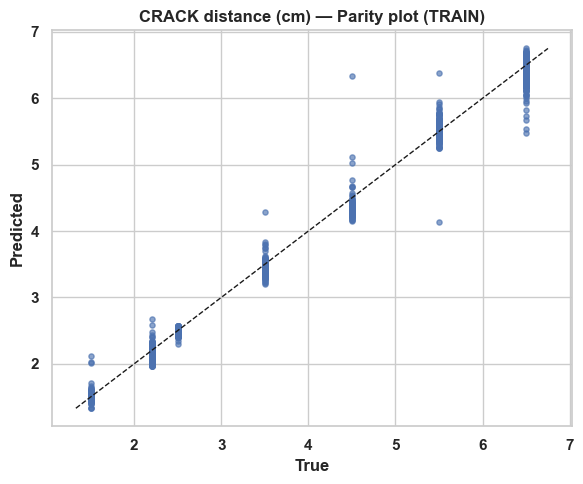

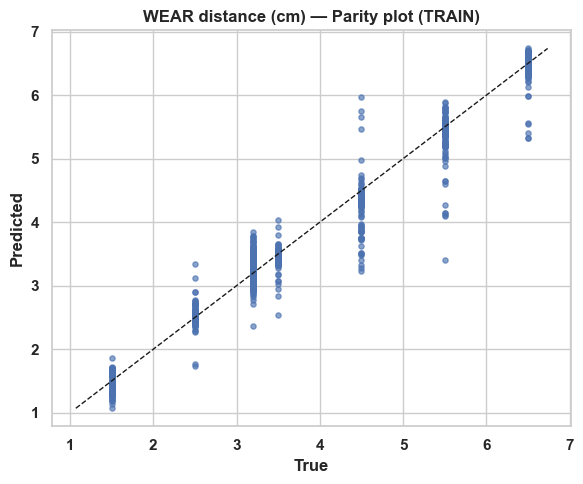

In [27]:
# ============================================================
# TRAIN Metrics + Plots (Multitask: out_cls + out_crack + out_wear)
# Adapted to TRAIN variables:
#   X_tr, y_cls_tr, y_crack_tr, y_wear_tr, sw_crack_tr, sw_wear_tr
#   best_model (trained)
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    confusion_matrix, classification_report, accuracy_score,
    precision_recall_fscore_support, roc_curve, auc,
    mean_absolute_error, mean_squared_error, r2_score
)

sns.set(style="whitegrid")

# -------- 0) Checks --------
_needed = ["best_model", "X_tr", "y_cls_tr", "y_crack_tr", "y_wear_tr", "sw_crack_tr", "sw_wear_tr"]
assert all(v in globals() for v in _needed), "Missing required variables. Run training + preprocessing first."

# -------- 1) TRAIN Predictions --------
pred_cls_proba, pred_crack, pred_wear = best_model.predict(X_tr, verbose=0)
pred_cls = np.argmax(pred_cls_proba, axis=-1)

# ============================================================
#                 CLASSIFICATION METRICS (TRAIN)
# ============================================================

acc = accuracy_score(y_cls_tr, pred_cls)
print(f"\n=== CLASSIFICATION (TRAIN) ===")
print(f"Accuracy: {acc:.4f}\n")
print(classification_report(y_cls_tr, pred_cls, digits=4))

# -------- Confusion matrices (counts + row-normalized) --------
#cm = confusion_matrix(y_cls_tr, pred_cls)
#cm_row_sum = cm.sum(axis=1, keepdims=True)
#cm_norm = np.divide(cm, cm_row_sum, out=np.zeros_like(cm, dtype=float), where=(cm_row_sum != 0))

#fig, axs = plt.subplots(1, 2, figsize=(14, 5))

#sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=axs[0])
#axs[0].set_title("Confusion Matrix (Counts) — TRAIN")
#axs[0].set_xlabel("Predicted"); axs[0].set_ylabel("True")

#sns.heatmap(cm_norm, annot=True, fmt=".2f", cmap="Greens", ax=axs[1])
#axs[1].set_title("Confusion Matrix (Row-normalized) — TRAIN")
#axs[1].set_xlabel("Predicted"); axs[1].set_ylabel("True")

#plt.tight_layout()
#plt.show()

# -------- Confusion matrix (row-normalized only) --------
cm = confusion_matrix(y_cls_tr, pred_cls)

# Row-normalization
cm_row_sum = cm.sum(axis=1, keepdims=True)
cm_norm = np.divide(
    cm,
    cm_row_sum,
    out=np.zeros_like(cm, dtype=float),
    where=(cm_row_sum != 0)
)

plt.figure(figsize=(7, 6))
sns.heatmap(
    cm_norm,
    annot=True,
    fmt=".2f",
    cmap="Greens",
    cbar=True
)

plt.title("Confusion Matrix (Row-normalized) - MTL Model")
plt.xlabel("Predicted")
plt.ylabel("True")

plt.tight_layout()
plt.show()

# -------- Precision / Recall / F1 per class --------
prec, rec, f1, sup = precision_recall_fscore_support(y_cls_tr, pred_cls, zero_division=0)

df_prf = pd.DataFrame({
    "class": np.arange(len(prec)),
    "precision": prec,
    "recall": rec,
    "f1": f1,
    "support": sup
})

df_prf_melt = df_prf.melt(
    id_vars=["class", "support"],
    value_vars=["precision", "recall", "f1"],
    var_name="metric",
    value_name="score"
)

fig, ax = plt.subplots(figsize=(12, 5))
sns.barplot(data=df_prf_melt, x="class", y="score", hue="metric", ax=ax)
ax.set_title("Per-class Precision / Recall / F1 (TRAIN)", fontsize=14, pad=12)
ax.set_ylim(0, 1.05)

handles, labels = ax.get_legend_handles_labels()
ax.legend_.remove()

fig.legend(
    handles, labels,
    title="metric",
    loc="lower center",
    bbox_to_anchor=(0.5, -0.10),
    ncol=3,
    frameon=True,
    fontsize=10,
    title_fontsize=10
)

plt.tight_layout()
plt.show()

# -------- ROC curves one-vs-rest (multi-class) --------
try:
    n_cls = int(np.unique(y_cls_tr).size)
    if n_cls >= 2:
        from sklearn.preprocessing import label_binarize

        y_true_bin = label_binarize(y_cls_tr, classes=np.arange(n_cls))

        fpr, tpr, roc_auc = {}, {}, {}
        for c in range(n_cls):
            # if a class is absent, roc_curve fails
            if y_true_bin[:, c].sum() == 0:
                continue
            fpr[c], tpr[c], _ = roc_curve(y_true_bin[:, c], pred_cls_proba[:, c])
            roc_auc[c] = auc(fpr[c], tpr[c])

        if len(roc_auc) > 0:
            # ---------- MACRO-AVERAGE ROC ----------
            fpr_grid = np.linspace(0.0, 1.0, 1000)

            tprs_interp = []
            for c in roc_auc.keys():
                tpr_interp = np.interp(fpr_grid, fpr[c], tpr[c])
                tpr_interp[0] = 0.0
                tprs_interp.append(tpr_interp)

            mean_tpr = np.mean(tprs_interp, axis=0)
            mean_tpr[-1] = 1.0
            auc_macro = auc(fpr_grid, mean_tpr)

            plt.figure(figsize=(7, 6))
            colors = sns.color_palette("tab10", n_cls)

            for c in range(n_cls):
                if c in roc_auc:
                    plt.plot(
                        fpr[c], tpr[c],
                        lw=1.5,
                        color=colors[c],
                        label=f"Class {c} (AUC={roc_auc[c]:.3f})"
                    )

            plt.plot(
                fpr_grid, mean_tpr,
                lw=1.5,
                linestyle="--",
                color="black",
                label=f"Macro-average (AUC={auc_macro:.3f})"
            )

            plt.xlabel("False Positive Rate")
            plt.ylabel("True Positive Rate")
            plt.title("ROC curves (One-vs-Rest) — TRAIN")

            # keep same zoom style as your test cell
            plt.xlim(0.0, 0.20)
            plt.ylim(0.50, 1.01)

            plt.grid(True, linestyle="--", alpha=0.3)
            plt.legend(loc="lower right", ncols=2, frameon=True)
            plt.tight_layout()
            plt.show()
        else:
            print("ROC curve skipped: at least one class must have positive samples in TRAIN.")
except Exception as e:
    print("ROC curve could not be drawn:", e)

# ============================================================
#                 REGRESSION METRICS (TRAIN)
# ============================================================

def _safe_1d(a):
    a = np.asarray(a)
    return a.ravel().astype(float)

def reg_metrics_compat(y_true, y_pred):
    y_true = _safe_1d(y_true)
    y_pred = _safe_1d(y_pred)
    if y_true.size == 0:
        return np.nan, np.nan, np.nan, np.nan

    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))

    try:
        r2 = r2_score(y_true, y_pred)
    except Exception:
        r2 = np.nan

    mape = np.mean(np.abs((y_true - y_pred) / (np.abs(y_true) + 1e-8))) * 100.0
    return mae, rmse, r2, mape

mask_crack  = sw_crack_tr.astype(bool)
mask_wear = sw_wear_tr.astype(bool)

# --- CRACK ---
if mask_crack.sum() > 0:
    y_true_crack = _safe_1d(y_crack_tr[mask_crack])
    y_pred_crack = _safe_1d(pred_crack[mask_crack])
    mae_c, rmse_c, r2_c, mape_c = reg_metrics_compat(y_true_crack, y_pred_crack)

    print(f"\n=== REGRESSION CRACK (TRAIN, mask_crack==1) ===")
    print(f"MAE: {mae_c:.4f} | RMSE: {rmse_c:.4f} | R2: {r2_c:.4f} | MAPE: {mape_c:.2f}%")
else:
    y_true_crack = y_pred_crack = np.array([])
    print("\nRegression CRACK: no samples with crack_mask==1 in TRAIN.")

# --- WEAR ---
if mask_wear.sum() > 0:
    y_true_wear = _safe_1d(y_wear_tr[mask_wear])
    y_pred_wear = _safe_1d(pred_wear[mask_wear])
    mae_w, rmse_w, r2_w, mape_w = reg_metrics_compat(y_true_wear, y_pred_wear)

    print(f"\n=== REGRESSION WEAR (TRAIN, mask_wear==1) ===")
    print(f"MAE: {mae_w:.4f} | RMSE: {rmse_w:.4f} | R2: {r2_w:.4f} | MAPE: {mape_w:.2f}%")
else:
    y_true_wear = y_pred_wear = np.array([])
    print("\nRegression WEAR: no samples with wear_mask==1 in TRAIN.")

# ============================================================
#                 REGRESSION PLOTS (TRAIN)
# ============================================================

def parity_plot(y_true, y_pred, title_prefix):
    if y_true.size == 0:
        return
    lo = min(float(np.min(y_true)), float(np.min(y_pred)))
    hi = max(float(np.max(y_true)), float(np.max(y_pred)))
    lims = [lo, hi]

    plt.figure(figsize=(6, 5))
    plt.scatter(y_true, y_pred, s=14, alpha=0.65)
    plt.plot(lims, lims, "k--", lw=1)
    plt.xlabel("True")
    plt.ylabel("Predicted")
    plt.title(f"{title_prefix} — Parity plot (TRAIN)")
    plt.tight_layout()
    plt.show()

parity_plot(y_true_crack,  y_pred_crack,  "CRACK distance (cm)")
parity_plot(y_true_wear, y_pred_wear, "WEAR distance (cm)")

----------------------------------------------
Preprocessing Sensitivity Analysis
----------------------------------------------
----------------------------------------------


In [28]:
# ============================================================
# PREPROCESSING SENSITIVITY ANALYSIS — HELPERS
#
# Evaluated factors:
#   1. Yeo-Johnson transformation
#   2. Upper winsorization of f4_Hz and f5_Hz
#
# RobustScaler is retained in all configurations.
# The final 10-feature subset and optimized model
# hyperparameters remain fixed.
# ============================================================

import os
import gc
import random
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path
from sklearn.preprocessing import PowerTransformer, RobustScaler
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    mean_absolute_error,
)
from tensorflow.keras.callbacks import EarlyStopping


# ------------------------------------------------------------
# 1. Verify required variables
# ------------------------------------------------------------

_required_sensitivity = [
    "X_tr_raw_split",
    "X_te_raw_split",
    "feature_names_raw_split",
    "y_cls_tr_sensitivity",
    "y_cls_te_sensitivity",
    "y_crack_tr_sensitivity",
    "y_crack_te_sensitivity",
    "y_wear_tr_sensitivity",
    "y_wear_te_sensitivity",
    "sw_crack_tr_sensitivity",
    "sw_crack_te_sensitivity",
    "sw_wear_tr_sensitivity",
    "sw_wear_te_sensitivity",
    "X_tr",
    "X_te",
    "feature_names",
    "build_model_single",
    "best_hps",
]

missing_sensitivity = [
    variable
    for variable in _required_sensitivity
    if variable not in globals()
]

assert not missing_sensitivity, (
    "Missing variables for preprocessing sensitivity: "
    f"{missing_sensitivity}. Run the split, raw snapshot, "
    "main preprocessing, and model-training cells first."
)


# ------------------------------------------------------------
# 2. Preserve the final reference pipeline
#
# At this notebook position:
# - X_tr and X_te must contain the final scaled 10-feature data.
# - feature_names must contain the final 10 descriptors.
# ------------------------------------------------------------

X_tr_reference_pipeline = np.asarray(X_tr).copy()
X_te_reference_pipeline = np.asarray(X_te).copy()
feature_names_reference_pipeline = list(feature_names)

SENSITIVITY_FEATURES = list(feature_names_reference_pipeline)

EXPECTED_FINAL_FEATURES = {
    "f1_Hz",
    "f2_Hz",
    "f3_Hz",
    "f4_Hz",
    "f5_Hz",
    "a1",
    "a2",
    "a4",
    "a5",
    "m2",
}

assert len(SENSITIVITY_FEATURES) == 10, (
    "The sensitivity analysis expects the final 10-feature set, "
    f"but {len(SENSITIVITY_FEATURES)} features were found."
)

assert set(SENSITIVITY_FEATURES) == EXPECTED_FINAL_FEATURES, (
    "The current final features do not match the 10 features "
    "reported in the manuscript.\n"
    f"Current: {SENSITIVITY_FEATURES}"
)

print("[Sensitivity] Fixed final features:")
print(SENSITIVITY_FEATURES)


# ------------------------------------------------------------
# 3. Preprocessing definitions
# ------------------------------------------------------------

SENSITIVITY_YJ_COLUMNS = [
    "FC_Hz",
    "FRVF_Hz",
    "FRMS_Hz",
    "m0",
    "m1",
    "m2",
    "a1",
    "a2",
    "a3",
    "a4",
    "a5",
]

SENSITIVITY_WINSOR_COLUMNS = [
    "f4_Hz",
    "f5_Hz",
]

SENSITIVITY_UPPER_ALPHA = 0.01
SENSITIVITY_CORRECTION_QUANTILE = (
    1.0 - SENSITIVITY_UPPER_ALPHA
)

SENSITIVITY_EPOCHS = 400
SENSITIVITY_PATIENCE = 20
SENSITIVITY_VALIDATION_SPLIT = 0.20

SENSITIVITY_SEEDS = [42, 123, 145, 152, 521, 16, 1102, 2111, 31415, 27182]

SENSITIVITY_OUTPUT_DIR = Path(
    "preprocessing_sensitivity_outputs"
)

SENSITIVITY_EXPERIMENTS = [
    {
        "experiment": "P0_full_pipeline",
        "description": "Yeo-Johnson + winsorization",
        "apply_yeo_johnson": True,
        "apply_winsorization": True,
    },
    {
        "experiment": "P1_no_winsorization",
        "description": "Yeo-Johnson without winsorization",
        "apply_yeo_johnson": True,
        "apply_winsorization": False,
    },
    {
        "experiment": "P2_no_yeo_johnson",
        "description": "Winsorization without Yeo-Johnson",
        "apply_yeo_johnson": False,
        "apply_winsorization": True,
    },
    {
        "experiment": "P3_no_winsorization_no_yeo_johnson",
        "description": "Neither Yeo-Johnson nor winsorization",
        "apply_yeo_johnson": False,
        "apply_winsorization": False,
    },
]


# ------------------------------------------------------------
# 4. Reproducibility
# ------------------------------------------------------------

def reset_sensitivity_seed(seed):
    """
    Reset Python, NumPy, and TensorFlow random states before
    each paired training run.
    """
    tf.keras.backend.clear_session()

    os.environ["PYTHONHASHSEED"] = str(seed)
    random.seed(seed)
    np.random.seed(seed)

    try:
        tf.keras.utils.set_random_seed(seed)
    except AttributeError:
        tf.random.set_seed(seed)


# ------------------------------------------------------------
# 5. Construct one preprocessing configuration
#
# Processing order matches the main notebook:
#   raw split
#   -> optional Yeo-Johnson
#   -> optional winsorization
#   -> fixed final-feature selection
#   -> RobustScaler
# ------------------------------------------------------------

def build_preprocessing_variant(
    apply_yeo_johnson=True,
    apply_winsorization=True,
):
    """
    Rebuild one preprocessing variant from the unprocessed
    train/test snapshot.

    Every fitted parameter is estimated from TRAIN only and
    subsequently applied to TEST.
    """

    X_tr_variant = np.asarray(
        X_tr_raw_split,
        dtype=np.float32,
    ).copy()

    X_te_variant = np.asarray(
        X_te_raw_split,
        dtype=np.float32,
    ).copy()

    raw_feature_names = list(feature_names_raw_split)

    metadata = {
        "apply_yeo_johnson": bool(apply_yeo_johnson),
        "apply_winsorization": bool(apply_winsorization),
        "yeo_johnson_columns": [],
        "winsorization_columns": [],
        "winsorization_caps": {},
    }


    # --------------------------------------------------------
    # A. Optional Yeo-Johnson transformation
    # --------------------------------------------------------

    pt_variant = None

    if apply_yeo_johnson:
        yj_columns = [
            feature
            for feature in SENSITIVITY_YJ_COLUMNS
            if feature in raw_feature_names
        ]

        yj_indices = [
            raw_feature_names.index(feature)
            for feature in yj_columns
        ]

        if yj_indices:
            pt_variant = PowerTransformer(
                method="yeo-johnson",
                standardize=False,
            )

            X_tr_yj = pt_variant.fit_transform(
                X_tr_variant[:, yj_indices].astype(
                    np.float64
                )
            )

            X_te_yj = pt_variant.transform(
                X_te_variant[:, yj_indices].astype(
                    np.float64
                )
            )

            # Assignment to float32 reproduces the main pipeline
            X_tr_variant[:, yj_indices] = X_tr_yj
            X_te_variant[:, yj_indices] = X_te_yj

            metadata["yeo_johnson_columns"] = yj_columns


    # --------------------------------------------------------
    # B. Optional upper winsorization
    # --------------------------------------------------------

    winsor_caps = None

    if apply_winsorization:
        winsor_columns = [
            feature
            for feature in SENSITIVITY_WINSOR_COLUMNS
            if feature in raw_feature_names
        ]

        winsor_indices = [
            raw_feature_names.index(feature)
            for feature in winsor_columns
        ]

        if winsor_indices:
            winsor_caps = np.quantile(
                X_tr_variant[:, winsor_indices],
                SENSITIVITY_CORRECTION_QUANTILE,
                axis=0,
            )

            X_tr_variant[:, winsor_indices] = np.minimum(
                X_tr_variant[:, winsor_indices],
                winsor_caps,
            )

            X_te_variant[:, winsor_indices] = np.minimum(
                X_te_variant[:, winsor_indices],
                winsor_caps,
            )

            metadata["winsorization_columns"] = (
                winsor_columns
            )

            metadata["winsorization_caps"] = {
                feature: float(cap)
                for feature, cap in zip(
                    winsor_columns,
                    winsor_caps,
                )
            }


    # --------------------------------------------------------
    # C. Fixed 10-feature selection
    # --------------------------------------------------------

    selected_indices = [
        raw_feature_names.index(feature)
        for feature in SENSITIVITY_FEATURES
    ]

    X_tr_selected_variant = X_tr_variant[
        :,
        selected_indices,
    ].copy()

    X_te_selected_variant = X_te_variant[
        :,
        selected_indices,
    ].copy()


    # --------------------------------------------------------
    # D. Robust scaling retained in every experiment
    # --------------------------------------------------------

    scaler_variant = RobustScaler(
        with_centering=True,
        with_scaling=True,
        quantile_range=(25.0, 75.0),
    )

    X_tr_processed = scaler_variant.fit_transform(
        X_tr_selected_variant
    )

    X_te_processed = scaler_variant.transform(
        X_te_selected_variant
    )

    return {
        "X_tr": X_tr_processed,
        "X_te": X_te_processed,
        "feature_names": list(SENSITIVITY_FEATURES),
        "power_transformer": pt_variant,
        "winsorization_caps": winsor_caps,
        "scaler": scaler_variant,
        "metadata": metadata,
    }


# ------------------------------------------------------------
# 6. Model training and evaluation
# ------------------------------------------------------------

def train_and_evaluate_preprocessing_variant(
    X_tr_variant,
    X_te_variant,
    experiment_name,
    seed,
):
    """
    Train the fixed optimized MTL architecture and evaluate it
    on the unchanged test subset.
    """

    reset_sensitivity_seed(seed)

    n_classes_variant = int(
        np.unique(
            np.concatenate([
                y_cls_tr_sensitivity,
                y_cls_te_sensitivity,
            ])
        ).size
    )

    model_variant = build_model_single(
        best_hps,
        n_features=X_tr_variant.shape[1],
        n_classes=n_classes_variant,
    )

    batch_size_variant = int(
        best_hps.values.get(
            "batch_size",
            64,
        )
    )

    early_stopping_variant = EarlyStopping(
        monitor="val_loss",
        mode="min",
        patience=SENSITIVITY_PATIENCE,
        restore_best_weights=True,
        verbose=0,
    )

    history_variant = model_variant.fit(
        X_tr_variant,
        [
            y_cls_tr_sensitivity,
            y_crack_tr_sensitivity,
            y_wear_tr_sensitivity,
        ],
        sample_weight=[
            np.ones_like(
                y_cls_tr_sensitivity,
                dtype="float32",
            ),
            sw_crack_tr_sensitivity.astype("float32"),
            sw_wear_tr_sensitivity.astype("float32"),
        ],
        validation_split=SENSITIVITY_VALIDATION_SPLIT,
        epochs=SENSITIVITY_EPOCHS,
        batch_size=batch_size_variant,
        verbose=0,
        callbacks=[early_stopping_variant],
    )

    (
        pred_cls_probability,
        pred_crack,
        pred_wear,
    ) = model_variant.predict(
        X_te_variant,
        verbose=0,
    )

    pred_cls = np.argmax(
        pred_cls_probability,
        axis=-1,
    )

    crack_mask = (
        sw_crack_te_sensitivity
        .astype(bool)
    )

    wear_mask = (
        sw_wear_te_sensitivity
        .astype(bool)
    )

    result = {
        "experiment": experiment_name,
        "seed": int(seed),
        "epochs_trained": int(
            len(history_variant.history["loss"])
        ),
        "test_accuracy": float(
            accuracy_score(
                y_cls_te_sensitivity,
                pred_cls,
            )
        ),
        "test_macro_f1": float(
            f1_score(
                y_cls_te_sensitivity,
                pred_cls,
                average="macro",
                zero_division=0,
            )
        ),
        "test_mae_crack": float(
            mean_absolute_error(
                y_crack_te_sensitivity[crack_mask],
                pred_crack[crack_mask].ravel(),
            )
        ),
        "test_mae_wear": float(
            mean_absolute_error(
                y_wear_te_sensitivity[wear_mask],
                pred_wear[wear_mask].ravel(),
            )
        ),
    }

    del model_variant
    del history_variant

    tf.keras.backend.clear_session()
    gc.collect()

    return result

[Sensitivity] Fixed final features:
['f2_Hz', 'f4_Hz', 'f1_Hz', 'f5_Hz', 'f3_Hz', 'a2', 'm2', 'a1', 'a5', 'a4']


In [29]:
# ============================================================
# RUN PREPROCESSING SENSITIVITY EXPERIMENTS
# ============================================================

SENSITIVITY_OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

# ------------------------------------------------------------
# 1. Verify that P0 reconstructs the main preprocessing
# ------------------------------------------------------------

baseline_reconstruction = build_preprocessing_variant(
    apply_yeo_johnson=True,
    apply_winsorization=True,
)

assert (
    baseline_reconstruction["feature_names"]
    == feature_names_reference_pipeline
), (
    "Feature order in the reconstructed baseline does not "
    "match the main final pipeline."
)

max_difference_train = float(
    np.max(
        np.abs(
            baseline_reconstruction["X_tr"]
            - X_tr_reference_pipeline
        )
    )
)

max_difference_test = float(
    np.max(
        np.abs(
            baseline_reconstruction["X_te"]
            - X_te_reference_pipeline
        )
    )
)

print("=== Baseline preprocessing reconstruction ===")
print(
    f"Maximum absolute difference — TRAIN: "
    f"{max_difference_train:.8e}"
)
print(
    f"Maximum absolute difference — TEST:  "
    f"{max_difference_test:.8e}"
)

if (
    max_difference_train <= 1e-5
    and max_difference_test <= 1e-5
):
    print(
        "[Verification] P0 reproduces the main "
        "preprocessing pipeline."
    )
else:
    print(
        "[Warning] P0 does not exactly reproduce the current "
        "X_tr/X_te matrices. Review the order of the main "
        "preprocessing cells before interpreting results."
    )


# ------------------------------------------------------------
# 2. Build each deterministic preprocessing variant once
# ------------------------------------------------------------

preprocessing_variant_data = {}

for configuration in SENSITIVITY_EXPERIMENTS:
    experiment_name = configuration["experiment"]

    preprocessing_variant_data[experiment_name] = (
        build_preprocessing_variant(
            apply_yeo_johnson=configuration[
                "apply_yeo_johnson"
            ],
            apply_winsorization=configuration[
                "apply_winsorization"
            ],
        )
    )

    data_variant = preprocessing_variant_data[
        experiment_name
    ]

    print(
        f"[Prepared] {experiment_name} | "
        f"train={data_variant['X_tr'].shape} | "
        f"test={data_variant['X_te'].shape}"
    )


# ------------------------------------------------------------
# 3. Paired training runs
#
# Every configuration is evaluated with the same seeds.
# ------------------------------------------------------------

preprocessing_sensitivity_results = []

total_runs = (
    len(SENSITIVITY_EXPERIMENTS)
    * len(SENSITIVITY_SEEDS)
)

current_run = 0

for configuration in SENSITIVITY_EXPERIMENTS:
    experiment_name = configuration["experiment"]

    data_variant = preprocessing_variant_data[
        experiment_name
    ]

    for seed in SENSITIVITY_SEEDS:
        current_run += 1

        print(
            f"\n=== Run {current_run}/{total_runs} | "
            f"{experiment_name} | seed={seed} ==="
        )

        result = (
            train_and_evaluate_preprocessing_variant(
                X_tr_variant=data_variant["X_tr"],
                X_te_variant=data_variant["X_te"],
                experiment_name=experiment_name,
                seed=seed,
            )
        )

        result["description"] = configuration[
            "description"
        ]

        result["apply_yeo_johnson"] = configuration[
            "apply_yeo_johnson"
        ]

        result["apply_winsorization"] = configuration[
            "apply_winsorization"
        ]

        preprocessing_sensitivity_results.append(
            result
        )

        print(
            f"ACC={result['test_accuracy']:.4f} | "
            f"Macro-F1={result['test_macro_f1']:.4f} | "
            f"MAE_crack={result['test_mae_crack']:.4f} | "
            f"MAE_wear={result['test_mae_wear']:.4f} | "
            f"epochs={result['epochs_trained']}"
        )


df_preprocessing_sensitivity_runs = pd.DataFrame(
    preprocessing_sensitivity_results
)

experiment_order_sensitivity = [
    configuration["experiment"]
    for configuration in SENSITIVITY_EXPERIMENTS
]

df_preprocessing_sensitivity_runs[
    "experiment"
] = pd.Categorical(
    df_preprocessing_sensitivity_runs[
        "experiment"
    ],
    categories=experiment_order_sensitivity,
    ordered=True,
)

df_preprocessing_sensitivity_runs = (
    df_preprocessing_sensitivity_runs
    .sort_values(
        [
            "experiment",
            "seed",
        ]
    )
    .reset_index(drop=True)
)

print("\n=== Individual sensitivity runs ===")

display(
    df_preprocessing_sensitivity_runs[
        [
            "experiment",
            "seed",
            "epochs_trained",
            "test_accuracy",
            "test_macro_f1",
            "test_mae_crack",
            "test_mae_wear",
        ]
    ]
)

=== Baseline preprocessing reconstruction ===
Maximum absolute difference — TRAIN: 0.00000000e+00
Maximum absolute difference — TEST:  0.00000000e+00
[Verification] P0 reproduces the main preprocessing pipeline.
[Prepared] P0_full_pipeline | train=(2880, 10) | test=(720, 10)
[Prepared] P1_no_winsorization | train=(2880, 10) | test=(720, 10)
[Prepared] P2_no_yeo_johnson | train=(2880, 10) | test=(720, 10)
[Prepared] P3_no_winsorization_no_yeo_johnson | train=(2880, 10) | test=(720, 10)

=== Run 1/40 | P0_full_pipeline | seed=42 ===
ACC=0.9625 | Macro-F1=0.9620 | MAE_crack=0.1200 | MAE_wear=0.1916 | epochs=266

=== Run 2/40 | P0_full_pipeline | seed=123 ===
ACC=0.9639 | Macro-F1=0.9637 | MAE_crack=0.1200 | MAE_wear=0.1838 | epochs=254

=== Run 3/40 | P0_full_pipeline | seed=145 ===
ACC=0.9639 | Macro-F1=0.9636 | MAE_crack=0.1105 | MAE_wear=0.1591 | epochs=296

=== Run 4/40 | P0_full_pipeline | seed=152 ===
ACC=0.9708 | Macro-F1=0.9706 | MAE_crack=0.1201 | MAE_wear=0.1512 | epochs=295

==

,experiment,seed,epochs_trained,test_accuracy,test_macro_f1,test_mae_crack,test_mae_wear
0,P0_full_pipeline,16,327,0.955556,0.955117,0.114540,0.160322
1,P0_full_pipeline,42,266,0.962500,0.962046,0.119979,0.191627
2,P0_full_pipeline,123,254,0.963889,0.963701,0.120035,0.183834
3,P0_full_pipeline,145,296,0.963889,0.963573,0.110499,0.159062
4,P0_full_pipeline,152,295,0.970833,0.970619,0.120106,0.151208
5,P0_full_pipeline,521,279,0.965278,0.964955,0.123028,0.159362
6,P0_full_pipeline,1102,279,0.976389,0.976189,0.120888,0.171916
7,P0_full_pipeline,2111,298,0.961111,0.960593,0.125291,0.162861
8,P0_full_pipeline,27182,366,0.963889,0.963764,0.121731,0.159940
9,P0_full_pipeline,31415,221,0.966667,0.966425,0.129228,0.179435



=== Preprocessing sensitivity summary (mean ± standard deviation) ===


,experiment,accuracy_mean,accuracy_std,macro_f1_mean,macro_f1_std,mae_crack_mean,mae_crack_std,mae_wear_mean,mae_wear_std,delta_accuracy_mean,delta_macro_f1_mean,delta_mae_crack_mean,delta_mae_wear_mean
0,P0_full_pipeline,0.965000,0.005586,0.964698,0.005666,0.120533,0.005200,0.167957,0.013089,0.000000,0.000000,0.000000,0.000000
1,P1_no_winsorization,0.968472,0.003707,0.968308,0.003723,0.114742,0.010786,0.160482,0.011838,0.003472,0.003610,-0.005791,-0.007475
2,P2_no_yeo_johnson,0.966667,0.004766,0.966436,0.004790,0.120737,0.008129,0.164574,0.014333,0.001667,0.001737,0.000204,-0.003383
3,P3_no_winsorization_no_yeo_johnson,0.964167,0.005147,0.963846,0.005194,0.128624,0.027664,0.175190,0.028141,-0.000833,-0.000852,0.008091,0.007233



=== Article-ready table ===


,Experiment,Accuracy,Macro-F1,Crack MAE,Wear MAE
0,P0_full_pipeline,0.9650 ± 0.0056,0.9647 ± 0.0057,0.1205 ± 0.0052,0.1680 ± 0.0131
1,P1_no_winsorization,0.9685 ± 0.0037,0.9683 ± 0.0037,0.1147 ± 0.0108,0.1605 ± 0.0118
2,P2_no_yeo_johnson,0.9667 ± 0.0048,0.9664 ± 0.0048,0.1207 ± 0.0081,0.1646 ± 0.0143
3,P3_no_winsorization_no_yeo_johnson,0.9642 ± 0.0051,0.9638 ± 0.0052,0.1286 ± 0.0277,0.1752 ± 0.0281


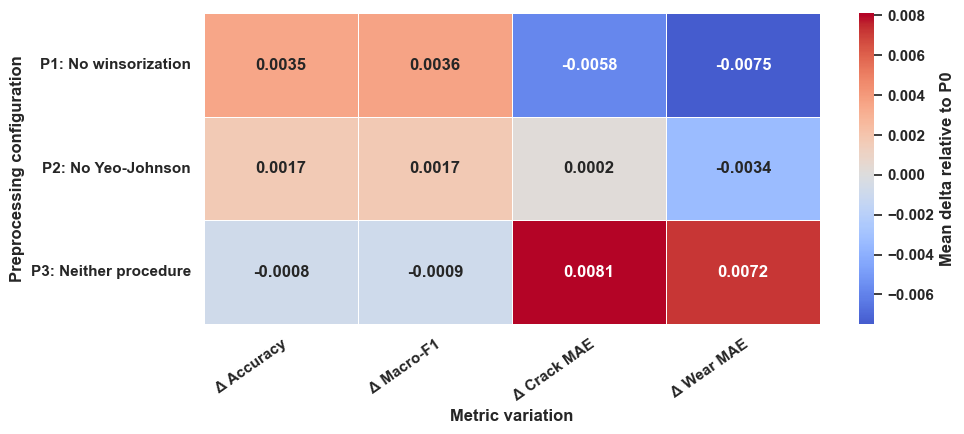


=== Exported sensitivity files ===
preprocessing_sensitivity_outputs\preprocessing_sensitivity_runs.csv
preprocessing_sensitivity_outputs\preprocessing_sensitivity_runs_with_deltas.csv
preprocessing_sensitivity_outputs\preprocessing_sensitivity_summary.csv
preprocessing_sensitivity_outputs\preprocessing_sensitivity_article_table.csv
preprocessing_sensitivity_outputs\preprocessing_sensitivity_delta_heatmap.png


In [30]:
# ============================================================
# SUMMARIZE AND EXPORT PREPROCESSING SENSITIVITY RESULTS
# ============================================================

_required_results = [
    "df_preprocessing_sensitivity_runs",
    "SENSITIVITY_OUTPUT_DIR",
    "SENSITIVITY_EXPERIMENTS",
]

assert all(
    variable in globals()
    for variable in _required_results
), (
    "Run the preprocessing sensitivity experiment cell first."
)


# ------------------------------------------------------------
# 1. Calculate paired deltas relative to P0
#
# Each variant is compared with P0 using the same random seed.
# ------------------------------------------------------------

metric_columns_sensitivity = [
    "test_accuracy",
    "test_macro_f1",
    "test_mae_crack",
    "test_mae_wear",
]

baseline_by_seed = (
    df_preprocessing_sensitivity_runs[
        df_preprocessing_sensitivity_runs[
            "experiment"
        ].astype(str) == "P0_full_pipeline"
    ][
        ["seed"] + metric_columns_sensitivity
    ]
    .copy()
)

baseline_by_seed = baseline_by_seed.rename(
    columns={
        metric: f"baseline_{metric}"
        for metric in metric_columns_sensitivity
    }
)

df_preprocessing_sensitivity_deltas = (
    df_preprocessing_sensitivity_runs
    .merge(
        baseline_by_seed,
        on="seed",
        how="left",
        validate="many_to_one",
    )
)

for metric in metric_columns_sensitivity:
    df_preprocessing_sensitivity_deltas[
        f"delta_{metric}"
    ] = (
        df_preprocessing_sensitivity_deltas[
            metric
        ]
        - df_preprocessing_sensitivity_deltas[
            f"baseline_{metric}"
        ]
    )


# ------------------------------------------------------------
# 2. Mean and standard deviation across seeds
# ------------------------------------------------------------

df_preprocessing_sensitivity_summary = (
    df_preprocessing_sensitivity_deltas
    .groupby(
        [
            "experiment",
            "description",
            "apply_yeo_johnson",
            "apply_winsorization",
        ],
        observed=True,
        sort=False,
    )
    .agg(
        accuracy_mean=(
            "test_accuracy",
            "mean",
        ),
        accuracy_std=(
            "test_accuracy",
            "std",
        ),
        macro_f1_mean=(
            "test_macro_f1",
            "mean",
        ),
        macro_f1_std=(
            "test_macro_f1",
            "std",
        ),
        mae_crack_mean=(
            "test_mae_crack",
            "mean",
        ),
        mae_crack_std=(
            "test_mae_crack",
            "std",
        ),
        mae_wear_mean=(
            "test_mae_wear",
            "mean",
        ),
        mae_wear_std=(
            "test_mae_wear",
            "std",
        ),
        delta_accuracy_mean=(
            "delta_test_accuracy",
            "mean",
        ),
        delta_accuracy_std=(
            "delta_test_accuracy",
            "std",
        ),
        delta_macro_f1_mean=(
            "delta_test_macro_f1",
            "mean",
        ),
        delta_macro_f1_std=(
            "delta_test_macro_f1",
            "std",
        ),
        delta_mae_crack_mean=(
            "delta_test_mae_crack",
            "mean",
        ),
        delta_mae_crack_std=(
            "delta_test_mae_crack",
            "std",
        ),
        delta_mae_wear_mean=(
            "delta_test_mae_wear",
            "mean",
        ),
        delta_mae_wear_std=(
            "delta_test_mae_wear",
            "std",
        ),
    )
    .reset_index()
)


experiment_order_sensitivity = [
    configuration["experiment"]
    for configuration in SENSITIVITY_EXPERIMENTS
]

df_preprocessing_sensitivity_summary[
    "experiment"
] = pd.Categorical(
    df_preprocessing_sensitivity_summary[
        "experiment"
    ],
    categories=experiment_order_sensitivity,
    ordered=True,
)

df_preprocessing_sensitivity_summary = (
    df_preprocessing_sensitivity_summary
    .sort_values("experiment")
    .reset_index(drop=True)
)

print(
    "\n=== Preprocessing sensitivity summary "
    "(mean ± standard deviation) ==="
)

display(
    df_preprocessing_sensitivity_summary[
        [
            "experiment",
            "accuracy_mean",
            "accuracy_std",
            "macro_f1_mean",
            "macro_f1_std",
            "mae_crack_mean",
            "mae_crack_std",
            "mae_wear_mean",
            "mae_wear_std",
            "delta_accuracy_mean",
            "delta_macro_f1_mean",
            "delta_mae_crack_mean",
            "delta_mae_wear_mean",
        ]
    ]
)


# ------------------------------------------------------------
# 3. Article-ready formatted table
# ------------------------------------------------------------

def format_mean_std(mean_value, std_value):
    if pd.isna(std_value):
        return f"{mean_value:.4f}"
    return f"{mean_value:.4f} ± {std_value:.4f}"


df_preprocessing_sensitivity_article = pd.DataFrame({
    "Experiment": (
        df_preprocessing_sensitivity_summary[
            "experiment"
        ].astype(str)
    ),
    "Accuracy": [
        format_mean_std(mean, std)
        for mean, std in zip(
            df_preprocessing_sensitivity_summary[
                "accuracy_mean"
            ],
            df_preprocessing_sensitivity_summary[
                "accuracy_std"
            ],
        )
    ],
    "Macro-F1": [
        format_mean_std(mean, std)
        for mean, std in zip(
            df_preprocessing_sensitivity_summary[
                "macro_f1_mean"
            ],
            df_preprocessing_sensitivity_summary[
                "macro_f1_std"
            ],
        )
    ],
    "Crack MAE": [
        format_mean_std(mean, std)
        for mean, std in zip(
            df_preprocessing_sensitivity_summary[
                "mae_crack_mean"
            ],
            df_preprocessing_sensitivity_summary[
                "mae_crack_std"
            ],
        )
    ],
    "Wear MAE": [
        format_mean_std(mean, std)
        for mean, std in zip(
            df_preprocessing_sensitivity_summary[
                "mae_wear_mean"
            ],
            df_preprocessing_sensitivity_summary[
                "mae_wear_std"
            ],
        )
    ],
})

print("\n=== Article-ready table ===")
display(df_preprocessing_sensitivity_article)


# ------------------------------------------------------------
# 4. Heatmap of mean paired deltas
# ------------------------------------------------------------

delta_columns_heatmap = [
    "delta_accuracy_mean",
    "delta_macro_f1_mean",
    "delta_mae_crack_mean",
    "delta_mae_wear_mean",
]

heatmap_labels = {
    "delta_accuracy_mean": "Δ Accuracy",
    "delta_macro_f1_mean": "Δ Macro-F1",
    "delta_mae_crack_mean": "Δ Crack MAE",
    "delta_mae_wear_mean": "Δ Wear MAE",
}

experiment_labels_heatmap = {
    "P1_no_winsorization": "P1: No winsorization",
    "P2_no_yeo_johnson": "P2: No Yeo-Johnson",
    "P3_no_winsorization_no_yeo_johnson": (
        "P3: Neither procedure"
    ),
}

df_heatmap_sensitivity = (
    df_preprocessing_sensitivity_summary[
        df_preprocessing_sensitivity_summary[
            "experiment"
        ].astype(str) != "P0_full_pipeline"
    ]
    .copy()
)

df_heatmap_sensitivity[
    "experiment_label"
] = (
    df_heatmap_sensitivity[
        "experiment"
    ]
    .astype(str)
    .map(experiment_labels_heatmap)
)

heatmap_data_sensitivity = (
    df_heatmap_sensitivity
    .set_index("experiment_label")[
        delta_columns_heatmap
    ]
    .rename(columns=heatmap_labels)
)

fig_sensitivity, ax_sensitivity = plt.subplots(
    figsize=(10, 4.5)
)

sns.heatmap(
    heatmap_data_sensitivity,
    annot=True,
    fmt=".4f",
    cmap="coolwarm",
    center=0.0,
    linewidths=0.5,
    cbar_kws={
        "label": "Mean delta relative to P0"
    },
    ax=ax_sensitivity,
)

ax_sensitivity.set_title("")
ax_sensitivity.set_xlabel(
    "Metric variation",
    fontsize=12,
    fontweight="bold",
)
ax_sensitivity.set_ylabel(
    "Preprocessing configuration",
    fontsize=12,
    fontweight="bold",
)

ax_sensitivity.set_xticklabels(
    ax_sensitivity.get_xticklabels(),
    rotation=35,
    ha="right",
    rotation_mode="anchor",
)

for label in ax_sensitivity.get_xticklabels():
    label.set_fontweight("bold")

for label in ax_sensitivity.get_yticklabels():
    label.set_fontweight("bold")

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 5. Export results
# ------------------------------------------------------------

runs_path_sensitivity = (
    SENSITIVITY_OUTPUT_DIR
    / "preprocessing_sensitivity_runs.csv"
)

deltas_path_sensitivity = (
    SENSITIVITY_OUTPUT_DIR
    / "preprocessing_sensitivity_runs_with_deltas.csv"
)

summary_path_sensitivity = (
    SENSITIVITY_OUTPUT_DIR
    / "preprocessing_sensitivity_summary.csv"
)

article_table_path_sensitivity = (
    SENSITIVITY_OUTPUT_DIR
    / "preprocessing_sensitivity_article_table.csv"
)

heatmap_path_sensitivity = (
    SENSITIVITY_OUTPUT_DIR
    / "preprocessing_sensitivity_delta_heatmap.png"
)

df_preprocessing_sensitivity_runs.to_csv(
    runs_path_sensitivity,
    index=False,
)

df_preprocessing_sensitivity_deltas.to_csv(
    deltas_path_sensitivity,
    index=False,
)

df_preprocessing_sensitivity_summary.to_csv(
    summary_path_sensitivity,
    index=False,
)

df_preprocessing_sensitivity_article.to_csv(
    article_table_path_sensitivity,
    index=False,
)

fig_sensitivity.savefig(
    heatmap_path_sensitivity,
    dpi=300,
    bbox_inches="tight",
)

print("\n=== Exported sensitivity files ===")
print(runs_path_sensitivity)
print(deltas_path_sensitivity)
print(summary_path_sensitivity)
print(article_table_path_sensitivity)
print(heatmap_path_sensitivity)

----------------------------------------------
Statistical comparison: MTL vs strongest single-task MLP
----------------------------------------------
----------------------------------------------

In [34]:
# ============================================================
# STATISTICAL COMPARISON: MTL vs STRONGEST SINGLE-TASK MLP
# Setup, paired MTL runs, and optimized MLP configurations
# ============================================================

import json
import warnings
import joblib
from pathlib import Path

import numpy as np
import pandas as pd

from sklearn.neural_network import MLPClassifier, MLPRegressor
from sklearn.exceptions import ConvergenceWarning
from sklearn.metrics import accuracy_score, f1_score, mean_absolute_error

# ------------------------------------------------------------
# 1. Required final-pipeline variables
# ------------------------------------------------------------

_required_statistical = [
    "X_tr_final_pipeline",
    "X_te_final_pipeline",
    "y_cls_tr",
    "y_cls_te",
    "y_crack_tr",
    "y_crack_te",
    "y_wear_tr",
    "y_wear_te",
    "sw_crack_tr",
    "sw_crack_te",
    "sw_wear_tr",
    "sw_wear_te",
]

missing_statistical = [
    variable
    for variable in _required_statistical
    if variable not in globals()
]

assert not missing_statistical, (
    "Missing variables for the statistical comparison: "
    f"{missing_statistical}. Run the train/test split, "
    "preprocessing, feature selection, RobustScaler, and "
    "FINAL 10-FEATURE PIPELINE SNAPSHOT cells first."
)

X_train_stat = np.asarray(
    X_tr_final_pipeline,
    dtype=np.float64,
).copy()

X_test_stat = np.asarray(
    X_te_final_pipeline,
    dtype=np.float64,
).copy()

assert X_train_stat.shape[1] == 10
assert X_test_stat.shape[1] == 10

crack_train_mask_stat = np.asarray(
    sw_crack_tr
).astype(bool).ravel()

crack_test_mask_stat = np.asarray(
    sw_crack_te
).astype(bool).ravel()

wear_train_mask_stat = np.asarray(
    sw_wear_tr
).astype(bool).ravel()

wear_test_mask_stat = np.asarray(
    sw_wear_te
).astype(bool).ravel()

# ------------------------------------------------------------
# 2. Recover the 10 P0 MTL runs already produced by the
#    preprocessing sensitivity analysis
# ------------------------------------------------------------

SENSITIVITY_RUNS_CSV = Path(
    "preprocessing_sensitivity_outputs"
) / "preprocessing_sensitivity_runs.csv"

if "df_preprocessing_sensitivity_runs" in globals():
    df_mtl_seed_runs = (
        df_preprocessing_sensitivity_runs.copy()
    )
elif SENSITIVITY_RUNS_CSV.exists():
    df_mtl_seed_runs = pd.read_csv(
        SENSITIVITY_RUNS_CSV
    )
else:
    raise FileNotFoundError(
        "The P0 repeated MTL results were not found. "
        "Run the preprocessing sensitivity experiment first, "
        f"or place its CSV at {SENSITIVITY_RUNS_CSV}."
    )

df_mtl_seed_runs["experiment"] = (
    df_mtl_seed_runs["experiment"].astype(str)
)

df_mtl_seed_runs = (
    df_mtl_seed_runs[
        df_mtl_seed_runs["experiment"]
        == "P0_full_pipeline"
    ][
        [
            "seed",
            "test_accuracy",
            "test_macro_f1",
            "test_mae_crack",
            "test_mae_wear",
        ]
    ]
    .copy()
    .sort_values("seed")
    .reset_index(drop=True)
)

df_mtl_seed_runs = df_mtl_seed_runs.rename(
    columns={
        "test_accuracy": "mtl_accuracy",
        "test_macro_f1": "mtl_macro_f1",
        "test_mae_crack": "mtl_mae_crack",
        "test_mae_wear": "mtl_mae_wear",
    }
)

STATISTICAL_SEEDS = (
    df_mtl_seed_runs["seed"]
    .astype(int)
    .tolist()
)

assert len(STATISTICAL_SEEDS) == 10, (
    "Exactly 10 P0 MTL runs were expected, but "
    f"{len(STATISTICAL_SEEDS)} were found."
)

assert len(set(STATISTICAL_SEEDS)) == 10, (
    "The P0 MTL seed values must be unique."
)

print("[Statistical comparison] Seeds:")
print(STATISTICAL_SEEDS)

# ------------------------------------------------------------
# 3. Load the exact optimized MLP configurations previously
#    used for the article's single-task baselines
#
# Expected files generated by the original GridSearch cells:
#   cls_grid_models/best_MLP_cls.pkl
#   crack_reg_grid_models/best_MLP_crack_reg.pkl
#   wear_reg_grid_models/best_MLP_wear_reg.pkl
#
# Do not re-tune inside the 10-run experiment.
# ------------------------------------------------------------

BASELINE_MODEL_PATHS = {
    "classification": Path(
        "cls_grid_models/best_MLP_cls.pkl"
    ),
    "crack": Path(
        "crack_reg_grid_models/"
        "best_MLP_crack_reg.pkl"
    ),
    "wear": Path(
        "wear_reg_grid_models/"
        "best_MLP_wear_reg.pkl"
    ),
}

def resolve_saved_model_path(expected_path):
    """
    Use the expected path first. If it is not found, search
    recursively by filename from the notebook directory.
    """
    expected_path = Path(expected_path)

    if expected_path.exists():
        return expected_path

    matches = list(
        Path(".").rglob(expected_path.name)
    )

    if len(matches) == 1:
        return matches[0]

    if len(matches) > 1:
        raise RuntimeError(
            f"Multiple files named {expected_path.name} "
            f"were found: {matches}. Set the exact path in "
            "BASELINE_MODEL_PATHS."
        )

    raise FileNotFoundError(
        f"Could not find {expected_path}. Copy the optimized "
        "MLP model produced by the original GridSearch cell "
        "to this project, or update BASELINE_MODEL_PATHS."
    )

def extract_mlp_estimator(
    saved_path,
    expected_type,
):
    """
    Load a saved sklearn Pipeline or estimator and return
    the fitted MLP step.
    """
    loaded_object = joblib.load(saved_path)

    if hasattr(loaded_object, "named_steps"):
        matching_steps = [
            estimator
            for estimator in (
                loaded_object.named_steps.values()
            )
            if isinstance(estimator, expected_type)
        ]

        if len(matching_steps) != 1:
            raise TypeError(
                f"{saved_path} does not contain exactly one "
                f"{expected_type.__name__} step."
            )

        estimator = matching_steps[0]
    else:
        estimator = loaded_object

    if not isinstance(estimator, expected_type):
        raise TypeError(
            f"{saved_path} contains "
            f"{type(estimator).__name__}, not "
            f"{expected_type.__name__}."
        )

    return estimator

resolved_baseline_paths = {
    task: resolve_saved_model_path(path)
    for task, path in BASELINE_MODEL_PATHS.items()
}

saved_mlp_cls = extract_mlp_estimator(
    resolved_baseline_paths["classification"],
    MLPClassifier,
)

saved_mlp_crack = extract_mlp_estimator(
    resolved_baseline_paths["crack"],
    MLPRegressor,
)

saved_mlp_wear = extract_mlp_estimator(
    resolved_baseline_paths["wear"],
    MLPRegressor,
)

MLP_CLASSIFICATION_PARAMS = (
    saved_mlp_cls.get_params(deep=False)
)

MLP_CRACK_PARAMS = (
    saved_mlp_crack.get_params(deep=False)
)

MLP_WEAR_PARAMS = (
    saved_mlp_wear.get_params(deep=False)
)

print("\n=== Loaded optimized MLP configurations ===")

for task_name, params in [
    (
        "Classification",
        MLP_CLASSIFICATION_PARAMS,
    ),
    (
        "Crack regression",
        MLP_CRACK_PARAMS,
    ),
    (
        "Wear regression",
        MLP_WEAR_PARAMS,
    ),
]:
    print(f"\n{task_name}:")
    for key in [
        "hidden_layer_sizes",
        "activation",
        "solver",
        "alpha",
        "learning_rate",
        "max_iter",
    ]:
        print(f"  {key}: {params.get(key)}")

STATISTICAL_OUTPUT_DIR = Path(
    "statistical_comparison_outputs"
)

STATISTICAL_OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

with open(
    STATISTICAL_OUTPUT_DIR
    / "optimized_mlp_parameters.json",
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        {
            "classification": {
                key: value
                for key, value
                in MLP_CLASSIFICATION_PARAMS.items()
                if isinstance(
                    value,
                    (
                        str,
                        int,
                        float,
                        bool,
                        type(None),
                        tuple,
                        list,
                    ),
                )
            },
            "crack": {
                key: value
                for key, value
                in MLP_CRACK_PARAMS.items()
                if isinstance(
                    value,
                    (
                        str,
                        int,
                        float,
                        bool,
                        type(None),
                        tuple,
                        list,
                    ),
                )
            },
            "wear": {
                key: value
                for key, value
                in MLP_WEAR_PARAMS.items()
                if isinstance(
                    value,
                    (
                        str,
                        int,
                        float,
                        bool,
                        type(None),
                        tuple,
                        list,
                    ),
                )
            },
        },
        file,
        indent=2,
    )


[Statistical comparison] Seeds:
[16, 42, 123, 145, 152, 521, 1102, 2111, 27182, 31415]

=== Loaded optimized MLP configurations ===

Classification:
  hidden_layer_sizes: (50, 100)
  activation: tanh
  solver: adam
  alpha: 0.0001
  learning_rate: constant
  max_iter: 300

Crack regression:
  hidden_layer_sizes: (50, 100)
  activation: relu
  solver: adam
  alpha: 0.01
  learning_rate: constant
  max_iter: 300

Wear regression:
  hidden_layer_sizes: (50, 100)
  activation: relu
  solver: adam
  alpha: 0.01
  learning_rate: constant
  max_iter: 300


In [35]:
# ============================================================
# RUN 10 REPEATED SINGLE-TASK MLP EXPERIMENTS
# Same final split, preprocessing, features, and seeds as P0
# ============================================================

mlp_repeated_results = []

for run_index, seed in enumerate(
    STATISTICAL_SEEDS,
    start=1,
):
    print(
        f"\n=== MLP repeated run "
        f"{run_index}/{len(STATISTICAL_SEEDS)} "
        f"| seed={seed} ==="
    )

    np.random.seed(seed)

    # --------------------------------------------------------
    # 1. Classification MLP
    # --------------------------------------------------------

    cls_params_seed = (
        MLP_CLASSIFICATION_PARAMS.copy()
    )
    cls_params_seed["random_state"] = int(seed)

    mlp_classifier_seed = MLPClassifier(
        **cls_params_seed
    )

    with warnings.catch_warnings(record=True):
        warnings.simplefilter(
            "always",
            ConvergenceWarning,
        )
        mlp_classifier_seed.fit(
            X_train_stat,
            y_cls_tr,
        )

    mlp_cls_pred = mlp_classifier_seed.predict(
        X_test_stat
    )

    mlp_accuracy = accuracy_score(
        y_cls_te,
        mlp_cls_pred,
    )

    mlp_macro_f1 = f1_score(
        y_cls_te,
        mlp_cls_pred,
        average="macro",
        zero_division=0,
    )

    # --------------------------------------------------------
    # 2. Crack-localization MLP
    # --------------------------------------------------------

    crack_params_seed = (
        MLP_CRACK_PARAMS.copy()
    )
    crack_params_seed["random_state"] = int(seed)

    mlp_crack_seed = MLPRegressor(
        **crack_params_seed
    )

    with warnings.catch_warnings(record=True):
        warnings.simplefilter(
            "always",
            ConvergenceWarning,
        )
        mlp_crack_seed.fit(
            X_train_stat[crack_train_mask_stat],
            np.asarray(y_crack_tr)[
                crack_train_mask_stat
            ],
        )

    mlp_crack_pred = mlp_crack_seed.predict(
        X_test_stat[crack_test_mask_stat]
    )

    mlp_mae_crack = mean_absolute_error(
        np.asarray(y_crack_te)[
            crack_test_mask_stat
        ],
        mlp_crack_pred,
    )

    # --------------------------------------------------------
    # 3. Wear-localization MLP
    # --------------------------------------------------------

    wear_params_seed = (
        MLP_WEAR_PARAMS.copy()
    )
    wear_params_seed["random_state"] = int(seed)

    mlp_wear_seed = MLPRegressor(
        **wear_params_seed
    )

    with warnings.catch_warnings(record=True):
        warnings.simplefilter(
            "always",
            ConvergenceWarning,
        )
        mlp_wear_seed.fit(
            X_train_stat[wear_train_mask_stat],
            np.asarray(y_wear_tr)[
                wear_train_mask_stat
            ],
        )

    mlp_wear_pred = mlp_wear_seed.predict(
        X_test_stat[wear_test_mask_stat]
    )

    mlp_mae_wear = mean_absolute_error(
        np.asarray(y_wear_te)[
            wear_test_mask_stat
        ],
        mlp_wear_pred,
    )

    result_seed = {
        "seed": int(seed),
        "mlp_accuracy": float(mlp_accuracy),
        "mlp_macro_f1": float(mlp_macro_f1),
        "mlp_mae_crack": float(
            mlp_mae_crack
        ),
        "mlp_mae_wear": float(
            mlp_mae_wear
        ),
    }

    mlp_repeated_results.append(result_seed)

    print(
        f"MLP ACC={mlp_accuracy:.4f} | "
        f"Macro-F1={mlp_macro_f1:.4f} | "
        f"MAE crack={mlp_mae_crack:.4f} cm | "
        f"MAE wear={mlp_mae_wear:.4f} cm"
    )

    del mlp_classifier_seed
    del mlp_crack_seed
    del mlp_wear_seed


df_mlp_seed_runs = pd.DataFrame(
    mlp_repeated_results
)

df_paired_mtl_mlp = (
    df_mtl_seed_runs
    .merge(
        df_mlp_seed_runs,
        on="seed",
        how="inner",
        validate="one_to_one",
    )
    .sort_values("seed")
    .reset_index(drop=True)
)

assert len(df_paired_mtl_mlp) == 10, (
    "The paired table must contain 10 seeds."
)

# Positive gain always means that MTL performed better.
df_paired_mtl_mlp[
    "gain_accuracy"
] = (
    df_paired_mtl_mlp["mtl_accuracy"]
    - df_paired_mtl_mlp["mlp_accuracy"]
)

df_paired_mtl_mlp[
    "gain_macro_f1"
] = (
    df_paired_mtl_mlp["mtl_macro_f1"]
    - df_paired_mtl_mlp["mlp_macro_f1"]
)

df_paired_mtl_mlp[
    "gain_mae_crack"
] = (
    df_paired_mtl_mlp["mlp_mae_crack"]
    - df_paired_mtl_mlp["mtl_mae_crack"]
)

df_paired_mtl_mlp[
    "gain_mae_wear"
] = (
    df_paired_mtl_mlp["mlp_mae_wear"]
    - df_paired_mtl_mlp["mtl_mae_wear"]
)

print("\n=== Paired MTL vs MLP runs ===")
display(df_paired_mtl_mlp)

PAIRED_RUNS_PATH = (
    STATISTICAL_OUTPUT_DIR
    / "paired_runs_mtl_vs_mlp.csv"
)

df_paired_mtl_mlp.to_csv(
    PAIRED_RUNS_PATH,
    index=False,
)

print(
    f"\n[Exported] {PAIRED_RUNS_PATH}"
)

# ------------------------------------------------------------
# Reproduction check for the original seed-42 MLP results
# reported in the manuscript tables
# ------------------------------------------------------------

seed_42_rows = df_paired_mtl_mlp[
    df_paired_mtl_mlp["seed"] == 42
]

if not seed_42_rows.empty:
    seed_42_result = seed_42_rows.iloc[0]

    original_reference = {
        "mlp_accuracy": 0.9597,
        "mlp_mae_crack": 0.2479,
        "mlp_mae_wear": 0.2470,
    }

    print(
        "\n=== Seed-42 reproduction check "
        "against manuscript tables ==="
    )

    for metric, expected_value in (
        original_reference.items()
    ):
        observed_value = float(
            seed_42_result[metric]
        )

        difference = (
            observed_value - expected_value
        )

        print(
            f"{metric}: observed={observed_value:.4f} | "
            f"reported={expected_value:.4f} | "
            f"difference={difference:+.4f}"
        )

        if abs(difference) > 0.01:
            print(
                "  [Warning] Difference exceeds 0.01. "
                "Verify that the loaded saved model and "
                "the current final pipeline match those "
                "used for the article."
            )



=== MLP repeated run 1/10 | seed=16 ===
MLP ACC=0.9611 | Macro-F1=0.9611 | MAE crack=0.2452 cm | MAE wear=0.2484 cm

=== MLP repeated run 2/10 | seed=42 ===
MLP ACC=0.9597 | Macro-F1=0.9598 | MAE crack=0.2469 cm | MAE wear=0.2462 cm

=== MLP repeated run 3/10 | seed=123 ===
MLP ACC=0.9597 | Macro-F1=0.9596 | MAE crack=0.2429 cm | MAE wear=0.2364 cm

=== MLP repeated run 4/10 | seed=145 ===
MLP ACC=0.9597 | Macro-F1=0.9595 | MAE crack=0.2237 cm | MAE wear=0.2287 cm

=== MLP repeated run 5/10 | seed=152 ===
MLP ACC=0.9528 | Macro-F1=0.9525 | MAE crack=0.2187 cm | MAE wear=0.2519 cm

=== MLP repeated run 6/10 | seed=521 ===
MLP ACC=0.9625 | Macro-F1=0.9625 | MAE crack=0.2093 cm | MAE wear=0.2186 cm

=== MLP repeated run 7/10 | seed=1102 ===
MLP ACC=0.9681 | Macro-F1=0.9679 | MAE crack=0.2254 cm | MAE wear=0.2453 cm

=== MLP repeated run 8/10 | seed=2111 ===
MLP ACC=0.9486 | Macro-F1=0.9484 | MAE crack=0.2199 cm | MAE wear=0.2567 cm

=== MLP repeated run 9/10 | seed=27182 ===
MLP ACC=0.95

,seed,mtl_accuracy,mtl_macro_f1,mtl_mae_crack,mtl_mae_wear,mlp_accuracy,mlp_macro_f1,mlp_mae_crack,mlp_mae_wear,gain_accuracy,gain_macro_f1,gain_mae_crack,gain_mae_wear
0,16,0.955556,0.955117,0.114540,0.160322,0.961111,0.961099,0.245236,0.248440,-0.005556,-0.005982,0.130696,0.088118
1,42,0.962500,0.962046,0.119979,0.191627,0.959722,0.959766,0.246940,0.246236,0.002778,0.002279,0.126961,0.054609
2,123,0.963889,0.963701,0.120035,0.183834,0.959722,0.959646,0.242880,0.236353,0.004167,0.004055,0.122845,0.052518
3,145,0.963889,0.963573,0.110499,0.159062,0.959722,0.959519,0.223672,0.228680,0.004167,0.004054,0.113172,0.069618
4,152,0.970833,0.970619,0.120106,0.151208,0.952778,0.952524,0.218726,0.251907,0.018056,0.018094,0.098620,0.100699
5,521,0.965278,0.964955,0.123028,0.159362,0.962500,0.962460,0.209273,0.218600,0.002778,0.002495,0.086245,0.059239
6,1102,0.976389,0.976189,0.120888,0.171916,0.968056,0.967880,0.225417,0.245294,0.008333,0.008309,0.104529,0.073379
7,2111,0.961111,0.960593,0.125291,0.162861,0.948611,0.948406,0.219863,0.256698,0.012500,0.012188,0.094572,0.093837
8,27182,0.963889,0.963764,0.121731,0.159940,0.956944,0.956921,0.203238,0.240054,0.006944,0.006843,0.081507,0.080114
9,31415,0.966667,0.966425,0.129228,0.179435,0.959722,0.959566,0.233934,0.255738,0.006944,0.006859,0.104705,0.076302



[Exported] statistical_comparison_outputs\paired_runs_mtl_vs_mlp.csv

=== Seed-42 reproduction check against manuscript tables ===
mlp_accuracy: observed=0.9597 | reported=0.9597 | difference=+0.0000
mlp_mae_crack: observed=0.2469 | reported=0.2479 | difference=-0.0010
mlp_mae_wear: observed=0.2462 | reported=0.2470 | difference=-0.0008


In [36]:
# ============================================================
# WILCOXON SIGNED-RANK TESTS, BOOTSTRAP 95% CIs,
# HOLM CORRECTION, AND EFFECT SIZES
# ============================================================

from scipy.stats import rankdata, wilcoxon

# ------------------------------------------------------------
# 1. Statistical helper functions
# ------------------------------------------------------------

def paired_bootstrap_mean_ci(
    paired_gain,
    confidence=0.95,
    n_bootstrap=20000,
    random_state=20260720,
):
    """
    Percentile bootstrap confidence interval for the mean
    paired performance gain.
    """
    paired_gain = np.asarray(
        paired_gain,
        dtype=float,
    )

    paired_gain = paired_gain[
        np.isfinite(paired_gain)
    ]

    if paired_gain.size == 0:
        return np.nan, np.nan

    rng = np.random.default_rng(
        random_state
    )

    bootstrap_indices = rng.integers(
        low=0,
        high=paired_gain.size,
        size=(
            n_bootstrap,
            paired_gain.size,
        ),
    )

    bootstrap_means = paired_gain[
        bootstrap_indices
    ].mean(axis=1)

    alpha = 1.0 - confidence

    lower = np.quantile(
        bootstrap_means,
        alpha / 2.0,
    )

    upper = np.quantile(
        bootstrap_means,
        1.0 - alpha / 2.0,
    )

    return float(lower), float(upper)


def paired_rank_biserial(paired_gain):
    """
    Rank-biserial correlation for paired differences.
    Positive values favour MTL.
    """
    paired_gain = np.asarray(
        paired_gain,
        dtype=float,
    )

    paired_gain = paired_gain[
        np.isfinite(paired_gain)
    ]

    nonzero = paired_gain != 0.0
    paired_gain = paired_gain[nonzero]

    if paired_gain.size == 0:
        return 0.0

    ranks = rankdata(
        np.abs(paired_gain),
        method="average",
    )

    positive_rank_sum = ranks[
        paired_gain > 0
    ].sum()

    negative_rank_sum = ranks[
        paired_gain < 0
    ].sum()

    denominator = (
        positive_rank_sum
        + negative_rank_sum
    )

    if denominator == 0:
        return 0.0

    return float(
        (
            positive_rank_sum
            - negative_rank_sum
        )
        / denominator
    )


def wilcoxon_two_sided(paired_gain):
    """
    Two-sided Wilcoxon signed-rank test with a compatibility
    fallback for older SciPy versions.
    """
    paired_gain = np.asarray(
        paired_gain,
        dtype=float,
    )

    paired_gain = paired_gain[
        np.isfinite(paired_gain)
    ]

    if paired_gain.size == 0:
        return np.nan, np.nan

    if np.allclose(paired_gain, 0.0):
        return 0.0, 1.0

    try:
        result = wilcoxon(
            paired_gain,
            zero_method="wilcox",
            correction=False,
            alternative="two-sided",
            method="auto",
        )
    except TypeError:
        result = wilcoxon(
            paired_gain,
            zero_method="wilcox",
            correction=False,
            alternative="two-sided",
        )

    return (
        float(result.statistic),
        float(result.pvalue),
    )


def holm_adjust(p_values):
    """
    Holm family-wise error-rate correction.
    """
    p_values = np.asarray(
        p_values,
        dtype=float,
    )

    number_tests = p_values.size
    order = np.argsort(p_values)
    adjusted = np.empty(
        number_tests,
        dtype=float,
    )

    previous_adjusted = 0.0

    for rank_index, original_index in enumerate(
        order
    ):
        multiplier = (
            number_tests - rank_index
        )

        candidate = min(
            1.0,
            multiplier
            * p_values[original_index],
        )

        previous_adjusted = max(
            previous_adjusted,
            candidate,
        )

        adjusted[original_index] = (
            previous_adjusted
        )

    return adjusted


def format_mean_std_stat(mean_value, std_value):
    return (
        f"{mean_value:.4f} ± "
        f"{std_value:.4f}"
    )


def format_ci_stat(lower, upper):
    return (
        f"[{lower:.4f}, {upper:.4f}]"
    )


# ------------------------------------------------------------
# 2. Perform four paired comparisons
#
# Positive gain always favours MTL:
#   classification: MTL - MLP
#   regression MAE: MLP - MTL
# ------------------------------------------------------------

comparison_definitions = [
    {
        "metric": "Accuracy",
        "mtl_column": "mtl_accuracy",
        "mlp_column": "mlp_accuracy",
        "gain_column": "gain_accuracy",
        "unit": "",
    },
    {
        "metric": "Macro-F1",
        "mtl_column": "mtl_macro_f1",
        "mlp_column": "mlp_macro_f1",
        "gain_column": "gain_macro_f1",
        "unit": "",
    },
    {
        "metric": "Crack MAE",
        "mtl_column": "mtl_mae_crack",
        "mlp_column": "mlp_mae_crack",
        "gain_column": "gain_mae_crack",
        "unit": "cm",
    },
    {
        "metric": "Wear MAE",
        "mtl_column": "mtl_mae_wear",
        "mlp_column": "mlp_mae_wear",
        "gain_column": "gain_mae_wear",
        "unit": "cm",
    },
]

statistical_rows = []

for comparison_index, definition in enumerate(
    comparison_definitions
):
    mtl_values = (
        df_paired_mtl_mlp[
            definition["mtl_column"]
        ]
        .to_numpy(dtype=float)
    )

    mlp_values = (
        df_paired_mtl_mlp[
            definition["mlp_column"]
        ]
        .to_numpy(dtype=float)
    )

    paired_gain = (
        df_paired_mtl_mlp[
            definition["gain_column"]
        ]
        .to_numpy(dtype=float)
    )

    ci_lower, ci_upper = (
        paired_bootstrap_mean_ci(
            paired_gain,
            random_state=(
                20260720
                + comparison_index
            ),
        )
    )

    wilcoxon_statistic, raw_p_value = (
        wilcoxon_two_sided(
            paired_gain
        )
    )

    statistical_rows.append({
        "metric": definition["metric"],
        "unit": definition["unit"],
        "n_pairs": int(
            np.isfinite(paired_gain).sum()
        ),
        "mtl_mean": float(
            np.mean(mtl_values)
        ),
        "mtl_std": float(
            np.std(
                mtl_values,
                ddof=1,
            )
        ),
        "mlp_mean": float(
            np.mean(mlp_values)
        ),
        "mlp_std": float(
            np.std(
                mlp_values,
                ddof=1,
            )
        ),
        "mean_paired_gain": float(
            np.mean(paired_gain)
        ),
        "gain_std": float(
            np.std(
                paired_gain,
                ddof=1,
            )
        ),
        "ci95_lower": ci_lower,
        "ci95_upper": ci_upper,
        "wilcoxon_statistic": (
            wilcoxon_statistic
        ),
        "p_value_raw": raw_p_value,
        "rank_biserial": (
            paired_rank_biserial(
                paired_gain
            )
        ),
        "mtl_better_seeds": int(
            np.sum(paired_gain > 0)
        ),
        "ties": int(
            np.sum(
                np.isclose(
                    paired_gain,
                    0.0,
                )
            )
        ),
    })

df_statistical_comparison = pd.DataFrame(
    statistical_rows
)

df_statistical_comparison[
    "p_value_holm"
] = holm_adjust(
    df_statistical_comparison[
        "p_value_raw"
    ].to_numpy(dtype=float)
)

df_statistical_comparison[
    "significant_holm_0.05"
] = (
    df_statistical_comparison[
        "p_value_holm"
    ] < 0.05
)

print(
    "\n=== Statistical comparison: "
    "MTL vs strongest single-task MLP ==="
)

display(df_statistical_comparison)


# ------------------------------------------------------------
# 3. Article-ready table
# ------------------------------------------------------------

df_statistical_article = pd.DataFrame({
    "Metric": (
        df_statistical_comparison[
            "metric"
        ]
    ),
    "MTL mean ± SD": [
        format_mean_std_stat(mean, std)
        for mean, std in zip(
            df_statistical_comparison[
                "mtl_mean"
            ],
            df_statistical_comparison[
                "mtl_std"
            ],
        )
    ],
    "MLP mean ± SD": [
        format_mean_std_stat(mean, std)
        for mean, std in zip(
            df_statistical_comparison[
                "mlp_mean"
            ],
            df_statistical_comparison[
                "mlp_std"
            ],
        )
    ],
    "Mean paired gain": (
        df_statistical_comparison[
            "mean_paired_gain"
        ].map(
            lambda value: f"{value:.4f}"
        )
    ),
    "95% CI of gain": [
        format_ci_stat(lower, upper)
        for lower, upper in zip(
            df_statistical_comparison[
                "ci95_lower"
            ],
            df_statistical_comparison[
                "ci95_upper"
            ],
        )
    ],
    "Holm-adjusted p": (
        df_statistical_comparison[
            "p_value_holm"
        ].map(
            lambda value: f"{value:.4f}"
        )
    ),
    "Rank-biserial effect": (
        df_statistical_comparison[
            "rank_biserial"
        ].map(
            lambda value: f"{value:.3f}"
        )
    ),
    "MTL better seeds": [
        (
            f"{better}/"
            f"{n_pairs}"
        )
        for better, n_pairs in zip(
            df_statistical_comparison[
                "mtl_better_seeds"
            ],
            df_statistical_comparison[
                "n_pairs"
            ],
        )
    ],
})

print("\n=== Article-ready statistical table ===")
display(df_statistical_article)


# ------------------------------------------------------------
# 4. Export
# ------------------------------------------------------------

STATISTICAL_SUMMARY_PATH = (
    STATISTICAL_OUTPUT_DIR
    / "statistical_comparison_summary.csv"
)

STATISTICAL_ARTICLE_PATH = (
    STATISTICAL_OUTPUT_DIR
    / "statistical_comparison_article_table.csv"
)

df_statistical_comparison.to_csv(
    STATISTICAL_SUMMARY_PATH,
    index=False,
)

df_statistical_article.to_csv(
    STATISTICAL_ARTICLE_PATH,
    index=False,
)

print("\n=== Exported statistical files ===")
print(PAIRED_RUNS_PATH)
print(STATISTICAL_SUMMARY_PATH)
print(STATISTICAL_ARTICLE_PATH)



=== Statistical comparison: MTL vs strongest single-task MLP ===


,metric,unit,n_pairs,mtl_mean,mtl_std,mlp_mean,mlp_std,mean_paired_gain,gain_std,ci95_lower,ci95_upper,wilcoxon_statistic,p_value_raw,rank_biserial,mtl_better_seeds,ties,p_value_holm,significant_holm_0.05
0,Accuracy,,10,0.965000,0.005586,0.958889,0.005287,0.006111,0.006287,0.002497,0.009861,5.0,0.021484,0.818182,9,0,0.039062,True
1,Macro-F1,,10,0.964698,0.005666,0.958779,0.005321,0.005919,0.006399,0.002163,0.009743,5.0,0.019531,0.818182,9,0,0.039062,True
2,Crack MAE,cm,10,0.120533,0.005200,0.226918,0.015063,0.106385,0.016872,0.096493,0.116311,0.0,0.001953,1.000000,10,0,0.007812,True
3,Wear MAE,cm,10,0.167957,0.013089,0.242800,0.012145,0.074843,0.016385,0.065260,0.084584,0.0,0.001953,1.000000,10,0,0.007812,True



=== Article-ready statistical table ===


,Metric,MTL mean ± SD,MLP mean ± SD,Mean paired gain,95% CI of gain,Holm-adjusted p,Rank-biserial effect,MTL better seeds
0,Accuracy,0.9650 ± 0.0056,0.9589 ± 0.0053,0.0061,"[0.0025, 0.0099]",0.0391,0.818,9/10
1,Macro-F1,0.9647 ± 0.0057,0.9588 ± 0.0053,0.0059,"[0.0022, 0.0097]",0.0391,0.818,9/10
2,Crack MAE,0.1205 ± 0.0052,0.2269 ± 0.0151,0.1064,"[0.0965, 0.1163]",0.0078,1.000,10/10
3,Wear MAE,0.1680 ± 0.0131,0.2428 ± 0.0121,0.0748,"[0.0653, 0.0846]",0.0078,1.000,10/10



=== Exported statistical files ===
statistical_comparison_outputs\paired_runs_mtl_vs_mlp.csv
statistical_comparison_outputs\statistical_comparison_summary.csv
statistical_comparison_outputs\statistical_comparison_article_table.csv


----------------------------------------------
Ablation Analysis (Pre-Selection 16 Features)
----------------------------------------------
----------------------------------------------


In [37]:
# ============================================================
# Ablation Analysis Helpers (pre-ANOVA / pre-manual-drop)
# ============================================================
import json
import os
import random
import time
from pathlib import Path

import keras_tuner as kt
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from IPython.display import display
from sklearn.metrics import accuracy_score, f1_score, mean_absolute_error
from sklearn.preprocessing import RobustScaler
from tensorflow.keras.callbacks import EarlyStopping

_required_ablation = [
    "X_tr_preselect", "X_te_preselect", "feature_names_preselect",
    "y_cls_tr_preselect", "y_cls_te_preselect",
    "y_crack_tr_preselect", "y_crack_te_preselect",
    "y_wear_tr_preselect", "y_wear_te_preselect",
    "sw_crack_tr_preselect", "sw_crack_te_preselect",
    "sw_wear_tr_preselect", "sw_wear_te_preselect",
    "build_model_single", "BS_Tuner",
]
assert all(v in globals() for v in _required_ablation), (
    "Missing variables for ablation. Run preprocessing, snapshot, and training definition cells first."
)

ABLATION_SEED = int(globals().get("SEED", 42))
ABLATION_TUNE_EPOCHS = 400
ABLATION_TRAIN_EPOCHS = 400
ABLATION_TUNE_PATIENCE = 15
ABLATION_TRAIN_PATIENCE = 20
ABLATION_MAX_TRIALS = 50
ABLATION_VAL_SPLIT = 0.20
ABLATION_DIRECTORY = "kt_runs_ablation"
ABLATION_PROJECT_NAME = "beam_multitask_ablation_full16"
ABLATION_OUTPUT_DIR = Path("ablation_outputs")

ABLATION_BASE_FEATURES = [
    "FC_Hz", "FRMS_Hz", "FRVF_Hz",
    "m0", "m1", "m2",
    "a1", "a2", "a3", "a4", "a5",
    "f1_Hz", "f2_Hz", "f3_Hz", "f4_Hz", "f5_Hz",
]

ABLATION_FAMILIES = {
    "fc_family": ["FC_Hz", "FRMS_Hz", "FRVF_Hz"],
    "moment_family": ["m0", "m1", "m2"],
    "a_family": ["a1", "a2", "a3", "a4", "a5"],
    "f_family": ["f1_Hz", "f2_Hz", "f3_Hz", "f4_Hz", "f5_Hz"],
}

missing_base_features = [f for f in ABLATION_BASE_FEATURES if f not in feature_names_preselect]
assert not missing_base_features, (
    f"Base ablation features are missing from the pre-selection snapshot: {missing_base_features}"
)
assert len(feature_names_preselect) == len(ABLATION_BASE_FEATURES), (
    "The pre-selection snapshot is expected to contain the 16 original input features."
)

def reset_ablation_seeds(seed=ABLATION_SEED):
    os.environ["PYTHONHASHSEED"] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)

def build_ablation_dataset(feature_subset):
    feature_subset = list(feature_subset)
    missing = [f for f in feature_subset if f not in feature_names_preselect]
    if missing:
        raise ValueError(f"Feature subset contains unknown columns: {missing}")
    if len(feature_subset) == 0:
        raise ValueError("Feature subset must contain at least one feature.")

    idx_subset = [feature_names_preselect.index(col) for col in feature_subset]
    X_tr_abl_raw = X_tr_preselect[:, idx_subset].copy()
    X_te_abl_raw = X_te_preselect[:, idx_subset].copy()

    scaler_abl = RobustScaler(
        with_centering=True,
        with_scaling=True,
        quantile_range=(25.0, 75.0),
    )
    X_tr_abl = scaler_abl.fit_transform(X_tr_abl_raw)
    X_te_abl = scaler_abl.transform(X_te_abl_raw)

    return {
        "feature_subset": feature_subset,
        "X_tr_abl": X_tr_abl,
        "X_te_abl": X_te_abl,
        "scaler_abl": scaler_abl,
    }

def make_ablation_tuner(n_features_abl, n_classes_abl, max_trials=ABLATION_MAX_TRIALS):
    return BS_Tuner(
        hypermodel=lambda hp: build_model_single(hp, n_features_abl, n_classes_abl),
        objective=[
            kt.Objective("val_out_crack_mae", "min"),
            kt.Objective("val_out_wear_mae", "min"),
            kt.Objective("val_out_cls_accuracy", "max"),
        ],
        max_trials=max_trials,
        executions_per_trial=1,
        directory=ABLATION_DIRECTORY,
        project_name=ABLATION_PROJECT_NAME,
        overwrite=True,
    )

def tune_ablation_baseline_full16(
    max_trials=ABLATION_MAX_TRIALS,
    tune_epochs=ABLATION_TUNE_EPOCHS,
    validation_split=ABLATION_VAL_SPLIT,
    reuse_if_available=True,
):
    if reuse_if_available and "best_hps_ablation" in globals():
        print("[Ablation] Reusing best_hps_ablation already loaded in memory.")
        return best_hps_ablation

    reset_ablation_seeds()
    baseline_data = build_ablation_dataset(ABLATION_BASE_FEATURES)
    n_classes_abl = int(np.unique(np.concatenate([y_cls_tr_preselect, y_cls_te_preselect])).size)

    tuner_abl = make_ablation_tuner(
        n_features_abl=baseline_data["X_tr_abl"].shape[1],
        n_classes_abl=n_classes_abl,
        max_trials=max_trials,
    )

    es_tune_abl = EarlyStopping(
        monitor="val_loss",
        mode="min",
        patience=ABLATION_TUNE_PATIENCE,
        restore_best_weights=True,
        verbose=0,
    )

    y_fit_tr_abl = [y_cls_tr_preselect, y_crack_tr_preselect, y_wear_tr_preselect]
    sw_fit_tr_abl = [
        np.ones_like(y_cls_tr_preselect, dtype="float32"),
        sw_crack_tr_preselect.astype("float32"),
        sw_wear_tr_preselect.astype("float32"),
    ]

    print(">> Starting ablation HP search on E0_full16 ...")
    tuner_abl.search(
        baseline_data["X_tr_abl"],
        y_fit_tr_abl,
        sample_weight=sw_fit_tr_abl,
        validation_split=validation_split,
        epochs=tune_epochs,
        verbose=2,
        callbacks=[es_tune_abl],
    )

    best_hps_local = tuner_abl.get_best_hyperparameters(1)[0]
    print("\n>> Best hyperparameters for ablation baseline:")
    for k, v in best_hps_local.values.items():
        print(f"  - {k}: {v}")
    return best_hps_local

def fit_ablation_model(
    X_tr_abl,
    y_cls_tr_abl,
    y_crack_tr_abl,
    y_wear_tr_abl,
    sw_crack_tr_abl,
    sw_wear_tr_abl,
    best_hps_ablation,
    train_epochs=ABLATION_TRAIN_EPOCHS,
    validation_split=ABLATION_VAL_SPLIT,
):
    reset_ablation_seeds()
    n_classes_abl = int(np.unique(np.concatenate([y_cls_tr_preselect, y_cls_te_preselect])).size)

    model_abl = build_model_single(best_hps_ablation, X_tr_abl.shape[1], n_classes_abl)
    batch_size_abl = best_hps_ablation.values.get("batch_size", 64)

    es_final_abl = EarlyStopping(
        monitor="val_loss",
        mode="min",
        patience=ABLATION_TRAIN_PATIENCE,
        restore_best_weights=True,
        verbose=1,
    )

    hist_abl = model_abl.fit(
        X_tr_abl,
        [y_cls_tr_abl, y_crack_tr_abl, y_wear_tr_abl],
        sample_weight=[
            np.ones_like(y_cls_tr_abl, dtype="float32"),
            sw_crack_tr_abl.astype("float32"),
            sw_wear_tr_abl.astype("float32"),
        ],
        validation_split=validation_split,
        epochs=train_epochs,
        batch_size=batch_size_abl,
        verbose=2,
        callbacks=[es_final_abl],
    )
    return model_abl, hist_abl

def _masked_mae(y_true, y_pred, mask):
    mask = np.asarray(mask).astype(bool)
    if mask.sum() == 0:
        return np.nan
    return float(mean_absolute_error(np.asarray(y_true)[mask], np.asarray(y_pred)[mask].ravel()))

def _delta_metric(value, baseline_value):
    if pd.isna(value) or pd.isna(baseline_value):
        return np.nan
    return float(value - baseline_value)

def evaluate_ablation_model(model_abl, X_te_abl, feature_subset, experiment_name, reference_metrics_full16=None):
    pred_cls_proba_abl, pred_crack_abl, pred_wear_abl = model_abl.predict(X_te_abl, verbose=0)
    pred_cls_abl = np.argmax(pred_cls_proba_abl, axis=-1)

    result = {
        "experiment": experiment_name,
        "experiment_role": "core",
        "n_features": int(len(feature_subset)),
        "feature_subset": ", ".join(feature_subset),
        "test_accuracy": float(accuracy_score(y_cls_te_preselect, pred_cls_abl)),
        "test_macro_f1": float(f1_score(y_cls_te_preselect, pred_cls_abl, average="macro", zero_division=0)),
        "test_mae_crack": _masked_mae(y_crack_te_preselect, pred_crack_abl, sw_crack_te_preselect),
        "test_mae_wear": _masked_mae(y_wear_te_preselect, pred_wear_abl, sw_wear_te_preselect),
    }

    if reference_metrics_full16 is None:
        result["delta_acc_vs_full16"] = 0.0
        result["delta_macro_f1_vs_full16"] = 0.0
        result["delta_mae_crack_vs_full16"] = 0.0
        result["delta_mae_wear_vs_full16"] = 0.0
    else:
        result["delta_acc_vs_full16"] = _delta_metric(
            result["test_accuracy"], reference_metrics_full16["test_accuracy"]
        )
        result["delta_macro_f1_vs_full16"] = _delta_metric(
            result["test_macro_f1"], reference_metrics_full16["test_macro_f1"]
        )
        result["delta_mae_crack_vs_full16"] = _delta_metric(
            result["test_mae_crack"], reference_metrics_full16["test_mae_crack"]
        )
        result["delta_mae_wear_vs_full16"] = _delta_metric(
            result["test_mae_wear"], reference_metrics_full16["test_mae_wear"]
        )
    return result

def evaluate_current_selected_pipeline_reference(reference_metrics_full16):
    _required_reference = [
        "best_model", "X_te", "feature_names",
        "y_cls_te", "y_crack_te", "y_wear_te",
        "sw_crack_te", "sw_wear_te",
    ]
    assert all(v in globals() for v in _required_reference), (
        "Missing variables for the selected-pipeline reference evaluation."
    )

    pred_cls_proba_ref, pred_crack_ref, pred_wear_ref = best_model.predict(X_te, verbose=0)
    pred_cls_ref = np.argmax(pred_cls_proba_ref, axis=-1)

    result = {
        "experiment": "E9_current_selected_pipeline",
        "experiment_role": "reference",
        "n_features": int(len(feature_names)),
        "feature_subset": ", ".join(feature_names),
        "test_accuracy": float(accuracy_score(y_cls_te, pred_cls_ref)),
        "test_macro_f1": float(f1_score(y_cls_te, pred_cls_ref, average="macro", zero_division=0)),
        "test_mae_crack": _masked_mae(y_crack_te, pred_crack_ref, sw_crack_te),
        "test_mae_wear": _masked_mae(y_wear_te, pred_wear_ref, sw_wear_te),
    }
    result["delta_acc_vs_full16"] = _delta_metric(
        result["test_accuracy"], reference_metrics_full16["test_accuracy"]
    )
    result["delta_macro_f1_vs_full16"] = _delta_metric(
        result["test_macro_f1"], reference_metrics_full16["test_macro_f1"]
    )
    result["delta_mae_crack_vs_full16"] = _delta_metric(
        result["test_mae_crack"], reference_metrics_full16["test_mae_crack"]
    )
    result["delta_mae_wear_vs_full16"] = _delta_metric(
        result["test_mae_wear"], reference_metrics_full16["test_mae_wear"]
    )
    return result

def plot_ablation_deltas(df_ablation_results):
    delta_cols = [
        "delta_acc_vs_full16",
        "delta_macro_f1_vs_full16",
        "delta_mae_crack_vs_full16",
        "delta_mae_wear_vs_full16",
    ]
    df_plot = df_ablation_results[df_ablation_results["experiment"] != "E0_full16"].copy()
    if df_plot.empty:
        return None

    heatmap_data = df_plot.set_index("experiment")[delta_cols]
    plt.figure(figsize=(11, max(4, 0.65 * len(heatmap_data))))
    sns.heatmap(
        heatmap_data,
        annot=True,
        fmt=".4f",
        cmap="coolwarm",
        center=0.0,
        linewidths=0.5,
        cbar_kws={"label": "Delta vs E0_full16"},
    )
    plt.title("Ablation deltas relative to E0_full16")
    plt.xlabel("Metric delta")
    plt.ylabel("Experiment")
    plt.tight_layout()
    return plt.gcf()

ABLATION_EXPERIMENTS_CORE = [
    ("E0_full16", ABLATION_BASE_FEATURES),
    (
        "E1_minus_fc_family",
        [f for f in ABLATION_BASE_FEATURES if f not in set(ABLATION_FAMILIES["fc_family"])],
    ),
    (
        "E2_minus_moment_family",
        [f for f in ABLATION_BASE_FEATURES if f not in set(ABLATION_FAMILIES["moment_family"])],
    ),
    (
        "E3_minus_a_family",
        [f for f in ABLATION_BASE_FEATURES if f not in set(ABLATION_FAMILIES["a_family"])],
    ),
    (
        "E4_minus_f_family",
        [f for f in ABLATION_BASE_FEATURES if f not in set(ABLATION_FAMILIES["f_family"])],
    ),
    ("E5_only_fc_family", ABLATION_FAMILIES["fc_family"]),
    ("E6_only_moment_family", ABLATION_FAMILIES["moment_family"]),
    ("E7_only_a_family", ABLATION_FAMILIES["a_family"]),
    ("E8_only_f_family", ABLATION_FAMILIES["f_family"]),
]

print("[Ablation] Base features:", ABLATION_BASE_FEATURES)
print("[Ablation] Families:", ABLATION_FAMILIES)
print("[Ablation] Core experiments:", [name for name, _ in ABLATION_EXPERIMENTS_CORE])


[Ablation] Base features: ['FC_Hz', 'FRMS_Hz', 'FRVF_Hz', 'm0', 'm1', 'm2', 'a1', 'a2', 'a3', 'a4', 'a5', 'f1_Hz', 'f2_Hz', 'f3_Hz', 'f4_Hz', 'f5_Hz']
[Ablation] Families: {'fc_family': ['FC_Hz', 'FRMS_Hz', 'FRVF_Hz'], 'moment_family': ['m0', 'm1', 'm2'], 'a_family': ['a1', 'a2', 'a3', 'a4', 'a5'], 'f_family': ['f1_Hz', 'f2_Hz', 'f3_Hz', 'f4_Hz', 'f5_Hz']}
[Ablation] Core experiments: ['E0_full16', 'E1_minus_fc_family', 'E2_minus_moment_family', 'E3_minus_a_family', 'E4_minus_f_family', 'E5_only_fc_family', 'E6_only_moment_family', 'E7_only_a_family', 'E8_only_f_family']


Trial 50 Complete [00h 00m 25s]
multi_objective: 1.8175910115242004

Best multi_objective So Far: 1.8175910115242004
Total elapsed time: 00h 45m 25s

>> Best hyperparameters for ablation baseline:
  - act_trunk: relu
  - trunk_units_1: 288
  - trunk_units_2: 256
  - use_trunk_3: True
  - trunk_units_3: 32
  - trunk_dropout: 0.0
  - l2_weight: 0.0005
  - head_cls_units: 96
  - head_crack_units: 64
  - head_wear_units: 112
  - heads_dropout: 0.0
  - learning_rate: 0.01
  - w_cls: 0.5
  - w_crack: 2.0
  - w_wear: 0.5
  - batch_size: 32

=== Running E0_full16 | n_features=16 ===
Epoch 1/400
72/72 - 2s - 24ms/step - loss: 15.2182 - out_cls_accuracy: 0.2083 - out_cls_loss: 2.4304 - out_crack_loss: 5.8059 - out_crack_mae: 2.5425 - out_wear_loss: 3.0807 - out_wear_mae: 2.6969 - val_loss: 4.5091 - val_out_cls_accuracy: 0.3854 - val_out_cls_loss: 1.7521 - val_out_crack_loss: 1.1305 - val_out_crack_mae: 1.8560 - val_out_wear_loss: 1.0639 - val_out_wear_mae: 2.4384
Epoch 2/400
72/72 - 0s - 3ms/ste

,experiment,experiment_role,n_features,test_accuracy,test_macro_f1,test_mae_crack,test_mae_wear,delta_acc_vs_full16,delta_macro_f1_vs_full16,delta_mae_crack_vs_full16,delta_mae_wear_vs_full16
0,E0_full16,core,16,0.943056,0.942444,0.139632,0.153864,0.000000,0.000000,0.000000,0.000000
1,E1_minus_fc_family,core,13,0.927778,0.926315,0.098038,0.169155,-0.015278,-0.016129,-0.041594,0.015291
2,E2_minus_moment_family,core,13,0.941667,0.940565,0.118428,0.157266,-0.001389,-0.001879,-0.021203,0.003402
3,E3_minus_a_family,core,11,0.826389,0.821481,0.314840,0.322766,-0.116667,-0.120963,0.175208,0.168902
4,E4_minus_f_family,core,11,0.516667,0.498285,0.938097,0.876592,-0.426389,-0.444159,0.798465,0.722727
5,E5_only_fc_family,core,3,0.095833,0.056589,1.856565,1.499126,-0.847222,-0.885855,1.716934,1.345262
6,E6_only_moment_family,core,3,0.204167,0.165346,1.489064,1.090921,-0.738889,-0.777097,1.349432,0.937056
7,E7_only_a_family,core,5,0.445833,0.421292,1.031484,0.960072,-0.497222,-0.521152,0.891852,0.806208
8,E8_only_f_family,core,5,0.772222,0.759379,0.373119,0.395912,-0.170833,-0.183064,0.233487,0.242048



=== Reference model (current selected pipeline) ===


,experiment,experiment_role,n_features,test_accuracy,test_macro_f1,test_mae_crack,test_mae_wear,delta_acc_vs_full16,delta_macro_f1_vs_full16,delta_mae_crack_vs_full16,delta_mae_wear_vs_full16
9,E9_current_selected_pipeline,reference,10,0.963889,0.963396,0.115637,0.151999,0.020833,0.020952,-0.023995,-0.001865


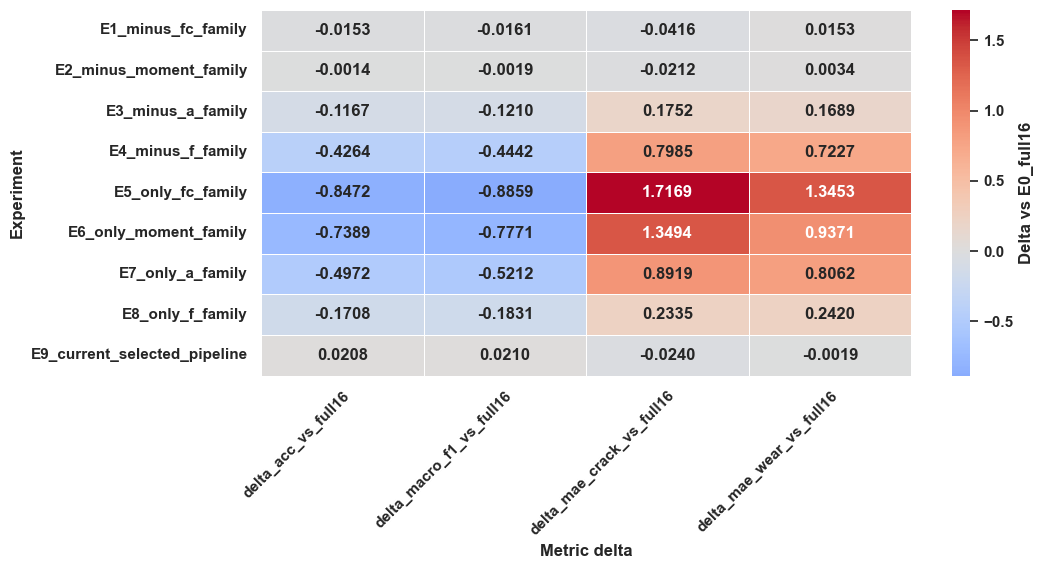

[Ablation] Heatmap exported to: ablation_outputs\ablation_delta_heatmap.png
[Ablation] Results exported to: ablation_outputs\ablation_results.csv
[Ablation] Hyperparameters exported to: ablation_outputs\best_hparams_ablation.json
[Ablation] Histories exported to: ablation_outputs\ablation_histories.json


In [38]:
# ============================================================
# Run ablation experiments, compare against E0_full16, and export results
# Updated heatmap: no title + diagonal x-axis labels
# ============================================================

ABLATION_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

best_hps_ablation = tune_ablation_baseline_full16()

ablation_core_results = []
ablation_histories = {}
full16_metrics_reference = None
last_ablation_model = None
last_ablation_history = None

for experiment_name, feature_subset in ABLATION_EXPERIMENTS_CORE:
    print(f"\n=== Running {experiment_name} | n_features={len(feature_subset)} ===")
    data_abl = build_ablation_dataset(feature_subset)

    model_abl, hist_abl = fit_ablation_model(
        X_tr_abl=data_abl["X_tr_abl"],
        y_cls_tr_abl=y_cls_tr_preselect,
        y_crack_tr_abl=y_crack_tr_preselect,
        y_wear_tr_abl=y_wear_tr_preselect,
        sw_crack_tr_abl=sw_crack_tr_preselect,
        sw_wear_tr_abl=sw_wear_tr_preselect,
        best_hps_ablation=best_hps_ablation,
    )

    result_abl = evaluate_ablation_model(
        model_abl=model_abl,
        X_te_abl=data_abl["X_te_abl"],
        feature_subset=feature_subset,
        experiment_name=experiment_name,
        reference_metrics_full16=full16_metrics_reference,
    )

    if experiment_name == "E0_full16":
        full16_metrics_reference = result_abl.copy()

    ablation_core_results.append(result_abl)
    ablation_histories[experiment_name] = hist_abl.history
    last_ablation_model = model_abl
    last_ablation_history = hist_abl

    print(
        f"[{experiment_name}] ACC={result_abl['test_accuracy']:.4f} | "
        f"Macro-F1={result_abl['test_macro_f1']:.4f} | "
        f"MAE_crack={result_abl['test_mae_crack']:.4f} | "
        f"MAE_wear={result_abl['test_mae_wear']:.4f}"
    )

reference_result_selected = evaluate_current_selected_pipeline_reference(full16_metrics_reference)
all_ablation_results = ablation_core_results + [reference_result_selected]

df_ablation_results = pd.DataFrame(all_ablation_results)

experiment_order = [name for name, _ in ABLATION_EXPERIMENTS_CORE] + ["E9_current_selected_pipeline"]

df_ablation_results["experiment"] = pd.Categorical(
    df_ablation_results["experiment"],
    categories=experiment_order,
    ordered=True
)

df_ablation_results = df_ablation_results.sort_values("experiment").reset_index(drop=True)

summary_cols = [
    "experiment",
    "experiment_role",
    "n_features",
    "test_accuracy",
    "test_macro_f1",
    "test_mae_crack",
    "test_mae_wear",
    "delta_acc_vs_full16",
    "delta_macro_f1_vs_full16",
    "delta_mae_crack_vs_full16",
    "delta_mae_wear_vs_full16",
]

print("\n=== Core ablation results ===")
display(df_ablation_results[df_ablation_results["experiment_role"] == "core"][summary_cols])

print("\n=== Reference model (current selected pipeline) ===")
display(df_ablation_results[df_ablation_results["experiment_role"] == "reference"][summary_cols])

# -------- Export tables and metadata --------
csv_path_ablation = ABLATION_OUTPUT_DIR / "ablation_results.csv"
df_ablation_results.to_csv(csv_path_ablation, index=False)

hparams_path_ablation = ABLATION_OUTPUT_DIR / "best_hparams_ablation.json"
with open(hparams_path_ablation, "w", encoding="utf-8") as f:
    json.dump(best_hps_ablation.values, f, ensure_ascii=False, indent=2)

histories_path_ablation = ABLATION_OUTPUT_DIR / "ablation_histories.json"
with open(histories_path_ablation, "w", encoding="utf-8") as f:
    json.dump(ablation_histories, f, ensure_ascii=False, indent=2)

# -------- Updated heatmap plotting --------
def plot_ablation_deltas_updated(df_ablation_results):
    delta_cols = [
        "delta_acc_vs_full16",
        "delta_macro_f1_vs_full16",
        "delta_mae_crack_vs_full16",
        "delta_mae_wear_vs_full16",
    ]

    df_plot = df_ablation_results[df_ablation_results["experiment"] != "E0_full16"].copy()

    if df_plot.empty:
        return None

    heatmap_data = df_plot.set_index("experiment")[delta_cols]

    fig, ax = plt.subplots(figsize=(11, max(4, 0.65 * len(heatmap_data))))

    sns.heatmap(
        heatmap_data,
        annot=True,
        fmt=".4f",
        cmap="coolwarm",
        center=0.0,
        linewidths=0.5,
        cbar_kws={"label": "Delta vs E0_full16"},
        ax=ax
    )

    # Remove title
    ax.set_title("")

    # Axis labels
    ax.set_xlabel("Metric delta", fontsize=12, fontweight="bold")
    ax.set_ylabel("Experiment", fontsize=12, fontweight="bold")

    # Rotate x-axis labels diagonally instead of vertical
    ax.set_xticklabels(
        ax.get_xticklabels(),
        rotation=45,
        ha="right",
        rotation_mode="anchor"
    )

    # Optional: bold tick labels
    for label in ax.get_xticklabels():
        label.set_fontweight("bold")
    for label in ax.get_yticklabels():
        label.set_fontweight("bold")

    plt.tight_layout()
    return fig

fig_ablation = plot_ablation_deltas_updated(df_ablation_results)

if fig_ablation is not None:
    heatmap_path_ablation = ABLATION_OUTPUT_DIR / "ablation_delta_heatmap.png"
    fig_ablation.savefig(heatmap_path_ablation, dpi=300, bbox_inches="tight")
    plt.show()
    print(f"[Ablation] Heatmap exported to: {heatmap_path_ablation}")
else:
    heatmap_path_ablation = None

print(f"[Ablation] Results exported to: {csv_path_ablation}")
print(f"[Ablation] Hyperparameters exported to: {hparams_path_ablation}")
print(f"[Ablation] Histories exported to: {histories_path_ablation}")